# **Yannick Poirier, POIY04109403, INF1022**



---



# **Liens utiles**

**Tout ce qui as été utilisée pour mon projet est disponible dans ce dossier sur mon google drive :**

https://drive.google.com/drive/folders/1u3MzqymS24Gvxoi-c-vXKoGG3qwPE3vO?usp=drive_link

**Les annotations Roboflow pour modèle principale V5 :**

https://app.roboflow.com/yan-jrjsi/projet-synthese/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

**Les annotations Roboflow pour modèle détection de sévérité :**

https://app.roboflow.com/yan-jrjsi/projet-synthese-sev/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true



---



# **Importation**

Cette section comporte tout simplement la connection a mon google drive ainsi que l'importation et l'installation de toute les librairies nécessaire au bon fonctionnement du programme.

In [1]:
# Connection au google drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Installation de certaines librairies/plug-ins

!pip install ultralytics
!pip install iterative-stratification -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:00


In [3]:
# Importation des librairies

import os
import pandas as pd
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
from ultralytics import YOLO
import shutil
from collections import Counter
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.patches as patches
from google.colab import files
from IPython.display import display, Markdown

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.




---



# **1. Constitution des bases de données d’images (10 points)**


J’ai décidé d’utiliser des images de véhicules accidentés et non accidentés provenant de Kaggle et Roboflow. Je connais très bien ces plateformes, puisque nous les avons utilisées à plusieurs reprises dans les cours de science des données, et je les considère particulièrement pratiques pour accéder à des jeux de données structurés.

Dans un premier temps, j’ai téléchargé les bases de données nécessaires afin d’obtenir des images de bonne qualité de véhicules accidentés et non accidentés. Dans un second temps, j’ai procédé à une sélection manuelle et rigoureuse de 300 images de véhicules non accidentés et de 500 images de véhicules accidentés. Deux dossiers distincts ont ensuite été créés afin de ne pas mélanger les véhicules accidentés et les véhicules non accidentés. Le nombre d’images de véhicules accidentés est plus élevé, puisque l’utilisation de seulement 300 images ne permettait pas d’obtenir un échantillon suffisant pour chacune des pièces endommagées.

Ma démarche exhaustive visait à assurer une diversité adéquate des données, conformément aux attentes du projet, notamment en ce qui concerne les types de véhicules (VUS, citadines et berlines), ainsi que la variété des zones endommagées et la gravité des dégâts. Mon expérience avec le temps m’a permis de comprendre que cette étape est cruciale pour obtenir un modèle performant et garantir un entraînement efficace. Je n’ai donc pas craint d’investir considérablement de temps sur cette étape.




## **Véhicules accidentés**

J'ai sélectionné les 500 images selon quatre critères principaux :

1.	La qualité de résolution des images ;

2.	Une diversité des types de dommages (léger, modéré, sévère) ;

3.	Une diversité des zones accidentées (avant, arrière, droite, gauche) ;

4.	Une diversité des types de véhicules (VUS, citadine, berline).

Chacune de ces sous-catégories contient exactement 100 images, comme le démontre le tableau récapitulatif, diversifiées quant à l’angle de prise de vue, au type de véhicule et aux diverses pièces endommagées. Finalement, j’ai un 200 images supplémentaires ("surplus") qui se concentre sur les pièces endommagées avec un faible niveau de représentation (par exemple les retroviseurs).

Bien que le processus de classification de la gravité des dégâts repose en partie sur ma subjectivité, je me suis appuyé sur une grille de critères objectifs afin d’assurer une cohérence et une uniformité dans le classement.

**Des détails plus précis sont fournis dans le rapport concernant l'obtention des images et le processus de qualification pour la catégorie de dommage, ainsi que des exemples pour chaque catégorie (section 3.1.1).**

## **Véhicules non accidentés**

J’ai procédé à une sélection de 300 images selon cinq critères principaux :

1.	La qualité de résolution des images ;

2.	Une répartition égale des trois types de véhicules (100 images par catégorie) ;

3.	Une diversité des marques et des modèles, puisqu’une même marque présente souvent des caractéristiques visuelles similaires d’un modèle à l’autre ;

4.	Une diversité des angles de prise de vue (360 degrés) ;

5.	Un continuum représentatif des années de production (1990 à 2025).


J’ai ainsi constitué mon jeu final d’images de véhicules non accidentés, structuré en trois sous-catégories selon le type de véhicule : berlines, citadines et VUS. Chaque catégorie contient 100 images présentant une variété de marques et de modèles, sous différents angles.

De plus, j’ai choisi d’inclure environ 60 % de véhicules couramment observés en Amérique du Nord et 40 % de véhicules internationaux (notamment européens et chinois). Cette stratégie m’a permis d’intégrer plus de 80 constructeurs automobiles différents dans ma base de données, augmentant ainsi la diversité visuelle du corpus.

Bien qu’il existe plusieurs autres catégories de véhicules, j’ai volontairement limité mon projet aux trois types sélectionnés afin de maintenir une cohérence méthodologique et de respecter le cadre du projet. Toutefois, la définition de ces catégories a été légèrement élargie afin d’assurer une diversité suffisante à l’intérieur de chacune d’elles.

**Le rapport fournis de plus ample détail sur le processus de sélection des images et ce qui constitue exactement chaque type de voiture avec des exemples (section 3.1.2)**.

# **Livrable** : Deux dossiers accidentes/ et non_accidentes/

* Les dossiers accidentes et non_accidentes sont accessible via mon google drive : https://drive.google.com/drive/folders/1szekEvAXgi_0VU1H15eU7npxUcllQBEH?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto


* Le contenu des dossiers démontrant la répartition des types de véhicules et de dommage est également afficher dans la deuxième section de ce présent document dans un tableau markdown.

* Finalement, la section 3.1 du rapport contient encore plus de détails et d'exemples sur la méthodologie employée pour collecter et répartir les images.



---



# **2. Diversité des types de véhicules (10 points)**


Comme mentionné précédemment dans la première section, j'ai collecté 300 images de voitures non accidentées, avec précisément 100 images pour chaque type (VUS, berline, citadine). J'ai également collecté 500 images de voitures accidentées, avec exactement 100 images pour chaque niveau de dommage (léger, modéré, sévère), ainsi que 200 images supplémentaires afin de prévenir la sous-représentation de certaines pièces endommagées moins courantes, comme les rétroviseurs. Pour les voitures accidentées comme pour les voitures non accidentées, j'ai veillé à inclure des angles variés, différentes marques et modèles, ainsi que des types d’images diversifiés (vues de loin, zooms, plusieurs voitures dans la même image, milieux urbains, milieux ruraux, etc.).

**Le rapport détaille déjà très bien la diversité des images utilisées (sections 3.1, 3.1.1 et 3.1.2).** Je vais donc ici me concentrer sur l’explication du code. Mon premier script parcourt une arborescence de dossiers contenant des images, organisée en deux niveaux : des catégories principales (accidentées, non_accidentées) et des sous-dossiers (types de véhicules ou gravité des dommages). Pour chaque sous-dossier, il compte le nombre de fichiers image en filtrant selon leur extension (.jpg, .png, .bmp, etc.). Les résultats sont affichés de manière hiérarchique dans la console, puis structurés dans un tableau pandas comportant trois colonnes : l’état, le type et le nombre d’images. Ce tableau est ensuite exporté au format .csv et affiché en Markdown afin d’offrir une visualisation claire.

# **Livrable** : Script tableau récapitulatif (format CSV ou Markdown)


**Tableau csv disponible sur mon google drive :**

https://drive.google.com/file/d/18hOEavhSsmVm6BBJArmk_MnVTFtBL_Tt/view?usp=drive_link

In [4]:
# Chemin vers mon dossier principal qui contient toutes les images
chemin_base = "/content/drive/MyDrive/INF1022_Yannick/Images"

# Extensions considérées comme des images (formats supportés)
ext_img = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Liste pour stocker les données qui alimenteront le tableau final
donnees = []

# Parcours de la hiérarchie de dossiers
# Niveau 1 : dossiers principaux (accidentes, non_accidentes)
for main_doc in os.listdir(chemin_base):
    chemin_main = os.path.join(chemin_base, main_doc)

    # On vérifie que c'est bien un dossier et non un fichier
    if os.path.isdir(chemin_main):
        print(f"\n {main_doc}")

        # Compteur du total d'images pour ce dossier principal
        total = 0

        # Niveau 2 : sous-dossiers (types de véhicules et niveau de dommage)
        for sub_doc in os.listdir(chemin_main):
            chemin_sub = os.path.join(chemin_main, sub_doc)
            if os.path.isdir(chemin_sub):

                # Filtrage : garde juste les fichiers avec une extension image valide
                imgs = [
                    f for f in os.listdir(chemin_sub)
                    if f.lower().endswith(ext_img)
                ]

                # Nombre d'images trouvées dans le sous-dossier
                nb = len(imgs)

                # Ajout au total du dossier parent
                total += nb

                # Ajout d'une ligne au tableau markdown : [état, type, nb_images]
                donnees.append([main_doc, sub_doc, nb])

                # Affichage arborescent dans la console
                print(f"   └── {sub_doc} : {nb} images")

        # Affichage du total par catégorie principale
        print(f"    Total {main_doc} : {total} images")


# Création du df panda à partir des données collectées
df = pd.DataFrame(donnees, columns=["Etat", "Type", "Nb_images"])

# Export du tableau en fichier CSV pour archivage et pour convertir en markdown
df.to_csv("/content/repartition_images.csv", index=False)
print("\n________________________________________")

# Affichage du tableau formaté en Markdown pour une meilleure lisibilité dans Colab
print("\nVersion tableau en Markdown :\n")
print(df.to_markdown(index=False))


 accidentes
   └── Léger : 100 images
   └── Modéré : 100 images
   └── Surplus : 200 images
   └── Sévère : 100 images
    Total accidentes : 500 images

 non_accidentes
   └── VUS : 100 images
   └── Citadinne : 100 images
   └── Berline : 100 images
    Total non_accidentes : 300 images

________________________________________

Version tableau en Markdown :

| Etat           | Type      |   Nb_images |
|:---------------|:----------|------------:|
| accidentes     | Léger     |         100 |
| accidentes     | Modéré    |         100 |
| accidentes     | Surplus   |         200 |
| accidentes     | Sévère    |         100 |
| non_accidentes | VUS       |         100 |
| non_accidentes | Citadinne |         100 |
| non_accidentes | Berline   |         100 |




---



# **3. Annotation des pièces (20 points)**


À ce stade du projet, je suis pleinement conscient que cette étape est cruciale pour la suite. Je devais donc réfléchir rigoureusement à la méthodologie à adopter, puisqu’elle constitue la fondation du projet. Si cette étape est mal conçue ou insuffisamment planifiée, des difficultés importantes pourraient survenir lors des phases ultérieures. De plus, il s’agit d’une tâche particulièrement exigeante en temps, car j’ai tout de même 800 images à annoter manuellement. Commettre des erreurs ou devoir recommencer l’annotation manuelle entraînerait une perte considérable d’efficacité et de temps. C’est pourquoi j’ai soigneusement sélectionné la plateforme Roboflow comme outil principal d’annotation, pour les raisons suivantes : L’exportation est facile en COCO, la plateforme propose des outils qui facilitent l’annotation, la gestion automatique train/val/test, la data augmentation est directement intégrée, la compatibilité facile avec les modèles YOLO et je possède déjà de l’expérience d’utilisation de cet outil. J’ai abordé cette étape en adoptant une vision globale du projet afin d’éviter tout blocage méthodologique dans les étapes finales. Les objectifs du projet qui sont conjointement liée à cette étape sont :

*	La détection des principales pièces d’un véhicule ;

*	La distinction entre pièces saines et pièces endommagées ;

*	La localisation ultérieure de la zone d’impact ;

*	L’estimation automatique du niveau global de sévérité.

En gardant ces objectifs en tête, j’ai sélectionné les types de pièces de manière stratégique afin de faciliter la détermination de la zone d’impact. J’ai donc créé plusieurs classes distinctes servant de repères structurels. Chaque classe combine le type de pièce, sa position (lorsque pertinente) et son état (sain ou endommagé). **La liste des pièces (17) est dans le rapport sous forme de tableau.** Afin d’assurer la cohérence du jeu de données, les règles suivantes ont été appliquées :

*	Chaque pièce visible est annotée, même si partiellement occultée ;

*	Une pièce est considérée endommagée dès qu’une déformation, fissure/cassure, rouille ou égratignure visible est observée ;

*	Les boîtes englobantes couvrent l’intégralité de la pièce, sans trop inclure d’éléments voisins dans la mesure du possible ;

*	Sur les véhicules accidentés, les pièces intactes sont annotées comme saines.





Initialement, j’envisageais d’utiliser un nombre presque double, même triple de classes afin de couvrir davantage de pièces et de positions spécifiques (par exemple « phare avant gauche », « phare avant droit », « phare arrière gauche » et « phare arrière droit », plutôt que simplement « phare »). Toutefois, après une analyse méthodologique, il est apparu qu’un trop grand nombre de classes, combiné à un jeu de données limité à mes 800 images (sans augmentation de données), aurait rendu l’apprentissage presque impossible pour le modèle. Cela aurait probablement entraîné un grand nombre de faux négatifs ainsi qu’un risque accru de surapprentissage (overfitting).

De plus, le projet spécifie un maximum de 1000 images (500 pour chaque catégorie). Ainsi, même en utilisant le nombre maximal d’images permis, cette approche n’aurait pas été viable. En ce sens, certaines pièces, comme les roues et les fenêtres, ont été exclues afin d’éviter une fragmentation excessive des classes et de préserver la stabilité de l’apprentissage. Le nombre total de classes retenu est de 17, donc 8 pour chaque catégorie (sain, endommagé) en plus de la classe « voiture », constitue selon moi un compromis entre précision descriptive et robustesse du modèle.

Cette structuration permet l’implémentation de règles logiques dans le code afin de déterminer la zone d’impact à 360 degrés. Par exemple, si le pare-chocs, le capot (donc à l’avant) et l’aile sont détectés comme endommagés alors que la portière droite est intacte, l’impact est fort probablement à l’avant droit. De plus, des règles de cohérence spatiale peuvent être intégrées. Par exemple, si un coffre est détecté, les phares et pare-chocs visibles sont nécessairement à l’arrière. Cette logique permet d’améliorer la cohérence des prédictions affichées et ainsi obtenir exactement la pièce, sa localisation et son état en limitant le plus possible les classes.

Enfin, l’estimation du niveau global de sévérité pourra être déterminée à partir :

*	Du nombre de pièces endommagées ;

*	De la surface totale estimée des zones endommagées ;

*	Du type de pièces affectées.




Afin que l’entraînement du modèle se déroule adéquatement et que celui-ci soit performant, il est généralement recommandé, pour un projet de cette envergure, d’avoir un minimum d’environ 100 instances par pièce. Dans mon cas, j’ai visé 150 instances afin d’obtenir les meilleures performances possibles compte tenu des contraintes du projet.

C’est pour cette raison que j’ai utilisé le nombre maximal d’images de véhicules accidentés permis dans ce projet (500). Avec seulement 300 images, environ la moitié des pièces endommagées étaient sous-représentées, avec moins de 50 instances chacune. Les 200 images supplémentaires ont donc été sélectionnées spécifiquement pour augmenter la représentation des pièces problématiques, afin qu’elles atteignent au minimum le seuil recommandé de 100 instances.

Je n’ai toutefois pas jugé nécessaire d’ajouter davantage d’images de véhicules non accidentés, car même sur un véhicule accidenté, plusieurs pièces demeurent intactes. Par conséquent, toutes les pièces saines étaient déjà largement représentées dans l’ensemble du jeu de données.

**Une capture d'écran présentant chaque pièce et son nombre d'instance est disponible dans le rapport (section 4.1.3).**

Pour chaque pièce, la catégorie saine possède généralement plus d’instances que la classe endommagée. Ce déséquilibre est logique, réaliste et attendu, puisque dans la majorité des images, la plupart des pièces sont intactes et seules certaines présentent des dommages.

Dans le contexte d’un modèle de détection, ce déséquilibre demeure acceptable puisque les classes minoritaires disposent tout de même d’un nombre suffisant d’exemples. Comme mentionné précédemment, toutes les classes possèdent plus de 100 instances, ce qui constitue généralement un seuil suffisant pour l’entraînement d’un modèle dans le cadre de mon projet. Toutefois, afin de réduire l’écart entre certaines classes, trois stratégies seront utilisées lors de l’entraînement du modèle :

1.   Augmentation asymétrique des données : augmentation x4 pour les classes ayant moins de 150 instances, x3 pour les classes entre 150 et 250 instances, x2 pour les classes entre 250 et 400 instances, et x1 pour les autres.
2.   Utilisation d’une fonction de perte pondérée (weighted loss) avec des poids de classe (class_weights).

3.   Division stratifiée du jeu de données afin d’assurer une représentation adéquate de chaque classe dans les ensembles d’entraînement, de validation et de test.




---



## 3.1 Importation des images et annotations dans l'environnement

Pour importer les annotations dans mon fichier ipynb, j’ai téléchargé les annotations directement depuis Roboflow au format YOLOv8 (choix justifié dans la section 5.1 du rapport ou section 4 de ce présent fichier). Cependant, pour plusieurs annotations, j’avais utilisé des polygones afin de gagner en précision et parfois même en temps, car sur les images de haute qualité l’outil Smart Polygon détectait souvent la pièce complète et permettait d’annoter celle-ci en un seul clic de manière très précise. Après avoir terminé l’annotation des 800 images, je me suis toutefois rendu compte que les annotations se téléchargeaient toujours sous forme de polygones. Les recherches que j’avais effectuées auparavant indiquaient pourtant que la conversion des polygones en boîtes englobantes (bounding boxes) devait normalement être automatique lors de l’exportation en format YOLO. Il est possible que l’erreur provienne de la configuration initiale du projet dans Roboflow, où j’aurais sélectionné par mégarde un format lié à la segmentation plutôt qu’à la détection. Ainsi, au lieu d’obtenir l’identifiant de classe suivi des coordonnées d’une boîte englobante, chaque annotation contenait un grand nombre de coordonnées correspondant aux différents points du polygone. Cette situation était problématique, car le modèle YOLO utilisé dans mon projet fonctionne uniquement avec des boîtes englobantes et s’attend à recevoir l’identifiant de classe suivi de quatre valeurs : le centre en x, le centre en y, la largeur et la hauteur. Les images et les annotations correspondaient donc correctement entre elles, mais le format des coordonnées était incompatible avec celui attendu par le modèle. Pour résoudre ce problème, j’ai décidé d’effectuer moi-même la conversion des polygones en boîtes englobantes à partir des coordonnées disponibles. Le script permettant de le faire est expliqué ci-bas.

### **Script importation images et labels**

Ce script commence par définir deux chemins : un dossier source contenant les fichiers d'annotations polygonales et un dossier de destination pour les bbox (bounding boxes). Il y a une boucle qui parcourt l’ensemble des fichiers d’annotations et convertit chaque annotation de polygone (format YOLO segmentation) en boîte englobante rectangulaire (format YOLO détection). Le principe consiste à calculer le rectangle minimal englobant contenant tous les points du polygone, puis à exprimer ce rectangle selon le format attendu par YOLO : centre_x, centre_y, largeur et hauteur, toutes des valeurs normalisées entre 0 et 1. Le script inclut également plusieurs vérifications afin d’ignorer les annotations invalides lorsque nécessaire (lignes vides, nombre impair de coordonnées ou boîtes dégénérées). Les annotations converties sont ensuite enregistrées dans un nouveau dossier en conservant la même structure de fichiers, tout en comptabilisant le nombre de fichiers traités et de lignes ignorées. Enfin, un exemple d’annotation convertie est affiché aléatoirement afin de permettre une vérification rapide du résultat. Cette démarche m’a permis de résoudre entièrement le problème : l’ensemble des annotations a été correctement converti et les 800 images disposent désormais de fichiers d’annotations compatibles et prêts à être utilisés pour l’entraînement du modèle.

In [5]:
# # Dossier source : fichiers .txt avec des polygones (format YOLO segmentation)
# labels_dir = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Brut/train/labels_poly"

# # Dossier destination : fichiers .txt avec des bboxes (format YOLO détection)
# output_dir = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Brut/train/labels"
# os.makedirs(output_dir, exist_ok=True)

# # Fonction de conversion : une ligne polygone vers une ligne bbox
# def polygon_txt_to_bbox(line):
#     """
#     Entrée : "classe x1 y1 x2 y2 ... xn yn" (coordonnées normalisées entre 0 et 1)
#     Sortie : "classe x_center y_center largeur hauteur" ou None si ligne invalide
#     """

#     line = line.strip() # Supprime les espaces/retours à la ligne en début et fin
#     if not line:
#         return None # Ignore les lignes vides

#     parts = line.split() # Découpe la ligne en tokens ["0", "0.12", "0.34", ...]

#     # Une annotation valide = 1 classe + au moins 2 points = 5 valeurs minimum
#     if len(parts) < 5:
#         print(f"Ligne ignorée (pas assez de coordonnées) : '{line}'")
#         return None

#     cls = parts[0] # Premier token = identifiant de classe ("0", "1", etc.)
#     coords = list(map(float, parts[1:])) # Reste = coordonnées converties en float

#     # Les coordonnées doivent être par paires (x, y) donc nombre pair obligatoire
#     if len(coords) % 2 != 0:
#         print(f"Ligne ignorée (nombre de coordonnées impair) : '{line}'")
#         return None

#     # Sépare les X (indices pairs) et les Y (indices impairs)
#     xs = coords[0::2] # [x1, x2, x3, ...] un élément sur deux en partant de 0
#     ys = coords[1::2] # [y1, y2, y3, ...] un élément sur deux en partant de 1

#     # Calcule le rectangle englobant minimal du polygone
#     # max(..., 0) et min(..., 1) clampent les valeurs dans [0, 1]
#     x_min = max(min(xs), 0)
#     x_max = min(max(xs), 1)
#     y_min = max(min(ys), 0)
#     y_max = min(max(ys), 1)

#     # Dimensions de la boîte englobante
#     w = x_max - x_min
#     h = y_max - y_min

#     # Rejette les bboxes dégénérées par sécurité (ligne ou point, surface nulle)
#     if w == 0 or h == 0:
#         print(f"Ligne ignorée (bbox dégénérée w={w}, h={h}) : '{line}'")
#         return None

#     # Calcule le centre de la bbox (format attendu par YOLO) pour x et y
#     x_center = (x_min + x_max) / 2
#     y_center = (y_min + y_max) / 2

#     # Retourne la ligne formatée avec 6 décimales de précision
#     return f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"

# # Boucle pour le traitement de tous les fichiers .txt
# examples = [] # Stocke quelques résultats pour test
# fichiers_traites = 0 # Compteur de fichiers convertis avec succès
# lignes_ignorees = 0 # Compteur de lignes invalides ignorées

# for filename in os.listdir(labels_dir): # Itère sur tous les fichiers du dossier source

#     if not filename.endswith(".txt"):
#         continue # Ignore les fichiers qui ne sont pas des annotations texte

#     input_path = os.path.join(labels_dir, filename) # Chemin fichier source
#     output_path = os.path.join(output_dir, filename) # Chemin fichier après conversion

#     # Lecture du fichier source (toutes les lignes d'un coup)
#     with open(input_path, "r") as f:
#         lines = f.readlines()

#     # Conversion ligne par ligne
#     new_lines = []
#     for line in lines:
#         result = polygon_txt_to_bbox(line)
#         if result is None:
#             lignes_ignorees += 1 # Comptabilise la ligne rejetée
#             continue
#         new_lines.append(result)
#         examples.append((filename, result)) # Mémorise pour le test à la fin

#     # Écriture du fichier de sortie (toutes les lignes converties en un seul bloc)
#     with open(output_path, "w") as f:
#         f.write("\n".join(new_lines) + "\n") # Chaque bbox sur sa propre ligne

#     fichiers_traites += 1

# # Résumé et vérification
# print(f"Conversion terminée : {fichiers_traites} fichier(s) traité(s), {lignes_ignorees} ligne(s) ignorée(s)")

# # Affiche un exemple converti choisi au hasard pour vérification visuelle rapide
# if examples:
#     img_example, line_example = random.choice(examples)
#     print("\nExemple aléatoire :")
#     print(f"Image : {img_example}")
#     print(f"Annotation : {line_example}")
# else:
#     print("Aucune annotation valide trouvée")



---



### **Script vérification images et annotations**

Ce deuxième script me permet de vérifier visuellement les annotations du jeu de données en affichant une image accompagnée de ses boîtes englobantes et de leurs étiquettes de classe. Il commence par définir les chemins vers les images, les fichiers d’annotations et le fichier data.yaml contenant les noms des classes. Une image du dossier est ensuite sélectionnée et le script vérifie que le fichier d’annotation correspondant existe. L’image est chargée avec OpenCV, puis les annotations YOLO (classe, centre x, centre y, largeur, hauteur, toutes normalisées entre 0 et 1) sont converties en coordonnées de pixels afin de calculer les coins de la boîte englobante. Pour chaque annotation, une couleur spécifique est générée selon la classe et une boîte est dessinée autour de l’objet, accompagnée du nom de la classe affiché au-dessus. Enfin, l’image annotée est affichée avec Matplotlib, ce qui permet de confirmer visuellement que les annotations sont correctement positionnées et correspondent aux objets présents dans l’image.

In [6]:
# # Chemins pour récupérer les images, annotations et yaml dans mon drive
# chemin_base = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Brut/" # dossier racine
# chemin_images = os.path.join(chemin_base, "train/images")
# chemin_labels = os.path.join(chemin_base, "train/labels")
# chemin_yaml = os.path.join(chemin_base, "data.yaml")
# # ====================================================

# # Chargement du fichier YAML (classes)
# with open(chemin_yaml, "r") as f:
#     config = yaml.safe_load(f)
# classes = config["names"]

# # Sélection d'une image
# images = [f for f in os.listdir(chemin_images) if f.endswith((".jpg", ".png", ".jpeg"))]
# img_nom = images[66] # Index de l'image qu'on veut voir (entre 0 et 799)

# # Construction des chemins complets vers l'image et son fichier d'annotation
# img_path = os.path.join(chemin_images, img_nom)
# label_path = os.path.join(chemin_labels, img_nom.rsplit(".", 1)[0] + ".txt")
# # rsplit(".", 1)[0] : retire l'extension du nom de fichier pour trouver le .txt correspondant

# print(f"\nImage sélectionnée : {img_nom}")

# # Vérifie que le fichier d'annotation existe avant de continuer
# if not os.path.exists(label_path):
#     print("Annotations introuvables")

# # Fonction pour avoir une couleur unique par classe
# def couleur_par_classe(class_id, nb_classes):
#     """
#     Génère une couleur RGB reproductible et distincte pour chaque classe.
#     La graine (seed) est fixée à partir de l'id de classe pour que
#     la même classe ait toujours la même couleur d'un appel à l'autre.
#     """
#     np.random.seed(class_id * 7) # Graine fixe et unique par classe
#     return tuple(int(x) for x in np.random.randint(50, 255, 3)) # Couleur RGB aléatoire mais reproductible

# # Chargement et préparation de l'image
# img = cv2.imread(img_path) # Charge l'image en BGR (format OpenCV par défaut, doit le convertir)
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convertit format BGR vers RGB pour un affichage correct avec matplotlib
# h, w = img.shape[:2] # Récupère les dimensions réelles de l'image (hauteur, largeur)

# # Lecture et placement des annotations
# with open(label_path, "r") as f:
#     lignes = f.readlines() # Charge toutes les lignes d'annotation du fichier

# for ligne in lignes:
#     valeurs = ligne.strip().split() # Découpe la ligne en tokens pour YOLO : [classe, x_c, y_c, w, h]
#     class_id = int(valeurs[0]) # Identifiant numérique de la classe
#     x_centre, y_centre = float(valeurs[1]) * w, float(valeurs[2]) * h # Dénormalise le centre en pixels
#     largeur, hauteur = float(valeurs[3]) * w, float(valeurs[4]) * h # Dénormalise les dimensions en pixels

#     # Calcule les coordonnées des coins du rectangle à partir du centre et des dimensions
#     x1 = int(x_centre - largeur / 2) # Coin supérieur gauche : x1
#     y1 = int(y_centre - hauteur / 2) # Coin supérieur gauche : y1
#     x2 = int(x_centre + largeur / 2) # Coin inférieur droit : x2
#     y2 = int(y_centre + hauteur / 2) # Coin inférieur droit : y2

#     couleur = couleur_par_classe(class_id, len(classes)) # Couleur propre à cette classe
#     label = classes[class_id] # Nom textuel de la classe (pare-chocs, phares, etc.)

#     # Dessine le rectangle de la boîte englobante (épaisseur 2px)
#     cv2.rectangle(img, (x1, y1), (x2, y2), couleur, 2)

#     # Mesure la taille du texte pour dimensionner le fond coloré derrière l'étiquette
#     (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)

#     # Dessine un rectangle plein (-1) comme fond coloré pour améliorer la lisibilité du texte
#     cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw + 4, y1), couleur, -1)

#     # Écrit le nom de la classe en blanc par-dessus le fond coloré
#     cv2.putText(img, label, (x1 + 2, y1 - 4),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

# # Affichage final avec matplotlib
# plt.figure(figsize=(18, 12)) # Taille d'affichage généreuse pour voir les détails
# plt.imshow(img) # Affiche l'image annotée
# plt.title(f"{img_nom} — {len(lignes)} annotations", fontsize=14) # Titre avec nom du fichier et nombre d'objets détectés
# plt.axis("off") # Cache les axes (inutiles pour une image)
# plt.tight_layout() # Optimise les marges
# plt.show()



---



# **Livrable :** Fichiers d’annotation au format COCO ou Pascal VOC

* Les 800 images utilisées et sans annotation sont disponible sur mon google drive : https://drive.google.com/drive/folders/1szekEvAXgi_0VU1H15eU7npxUcllQBEH?usp=drive_link

* Les mêmes 800 images utilisées et annotés manuellement sont publiquement accessible sur mon projet Roboflow : https://app.roboflow.com/yan-jrjsi/projet-synthese/browse?queryText=+sort%3Afilename&pageSize=50&startingIndex=0&browseQuery=true

* Les fichiers d'annotations bruts format COCO sont disponible sur mon google drive : https://drive.google.com/file/d/1i-fhJqbjlA4OraXVfYKrMHfZCmzP5s5I/view?usp=drive_link


**Note :** Puisque j'ai choisi d'utiliser YOLO comme architecture, les annotations ont d'abord été produites et sauvegardées au format COCO JSON via Roboflow, tel que requis. Ce format a ensuite été converti au format YOLO lors de l'exportation, car YOLOv11 requiert un fichier .txt par image ainsi qu'un fichier data.yaml décrivant les classes. Cette conversion ne modifie pas le contenu des annotations, mais adapte uniquement leur représentation pour être compatibles avec le pipeline d'entraînement de YOLO.

* Les fichiers d'annotations YOLO bruts sont disponible sur mon google drive : https://drive.google.com/drive/folders/1DdliOJf9RsaAJ3-GUv1vNbASCzmOAxVT?usp=drive_link

* Les fichiers d'annotations YOLO train/test/val utilisées pour l'entraînement sont disponible sur mon google drive : https://drive.google.com/drive/folders/1O2vNKnOaMSvDxwp1VQyGxOonzBA3OxxQ?usp=drive_link



---



# **4. Entraînement du modèle de détection de pièces endommagées (10 points)**

J’ai opté pour l’architecture YOLOv11 afin d’entraîner mon modèle. J’ai longuement considéré et exploré les différentes options qui s’offraient à moi, mais, somme toute, celle-ci semble la mieux adaptée à mes besoins. Dans la même famille de modèles YOLO, j’ai notamment évalué YOLOv8, YOLOv10 et YOLOv12. Je me suis également intéressé à Faster R-CNN et SSD.

Bien que YOLOv8 ait constitué une avancée majeure avec l’introduction d’une tête de détection découplée (anchor-free), YOLOv11 représente l’évolution directe de cette architecture avec plusieurs améliorations architecturales notables. Il améliore les capacités introduites par YOLOv8 tout en optimisant l’efficacité globale du modèle. En pratique, YOLOv11 atteint un meilleur score de précision moyenne (mAP) tout en utilisant moins de paramètres, démontrant une plus grande efficacité sans compromettre la précision. Sur le plan architectural, YOLOv11 met particulièrement l’accent sur l’efficacité et la détection de petits objets grâce à des blocs compacts et à l’intégration de modules d’attention permettant une agrégation de caractéristiques plus robuste.

De son côté, YOLOv10 introduit une architecture sans NMS (Non-Maximum Suppression) afin de réduire la latence. Cependant, avec sa conception plus complexe et son processus d’entraînement en deux étapes, YOLOv10 peut augmenter le temps d’inférence ainsi que les besoins en ressources matérielles. Cette caractéristique est moins adaptée à mon contexte de développement, puisque je travaille dans un environnement limité en ressource exploitable et qu’il ne semble pas y avoir de points largement plus positif que YOLOv11.

À l’origine, j’envisageais également d’utiliser YOLOv12, qui introduit une architecture centrée sur l’attention (attention-centric) avec des modules Area Attention et des blocs R-ELAN. Bien que cette approche soit prometteuse sur le plan théorique, elle présente certaines limitations pratiques importantes. La bibliothèque Ultralytics YOLO ne recommande pas actuellement YOLOv12 pour un usage en production, notamment en raison de couches d’attention susceptibles de provoquer une instabilité à l’entraînement, une consommation mémoire plus élevée et des vitesses d’inférence CPU significativement plus lentes. Ces limitations sont particulièrement problématiques dans le cadre de mon projet. Dans ce contexte, la stabilité de l’entraînement constitue une priorité, et YOLOv11 offre cette fiabilité là où YOLOv12 demeure plus en phase encore expérimental.

Comparativement à des architectures de détection en deux étapes comme Faster R-CNN, YOLOv11 présente également plusieurs avantages. Faster R-CNN est reconnu pour sa grande précision, notamment grâce à son mécanisme de génération de propositions de régions (Region Proposal Network) suivi d’une étape de classification. Toutefois, cette approche en deux étapes entraîne généralement un temps d’inférence plus élevé et une complexité computationnelle plus importante. Dans un contexte de ressources limitées et de besoin d’entraînement relativement rapide, YOLOv11 offre un meilleur compromis entre précision et vitesse d’exécution, ce qui le rend plus adapté à mon projet.

Enfin, en comparaison avec Single Shot MultiBox Detector (SSD), YOLOv11 bénéficie d’architectures plus récentes et d’optimisations modernes issues de la famille YOLO. Les modèles SSD sont réputés pour leur rapidité puisqu’ils effectuent la détection en une seule passe sur l’image. Toutefois, ils montrent généralement des performances inférieures pour la détection de petits objets et peuvent présenter une précision plus faible sur des ensembles de données complexes. YOLOv11, grâce à ses améliorations architecturales et à ses mécanismes d’agrégation de caractéristiques, parvient à maintenir une vitesse d’inférence élevée tout en offrant une précision supérieure, ce qui en fait un choix plus équilibré pour mon projet de détection de pièces automobiles saines et endommagées.


## **4.1 Partitionnement**

Afin de diviser le jeu de données tout en tenant compte de la distribution inégale de certaines classes, un partitionnement stratifié multi-label a été utilisé pour séparer les données en ensembles d’entraînement (train), de validation (val) et de test selon un ratio de 60/20/20 comme spécifié dans l’énoncé de projet. Cette approche permet de préserver la proportion des différentes classes dans chaque sous-ensemble. Contrairement à une stratification classique, qui suppose qu’une image possède une seule étiquette (ou une étiquette dominante), la détection d’objets implique qu’une image peut contenir plusieurs instances appartenant à différentes classes.

Pour tenir compte de cette réalité, chaque image est représentée par un vecteur de dimension 17, correspondant au nombre total de classes dans le jeu de données. Chaque composante du vecteur indique le nombre d’instances de la classe correspondante présentes dans l’image. Par exemple, une image contenant deux phares sains et un pare-chocs endommagé sera représentée par un vecteur où les positions associées à ces classes contiendront respectivement les valeurs 2 et 1, tandis que les autres positions seront nulles.

L’ensemble des vecteurs obtenus pour les 800 images forme ainsi une matrice de dimension (800 × 17). Cette représentation permet à l’algorithme de partitionnement de répartir les images de manière à conserver, autant que possible, la distribution des instances de chaque classe dans les ensembles d’entraînement, de validation et de test. Ainsi, chaque sous-ensemble contient une proportion similaire d’annotations pour chacune des classes, ce qui contribue à produire un modèle plus robuste et mieux généralisable lors de l’entraînement.

Cette approche permet d’éviter qu’une classe soit fortement sous-représentée dans l’un des sous-ensembles. Par exemple, sans stratification multi-label, il serait possible qu’une classe comme coffre_endommage ne soit représentée que par une seule instance dans l’ensemble de validation. Une telle situation nuirait à l’évaluation du modèle, puisque celui-ci disposerait de trop peu d’exemples pour mesurer correctement sa capacité à détecter cette classe.


### **Script partitionnement multi-label**

Ce script a pour objectif de préparer le jeu de données annoté pour l’entraînement d’un modèle YOLO en réalisant plusieurs étapes clés.
D'abord la définition des ratios pour la validation et le test (20% chacun) et d’une graine aléatoire pour assurer la reproductibilité. S'ensuit la lecture du fichier YAML pour récupérer les noms de classes et le nombre total de classes.  Le script procède alors à la création d’un vecteur d’instances par image qui pour chaque image valide, construit un vecteur de longueur égale au nombre de classes. Chaque élément du vecteur correspond au nombre d’instances d’une classe dans l’image. Cela permet de conserver la distribution exacte des instances par classe pour le partitionnement. Il y a ensuite vérification de la distribution des instances et calcul du total d’instances par classe sur l’ensemble du dataset. L'étape de partitionnement stratifié multi-label (train/val/test) peut alors commencer. J'utilise MultilabelStratifiedShuffleSplit pour garantir que chaque sous-ensemble conserve la proportion d’instances par classe, même si plusieurs classes sont présentes dans la même image.

Le split se fait en deux étapes : Train vs reste (val + test), puis validation vs test sur le reste. Ce mécanisme évite d’avoir des classes très peu représentées dans un sous-ensemble (par exemple coffre_endommage). Ensuite, la vérification de la répartition finale : Impression du nombre d’images et du nombre d’instances par classe dans chaque sous-ensemble (train, val, test), ainsi que l'affichage des pourcentages pour confirmer que la stratification est respectée.

Finalement, c'est la copie des fichiers dans les sous-dossiers appropriés. Les images et leurs annotations sont copiées dans train/, val/ et test/ avec la structure attendue par YOLO. Aussi, génération d’un fichier data.yaml adapté pour l’entraînement YOLO, contenant les chemins vers chaque sous-ensemble et les noms des classes.

In [7]:
# # ==============================================================
# # CONFIGURATION
# # ==============================================================

# chemin_base = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Brut/" # Chemin racine où se trouvent les images brutes et les labels
# chemin_images = os.path.join(chemin_base, "train/images") # Sous-dossier contenant les images
# chemin_labels = os.path.join(chemin_base, "train/labels") # Sous-dossier contenant les annotations au format YOLO (.txt)
# chemin_yaml = os.path.join(chemin_base, "data.yaml") # Chemin vers le fichier YAML décrivant les classes et le dataset
# chemin_sortie = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Donnees_preparees/" # Dossier de sortie où seront créés les sous-ensembles train/val/test

# # Ratios de validation et test pour le split
# RATIO_VAL = 0.20  # 20% des images pour validation
# RATIO_TEST = 0.20  # 20% des images pour test
# SEED = 42 # Seed pour reproductibilité des splits aléatoires

# # Nettoyage du dossier de sortie si déjà existant pour éviter doublons
# if os.path.exists(chemin_sortie):
#     shutil.rmtree(chemin_sortie)

# # ==============================================================
# # CHARGEMENT DES CLASSES
# # ==============================================================

# # Lecture du fichier YAML pour récupérer les noms de classes
# with open(chemin_yaml, "r") as f:
#     config = yaml.safe_load(f)
# classes = config["names"] # Liste des noms de classes
# nb_classes = len(classes) # Nombre total de classes
# print(f"Classes ({nb_classes}) : {classes}\n")

# # ==============================================================
# # INVENTAIRE : vecteur d'instances par classe pour chaque image
# # ==============================================================

# images_valides = [] # Liste des images possédant au moins une annotation
# vecteurs = [] # Vecteur du nombre d'instances par classe pour chaque image

# # Parcours de toutes les images du dataset
# for nom_fichier in sorted(os.listdir(chemin_images)):

#     # Ignorer les fichiers non images
#     if not nom_fichier.lower().endswith((".jpg", ".jpeg", ".png")):
#         continue

#     # Nom de base de l'image pour retrouver le fichier label correspondant
#     nom_base = nom_fichier.rsplit(".", 1)[0]
#     label_path = os.path.join(chemin_labels, nom_base + ".txt")

#     # Ignorer si le fichier label n'existe pas
#     if not os.path.exists(label_path):
#         continue

#     # Lecture des annotations
#     with open(label_path, "r") as f:
#         lignes = f.readlines()

#     # Initialisation du vecteur d'instances pour cette image
#     vecteur = np.zeros(nb_classes, dtype=int)

#     # Compte des instances par classe
#     for ligne in lignes:
#         valeurs = ligne.strip().split()
#         if len(valeurs) >= 5:
#             vecteur[int(valeurs[0])] += 1

#     # Ignorer les images sans annotation valide
#     if vecteur.sum() == 0:
#         continue

#     # Ajouter l'image valide et son vecteur d'instances
#     images_valides.append(nom_fichier)
#     vecteurs.append(vecteur)

# # Conversion des listes en arrays pour manipulation ultérieure
# images_arr = np.array(images_valides)
# vecteurs_arr = np.array(vecteurs) # (nb_images, nb_classes)

# # ==============================================================
# # AFFICHAGE DU TOTAL D'INSTANCES PAR CLASSE
# # ==============================================================

# totaux = vecteurs_arr.sum(axis=0) # Somme des instances par classe sur toutes les images
# print(f"{'Classe':<28} {'Total instances':>16}")
# print("-" * 46)
# for i, (nom, total) in enumerate(zip(classes, totaux)):
#     print(f"  [{i:>2}] {nom:<24} {total:>16}")
# print(f"\nTotal toutes classes : {totaux.sum()}")
# print(f"Images valides : {len(images_valides)}\n")

# # ==============================================================
# # SPLIT MULTI-LABEL : TRAIN / RESTE  puis VAL / TEST
# # ==============================================================

# # MultilabelStratifiedShuffleSplit : stratification basée sur le nombre
# # d'instances par classe afin de conserver la distribution des classes dans chaque subset

# # --- Split 1 : train vs reste (val+test) ---
# msss1 = MultilabelStratifiedShuffleSplit(
#     n_splits=1, # On ne fait qu’un seul split
#     test_size=(RATIO_VAL + RATIO_TEST), # Reste = val + test
#     random_state=SEED # Seed pour reproductibilité
# )

# # Génération des indices pour train et reste
# idx_train, idx_reste = next(msss1.split(images_arr, vecteurs_arr))

# # Extraction des images et vecteurs correspondant
# X_train = images_arr[idx_train]
# X_reste = images_arr[idx_reste]
# v_train = vecteurs_arr[idx_train]
# v_reste = vecteurs_arr[idx_reste]

# # --- Split 2 : val vs test (donc sur le reste) ---
# msss2 = MultilabelStratifiedShuffleSplit(
#     n_splits=1,
#     test_size=RATIO_TEST / (RATIO_VAL + RATIO_TEST), # Proportion test sur le reste
#     random_state=SEED
# )

# # Génération des indices pour val et test
# idx_val, idx_test = next(msss2.split(X_reste, v_reste))

# # Extraction des images et vecteurs correspondant
# X_val = X_reste[idx_val]
# X_test = X_reste[idx_test]
# v_val = v_reste[idx_val]
# v_test = v_reste[idx_test]

# # ==============================================================
# # VÉRIFICATION DE LA DISTRIBUTION DES INSTANCES
# # ==============================================================

# # Calcul et affichage de la répartition des images
# total_imgs = len(images_valides)
# print(f"Répartition des images après la stratification :")
# print(f"Train : {len(X_train)}({len(X_train)/total_imgs*100:.1f}%)")
# print(f"Val : {len(X_val)}({len(X_val)/total_imgs*100:.1f}%)")
# print(f"Test : {len(X_test)}({len(X_test)/total_imgs*100:.1f}%)")

# # Affichage du détail par classe (total et répartition)
# print(f"\n{'Classe':<28} {'Total':>8} {'Train':>8} {'Val':>8} {'Test':>8} {'Tr%':>6} {'Va%':>6} {'Te%':>6}")
# print("-" * 82)

# tot_tr = v_train.sum(axis=0) # Somme par classe dans train
# tot_va = v_val.sum(axis=0) # Somme par classe dans val
# tot_te = v_test.sum(axis=0) # Somme par classe dans test

# # Boucle qui construit un tableau contenant toute les infos pertinente
# for i, nom in enumerate(classes):
#     total = totaux[i]
#     if total == 0:
#         continue
#     tr, va, te = tot_tr[i], tot_va[i], tot_te[i]
#     print(f"[{i:>2}] {nom:<24} "
#           f"{total:>8} {tr:>8} {va:>8} {te:>8} "
#           f"{tr/total*100:>5.1f}% {va/total*100:>5.1f}% {te/total*100:>5.1f}%")

# # ==============================================================
# # COPIE DES FICHIERS DANS LES SOUS-DOSSIERS
# # ==============================================================

# def copier_subset(liste_images, nom_subset):
#     """
#     Copie les images et leurs labels dans un sous-dossier spécifique (train/val/test)
#     Crée les dossiers s'ils n'existent pas
#     """
#     dossier_img = os.path.join(chemin_sortie, nom_subset, "images")
#     dossier_lbl = os.path.join(chemin_sortie, nom_subset, "labels")
#     os.makedirs(dossier_img, exist_ok=True)
#     os.makedirs(dossier_lbl, exist_ok=True)

#     # Copie chaque image et son label correspondant
#     for nom_img in liste_images:
#         nom_base = nom_img.rsplit(".", 1)[0]
#         shutil.copy2(os.path.join(chemin_images, nom_img),
#                      os.path.join(dossier_img, nom_img))
#         shutil.copy2(os.path.join(chemin_labels, nom_base + ".txt"),
#                      os.path.join(dossier_lbl, nom_base + ".txt"))
#     print(f"{nom_subset:<6} : {len(liste_images)} paires copiées")

# # Exécution de la copie pour chaque subset
# print(f"\nCopie vers : {chemin_sortie}")
# copier_subset(X_train, "train")
# copier_subset(X_val, "val")
# copier_subset(X_test, "test")

# # ==============================================================
# # EXPORT DU data.yaml
# # ==============================================================

# # Création du nouveau fichier YAML pour YOLO avec les chemins vers les images
# nouveau_yaml = {
#     "path" : chemin_sortie,
#     "train" : "train/images",
#     "val" : "val/images",
#     "test" : "test/images",
#     "nc" : nb_classes,
#     "names" : classes
# }

# # Écriture du nouveau YAML dans le dossier de sortie
# with open(os.path.join(chemin_sortie, "data.yaml"), "w") as f:
#     yaml.dump(nouveau_yaml, f, default_flow_style=False, allow_unicode=True)

# print(f"\ndata.yaml exporté. Partition stratifié multi-label par instances terminé avec succès.")

Le partitionnement a permis de diviser les données selon un ratio cible d’environ 60 % pour l’entraînement, 20 % pour la validation et 20 % pour le test, ce qui correspond respectivement à 486 images pour l’ensemble d’entraînement, 159 images pour la validation et 155 images pour le test. Les pourcentages obtenus (60,8 %, 19,9 % et 19,4 %) sont très proches du ratio souhaité, ce qui indique que la séparation des images s’est effectuée de manière équilibrée. Lors de ce type de manœuvre, on tolère généralement une marge d’environ 2-3% de variation par rapport à la cible. Mon script performe donc de façon très optimale dans ce contexte.

L’analyse de la distribution des instances par classe montre que la stratification a également réussi à préserver la proportion des annotations dans chacun des sous-ensembles. Par exemple, la classe aile_endommage comporte 332 instances au total, dont 202 dans l’ensemble d’entraînement (60,8 %), 61 dans la validation (18,4 %) et 69 dans le test (20,8 %). Une répartition similaire est observée pour toute les classes, dont les proportions demeurent proches du ratio cible de 60/20/20.

Ces résultats démontrent que ma méthode de stratification multi-label a permis de conserver une distribution cohérente des instances de chaque classe entre les ensembles d’entraînement, de validation et de test. Cette propriété est particulièrement importante dans le contexte de la détection d’objets, puisque chaque image peut contenir plusieurs objets appartenant à différentes classes. En maintenant des proportions similaires d’annotations dans chaque sous-ensemble, je réduis le risque qu’une classe soit sous-représentée lors de l’entraînement ou de l’évaluation du modèle, ce qui contribue à améliorer la stabilité et la capacité de généralisation du modèle d’apprentissage.




---



## **4.2 Entraînement de modèle**

J’ai beaucoup expérimenté avec l’augmentation des données. Il existe tellement de possibilités et de combinaisons possible qu’il est difficile réalistiquement de tester toutes les possibilités. Cependant, en effectuant les recherches appropriées il est plus simple de cibler ce qui est pertinent et qui va avoir un impact selon mon type de jeux de données.

Les augmentations de données sont appliquées en temps réel pendant l’entraînement, à chaque epoch, de manière aléatoire et différente pour chaque image. Aucune image augmentée n’est enregistrée sur le disque; chaque epoch expose donc le modèle à une version légèrement différente du même jeu de données, ce qui augmente effectivement la diversité perçue sans accroître l’espace de stockage requis.

Dans le cadre de YOLOv11s, les augmentations de données jouent également un rôle de régularisation implicite, en empêchant le modèle de simplement mémoriser les images d’entraînement et en favorisant ainsi une meilleure capacité de généralisation. Les augmentations retenues visent principalement à introduire de la variabilité réaliste dans les données tout en conservant la cohérence visuelle des objets détectés. Les transformations sélectionnées permettent d’augmenter la diversité des exemples observés durant l’entraînement, ce qui contribue à améliorer la capacité de généralisation du modèle tout en évitant l’introduction de biais ou d’annotations incohérentes.

En plus des augmentations de données, plusieurs hyperparamètres d’entraînement ont été ajustés afin d’optimiser l’apprentissage de mon modèle. Ces paramètres influencent directement la manière dont le réseau ajuste ses poids pendant l’entraînement et ont un impact important sur la stabilité et la précision finale du modèle.

Dans l’ensemble, ces hyperparamètres ont été sélectionnés afin de favoriser la précision de localisation et la capacité de discrimination entre classes similaires, deux aspects particulièrement importants pour mon projet. Les ajustements apportés aux poids des fonctions de perte permettent d’orienter l’apprentissage vers une meilleure qualité des boîtes englobantes et une classification plus fiable des différentes pièces automobiles et de leur état.

Chaque augmentations et chaque paramètres sont détaillés et discutés au niveau de leurs pertinences dans le rapport contenus aux sections 5.1.3 et 5.1.4.




---



**Évolution des modèles**

À force de peaufiner mes modèles, j’ai finalement obtenu un modèle qui me convient à la cinquième version. Avant de l’aborder, voici un résumé de chacune des versions précédentes qui ont mené à cette version finale. Après chaque entraînement, les métriques étaient analysées afin de cibler le plus précisément possible les lacunes de chaque modèle et d’orienter les décisions d’optimisation suivantes.

La première version constituait un modèle de référence. L’objectif n’était pas la performance maximale, mais de valider que le pipeline complet fonctionnait (annotations, partitionnement stratifié, entraînement, inférence) et d’obtenir des métriques de référence contre lesquelles comparer les versions futures. Le modèle utilisé était YOLO11s, entraîné sur 100 epochs à une résolution de 640 pixels avec l’optimiseur automatique. Les résultats globaux étaient étonnamment solides pour un premier essai, avec un mAP50 de 0,718 et un mAP50-95 de 0,529. Le modèle distinguait correctement la majorité des pièces et identifiait bien les dommages. Toutefois, une erreur non négligeable rendait ce modèle inutilisable dans le cadre de mon projet : l’augmentation fliplr était activée à 0,5. Cette augmentation agit comme un miroir horizontal sur les images d’entraînement, ce qui a complètement détruit la notion de porte gauche versus porte droite. Le modèle prédisait aléatoirement l’une ou l’autre avec un niveau de confiance supérieur à 90 % dans la majorité des cas, rendant la localisation latérale des dommages totalement non fiable. Ce problème a été confirmé par la matrice de confusion, qui révélait des taux de confusion de l’ordre de 30 à 40 % entre les classes de portes opposées.

La deuxième version avait pour objectif de corriger le problème structurel de confusion des portes gauche/droite identifié en V1 et d’explorer le gain apporté par un modèle plus grand sur le même jeu de données. Le passage à l’architecture YOLO11m a fait passer le nombre de paramètres de 9,4 à 20 millions. La résolution a été augmentée à 832 pixels pour améliorer la détection des dommages fins, et le nombre d’epochs a été porté à 200 pour accommoder la convergence plus lente inhérente à un modèle de taille moyenne. L’augmentation fliplr a été explicitement désactivée (fliplr = 0.0), ce qui a produit une amélioration spectaculaire et mesurable sur les classes de portes : le mAP50 de porte_droite_sain est passé de 0,466 à 0,872 (+87 %) et celui de porte_droite_endommagee de 0,393 à 0,671 (+71 %). Sur le plan des métriques globales, V2 a obtenu le meilleur mAP50 de toutes les versions avec 0,762 et le meilleur mAP50-95 avec 0,566. Cependant, malgré ces chiffres supérieurs, le modèle présentait davantage d’erreurs pratiques que V1 lors des tests d’inférence sur des images réelles : détections manquantes sur des pièces endommagées, faux positifs et détections dupliquées sur une même zone. Ces comportements s’expliquent par le fait que le modèle medium, avec ses 20 millions de paramètres, était vraisemblablement surdimensionné pour un jeu de données de seulement 486 images d’entraînement.

La troisième version est revenue à l’architecture YOLO11s, car le modèle medium était probablement trop grand pour le volume de données disponible. L’objectif était de vérifier si les gains de performance de V2 étaient attribuables au modèle plus grand ou aux autres optimisations apportées simultanément. V2 avait en effet modifié plusieurs variables en parallèle, notamment la taille du modèle, le nombre de batch, résolution, fliplr et optimiseur AdamW. V3 cherchait à isoler la question : peut-on obtenir des résultats comparables avec le modèle léger en conservant imgsz = 832, batch = 32 et fliplr = 0.0, mais en substituant AdamW par SGD? Malheureusement, les métriques laissaient entrevoir un modèle prometteur, mais les tests de détection sur des images réelles étaient peu satisfaisants : le modèle manquait de précision dans ses détections et produisait des résultats moins fiables que les versions précédentes.

La quatrième version a été explicitement optimisée pour la précision plutôt que pour le mAP global, en réponse à un objectif applicatif clair : dans le cadre de la détection de dommages automobiles, un faux positif (signaler un dommage inexistant) est plus préjudiciable qu’un faux négatif consistant à rater un dommage mineur. Cette philosophie a été intégrée directement dans les hyperparamètres d’entraînement. Le poids de la perte de classification (cls) a été doublé de 0,5 à 1,0, forçant le modèle à mieux discriminer les classes sain et endommagé. Le poids de la perte de localisation (box) a été augmenté de 7,5 à 10,0, réduisant les boîtes imprécises et les détections dupliquées. Un dropout de 0,1 a été introduit pour régulariser le modèle et réduire sa surconfiance. La régularisation L2 (weight_decay) a été renforcée de 0,0005 à 0,001. Les augmentations ont également été légèrement réduites en intensité pour éviter d’introduire des ambiguïtés supplémentaires dans les annotations. En contrepartie de ces choix, les scores de mAP50 (0,748) sont légèrement inférieurs à ceux de V2 (0,762), ce qui était attendu et assumé. Le modèle V4 obtient en revanche la meilleure précision globale de toutes les versions avec 0,746, ainsi que le meilleur F1-score global avec 0,730. Les tests d’inférence sur des images réelles confirment un comportement notablement plus propre : moins de faux positifs, moins de détections dupliquées et une meilleure cohérence dans la discrimination sain/endommagé.


### **Script entraînement meilleur modèle**

La V5 obtient le meilleur F1 global (0.749) et le meilleur mAP50 (0.769) ainsi que mAP50-95 (0.576), tout en conservant la meilleure précision (0.778). Le modèle obtient également un rappel élevé, juste en dessous de la V2 (0.722). Cela fait donc de ce modèle le meilleur compromis précision/rappel de toutes les versions. V5 est essentiellement V1 avec quelques petites corrections et ajustement. Tout le reste est quasi identique. Ce résultat m’a enseigné un principe fondamental en apprentissage automatique : corriger la cause racine d’un problème vaut mieux qu’ajouter de la complexité.

La V2 avait corrigé fliplr mais introduit un modèle surdimensionné (yolo11m, 20M paramètres) pour 486 images, ce qui produisait davantage d'erreurs pratiques à l'inférence malgré un mAP50 élevé sur papier. La V3 avait utilisé yolo11s avec SGD, mais SGD s'est avéré moins bien adapté que AdamW sur ce petit jeu de données, donc la convergence était plus lente et moins stable. La V4 avait optimisé pour la précision via cls=1.0 et box=10.0, ce qui a effectivement amélioré la précision mais au détriment du rappel et du mAP global. La V5 revient plus proche des augmentations et hyperparamètres de V1 qui étaient en réalité déjà bien calibrés. AdamW sélectionné automatiquement à lr=0.000476 s'est avéré l'optimiseur optimal pour ce jeu de données. Le jeu d'augmentations de V1 (mosaic, mixup, copy_paste, shear, perspective) était déjà riche et bien équilibré.

Un éventail de performance est également fourni ci-bas afin de mieux comprendre le modèle. Les courbes d’apprentissage y seront discutés, ainsi que la matrice de confusion et les courbes de confidences.  


# **Livrable :** Script d’entraînement + rapport de métriques


In [8]:
# YAML_PATH = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Donnees_preparees/data.yaml"
# PROJET_NOM = "INF1022_yolov11_v5"

# # yolo11s = variante "small" : 9.4M paramètres, bon équilibre vitesse/performance
# MODELE_BASE = "yolo11s.pt"
# model = YOLO(MODELE_BASE)

# results = model.train(
#     data = YAML_PATH,
#     name = PROJET_NOM,

#     # Nombre total d'epochs d'entraînement
#     # 100 epochs suffisent pour ce dataset : les courbes confirment la convergence
#     epochs = 100,

#     # Résolution des images en entraînement et validation
#     # 640px = résolution standard YOLO
#     # Différent de V2/V3/V4 qui utilisaient 832px
#     imgsz = 640,

#     # Nombre d'images traitées par itération de gradient
#     batch = 16,

#     # Arrêt anticipé si le mAP50 ne s'améliore pas pendant 20 epochs consécutives
#     # Évite de gaspiller du temps si le modèle a convergé
#     patience = 20,

#     # GPU à utiliser
#     device = 0,

#     # Nombre de processus parallèles pour le chargement des données
#     workers = 2,

#     # Dossier racine où sera créé le sous-dossier PROJET_NOM/
#     project = "/content/drive/MyDrive/INF1022_Yannick/Runs",

#     # Sauvegarder les poids à chaque epoch (best.pt et last.pt automatiques)
#     save = True,

#     # Sauvegarder un checkpoint intermédiaire toutes les 10 epochs
#     save_period = 10,

#     # --- AUGMENTATIONS ---

#     # Mosaïque : assemble 4 images en une seule tuile pour augmenter la diversité
#     # des contextes et améliorer la détection de petits objets
#     # Désactivée automatiquement aux 10 dernières epochs (avec close_mosaic=10)
#     mosaic = 1.0,

#     # Mixup : superpose deux images avec un mélange de leurs annotations
#     # Favorise la généralisation en créant des exemples ambigus
#     # Valeur faible (0.1) pour ne pas perturber l'apprentissage des 17 classes
#     mixup = 0.1,

#     # Copy-paste : copie des objets d'une image dans une autre
#     # Augmente artificiellement la fréquence des classes rares comme
#     # porte_droite_endommage et coffre_endommage (qui ont peu d'instances)
#     copy_paste = 0.1,

#     # Miroir horizontal explicitement désactivé
#     # fliplr=0.5 dans V1 rendait le modèle incapable de distinguer
#     # porte_gauche et porte_droite (confusion d'environs 30% dans les deux sens)
#     # fliplr=0.0 élimine cette ambiguïté sémantique
#     fliplr = 0.0,

#     # Miroir vertical désactivé : les voitures sont toujours photographiées
#     # à l'endroit pour mon projet, un flip vertical n'aurait aucun sens sémantique
#     flipud = 0.0,

#     # Rotation aléatoire de plus ou moins 5 degrées simule de légers angles de prise de vue
#     # Valeur conservative pour ne pas dénaturer les formes des pièces
#     degrees = 5.0,

#     # Translation aléatoire de plus ou moins 10% de la taille de l'image
#     # Aide le modèle à détecter les pièces partiellement visibles
#     translate = 0.1,

#     # Mise à l'échelle aléatoire de plus ou moins 50% pour simuler des véhicules à différentes
#     # distances de la caméra (proche vs éloigné)
#     scale = 0.5,

#     # Cisaillement de plus ou moins 2 degrées donne une légère déformation géométrique qui simule
#     # des angles de prise de vue légèrement obliques
#     shear = 2.0,

#     # Déformation perspective très légère (0.01%) qui simule la distorsion optique
#     perspective = 0.0001,

#     # Variation de la teinte (hue) de plus ou moins 1.5% de variation colorimétrique
#     # Cela simule des conditions d'éclairage légèrement différentes
#     hsv_h = 0.015,

#     # Variation de la saturation de plus ou moins 70% de variation
#     # Simule des photos sous différentes conditions lumineuses
#     # (intérieur garage, extérieur soleil, ombre)
#     hsv_s = 0.7,

#     # Variation de la luminosité (value) avec plus ou moins 40% de variation
#     # Complète hsv_s pour couvrir un large spectre de conditions d'éclairage
#     hsv_v = 0.4,

#     # --- HYPERPARAMÈTRES ---

#     # Sélection automatique de l'optimiseur
#     # Il a sélectionné AdamW (lr=0.000476, momentum=0.9) pour yolo11s
#     # AdamW s'est avéré plus efficace que SGD utilisées dans d'autres versions
#     optimizer = "auto",

#     # Taux d'apprentissage initial est ignoré par optimizer=auto
#     # Conservé pour documentation et compatibilité
#     lr0 = 0.01,

#     # Facteur final du taux d'apprentissage (lr_final = lr0 × lrf)
#     # Le scheduler cosinus fait décroître le LR de lr0 à lr0×lrf
#     lrf = 0.01,

#     # Régularisation L2 qui pénalise les poids trop grands
#     # Réduit le surapprentissage sur le petit jeu de données
#     weight_decay = 0.0005,

#     # Nombre d'epochs de warmup (3) pour que le LR monte progressivement de 0 à lr0
#     # Évite les instabilités de gradient en début d'entraînement
#     warmup_epochs = 3.0,
# )

**Une évalutation complète des performances du modèle selon les métriques est disponible dans le rapport (section 5.1.7, 5.1.8, 5.1.9).**

Les graphiques utilisées dans le rapport pour évaluer la performance sont disponibles sur mon google drive.

* Courbes apprentissage : https://drive.google.com/file/d/16TB441W0jcbXQWF47EnkUooSe_77b_oT/view?usp=drive_link

* Matrice de confusion : https://drive.google.com/file/d/1zLPc6XP9VmyZrSLKM1EKUM3qog9lAgeT/view?usp=drive_link

* Courbes confidence F-1 : https://drive.google.com/file/d/1HH3Hmo_RuA9P1h9F2n0J5LGys_g6Uh2K/view?usp=drive_link

* Courbes confidence Précision : https://drive.google.com/file/d/145XD8GwB7NwwOFBMJuA6OXw4IEDUop8Z/view?usp=drive_link

* Courbes confidence Précision-Recall : https://drive.google.com/file/d/1OwHupGnVE6FThI3jeuIxu-SEVPdJXpmU/view?usp=drive_link

* Courbes confidence Recall : https://drive.google.com/file/d/1r3oyWPjK1jiN2_UDXTh2-xpjOvPzFhR5/view?usp=drive_link

# **5. Localisation de la zone d’impact (15 points)**

Maintenant que je possède un modèle bien entraîné qui excelle dans la détection des pièces saines et qui performe bien dans la détection des pièces endommagées, je me suis concentré sur la localisation de la zone d’impact principale. Dans ce contexte, j’ai codé un premier script qui permet d’exploiter au maximum les capacités de mon modèle lors de l’affichage des boîtes englobantes prédites. Plus précisément, ce script permet d’afficher l’image originale, puis l’image annotée avec le nom de la pièce saine ou endommagée directement sur l’image (au-dessus de sa boîte englobante respective). Les boîtes englobantes sont colorées selon l’état de la pièce (vert pour sain, rouge pour endommager). Le script permet également de compter le nombre de pièces détectées, de les séparer selon leur état (sain ou endommagé), d’afficher le pourcentage de confiance du modèle pour chaque prédiction et de déterminer puis d’afficher, à la fois sur l’image et dans la console, si l’impact est majoritairement situé à l’avant, à l’arrière, du côté droit ou du côté gauche du véhicule.

Sur le plan de l’esthétique, j’ai ajouté des barres permettant de mieux visualiser rapidement le niveau de confiance des prédictions ainsi que trois icônes dans la console et sur l’image dans les boîtes englobantes : un crochet pour désigner les éléments sains, un triangle pour signaler les éléments endommagés et un éclair pour représenter la zone d’impact.


### **Script zone impact**

Le pipeline d’inférence et de visualisation débute à partir du modèle YOLO11s v5 préalablement entraîné, qui est chargé depuis son fichier de poids best.pt. Ce fichier correspond au checkpoint ayant obtenu le meilleur score de validation durant l’entraînement. Ce fichier est autosuffisant puisqu’il contient l’architecture complète du modèle, les poids appris ainsi que les noms des 17 classes, sans nécessiter de fichier de configuration supplémentaire.

Le script procède ensuite à la classification de la zone d’impact. Le principe repose sur un système de vote pondéré basé sur des règles heuristiques. Chaque classe endommagée détectée vote pour une ou plusieurs zones avec un poids reflétant la certitude de l’association :

*	Classes primaires (poids = 3) : ces classes reçoivent un poids élevé, car leur association à une zone est univoque et certaine. Par exemple, un capot endommagé indique systématiquement un impact à l’avant, un coffre endommagé indique un impact à l’arrière et les portes permettent d’identifier précisément le côté latéral touché.

*	Classes secondaires (poids = 1) : ces classes reçoivent un poids plus faible, car elles sont anatomiquement ambiguës. Par exemple, un pare-chocs peut être situé à l’avant ou à l’arrière, un phare peut également appartenir à ces deux zones et une aile peut appartenir au côté gauche ou au côté droit.

*	Zones combinées : lorsque deux zones obtiennent un score ex æquo et que cette combinaison est géographiquement cohérente (avant + droite, avant + gauche, arrière + droite, arrière + gauche), le système produit une zone combinée plutôt que de déclarer une ambiguïté. En revanche, les combinaisons opposées (avant + arrière ou gauche + droite) sont irréductibles et déclenchent le mécanisme de repli.

*	Mécanisme de repli : en cas d’égalité impossible à résoudre, le système exploite une observation sémantique. Si le modèle détecte un capot_sain, la photographie a nécessairement été prise depuis l’avant du véhicule, ce qui oriente l’interprétation vers un impact situé dans cette zone. Le même raisonnement s’applique à la détection d’un coffre_sain pour l’arrière. Cette heuristique repose sur le fait que ces pièces ne sont visibles que depuis leur face respective.

*	Logique de décision : la fonction implémente une cascade de décisions ordonnées par priorité décroissante : absence totale de dommages → voiture saine ; vote clair → zone simple ; égalité compatible → zone combinée ; égalité irrésoluble → repli sur les pièces saines ; échec du repli → zone indéterminée. C’est d’ailleurs à ce moment que peut intervenir le deuxième modèle complémentaire expliqué dans la section 6.1.2 du rapport. Ce dernier a également un rôle à jouer dans la prise de décision de la zone d’impact.

Une fois l’image téléversée, le modèle est appliqué sur celle-ci avec trois paramètres clés. Le seuil de confiance fixé à 0,353 puisque cela correspond au seuil optimal selon la métrique de F1 comme expliquer en section 5.1.9. Le seuil IoU de 0,50 contrôle la suppression des doublons via l’algorithme de Non-Maximum Suppression. Une valeur plus faible élimine plus agressivement les boîtes englobantes qui se chevauchent, réduisant ainsi les détections redondantes pour une même pièce. La résolution imgsz de 640 est identique à celle utilisée durant l’entraînement, ce qui est essentiel : effectuer l’inférence à une résolution différente pourrait dégrader les performances, puisque le modèle a appris à détecter les objets à cette échelle spécifique.

Par ailleurs, les détections sont partitionnées en deux listes selon le suffixe du nom de la classe : les pièces contenant le mot « endommage » dans leur nom sont séparées des pièces saines et de la classe « voiture ». Cette séparation est ensuite transmise à la fonction dédiée à la détermination de la zone d’impact.

La visualisation affiche l’image originale dans un petit encart en haut et l’image annotée dans une grande zone en bas, ce qui maximise la lisibilité des annotations. Les boîtes englobantes sont triées par aire croissante avant d’être dessinées, de sorte que les grandes boîtes soient tracées en premier et les petites par-dessus. Cela évite que les étiquettes des petites pièces soient masquées par celles des grandes. L’épaisseur de chaque boîte est proportionnelle à la confiance de la détection (1,5 + confiance × 2,0), ce qui crée un signal visuel immédiat sur la fiabilité de chaque prédiction. Le code couleur est volontairement binaire : rouge pour toute pièce endommagée et vert pour toute pièce saine, éliminant ainsi toute ambiguïté visuelle.

Enfin, le rapport est généré sous forme de Markdown plutôt qu’en texte brut dans la console, ce qui garantit un rendu identique sur tous les systèmes, indépendamment de la largeur du terminal. Les pièces détectées sont présentées dans des tableaux triés par confiance décroissante et accompagnés de barres de progression, ce qui offre une lecture rapide et intuitive du niveau de fiabilité de chaque détection.



In [9]:
# # ==============================================================
# # CHARGEMENT DU MODÈLE
# # Le fichier best.pt est autosuffisant : il contient l'architecture,
# # les poids appris et les noms des 17 classes. Aucun fichier
# # de configuration supplémentaire n'est nécessaire.
# # ==============================================================

# chemin_modele = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_yolov11_v5/weights/best.pt"
# model = YOLO(chemin_modele)
# print(f"Modèle chargé : {chemin_modele}")

# # ==============================================================
# # RÈGLES DE VOTE PONDÉRÉ POUR LA ZONE D'IMPACT
# #
# # Chaque pièce endommagée détectée vote pour une ou plusieurs zones.
# # Le poids reflète la certitude de l'association géographique :
# #
# #   Poids 3 (primaires) = association univoque et certaine :
# #     capot : avant  (uniquement à l'avant)
# #     coffre : arrière (uniquement à l'arrière)
# #     porte droite : droite (uniquement à droite)
# #     porte gauche : gauche (uniquement à gauche)
# #
# #   Poids 1 (secondaires) = association ambiguë :
# #     parechoc : peut être avant OU arrière
# #     phare : peut être avant OU arrière
# #     aile : peut être gauche OU droite
# #     retroviseur : peut être gauche OU droite
# # ==============================================================
# REGLES_ZONE = {
#     # --- Indicateurs primaires (poids 3) ---
#     "capot_endommage" : [("avant", 3)],
#     "coffre_endommage" : [("arriere", 3)],
#     "porte_droite_endommage" : [("droite", 3)],
#     "porte_gauche_endommage" : [("gauche", 3)],

#     # --- Indicateurs secondaires (poids 1) ---
#     # Ces pièces votent pour deux zones simultanément car leur
#     # position sur le véhicule est ambiguë avec la limite de classe
#     "parechoc_endommage" : [("avant", 1), ("arriere", 1)],
#     "phare_endommage" : [("avant", 1), ("arriere", 1)],
#     "aile_endommage" : [("gauche", 1), ("droite", 1)],
#     "retroviseur_endommage" : [("gauche", 1), ("droite", 1)],
# }

# # ==============================================================
# # ZONES COMBINÉES
# # Lorsque deux zones obtiennent un score ex-æquo ET que leur
# # combinaison est géographiquement cohérente (un coin du véhicule),
# # on produit une zone combinée plutôt que de déclarer l'ambiguïté.
# #
# # Les combinaisons opposées (avant+arrière, gauche+droite) sont
# # irréductibles et ne figurent pas ici et déclencheront le fallback.
# #
# # frozenset() est utilisé car l'ordre des deux zones n'a pas
# # d'importance : {"avant","droite"} == {"droite","avant"}
# # ==============================================================
# ZONES_COMBINEES = {
#     frozenset(["avant", "droite"]) : "avant-droit",
#     frozenset(["avant", "gauche"]) : "avant-gauche",
#     frozenset(["arriere", "droite"]) : "arriere-droit",
#     frozenset(["arriere", "gauche"]) : "arriere-gauche",
# }

# # ==============================================================
# # LABELS D'AFFICHAGE
# # Conversion des clés internes (minuscules, sans accents)
# # vers les labels lisibles affichés à l'utilisateur
# # ==============================================================
# LABELS_ZONE = {
#     "avant" : "AVANT",
#     "arriere" : "ARRIÈRE",
#     "gauche" : "GAUCHE",
#     "droite" : "DROITE",
#     "avant-droit" : "AVANT-DROIT",
#     "avant-gauche" : "AVANT-GAUCHE",
#     "arriere-droit" : "ARRIÈRE-DROIT",
#     "arriere-gauche": "ARRIÈRE-GAUCHE",
#     "indetermine" : "INDÉTERMINÉ",
#     "saine" : "VOITURE SAINE",
# }

# # ==============================================================
# # COULEURS DE LA BULLE DE ZONE D'IMPACT
# # Toutes les zones avec dommage = rouge (#e74c3c)
# # Voiture saine = vert (#27ae60)
# # Un seul code couleur binaire pour
# # maximiser la lisibilité et éviter toute ambiguïté visuelle
# # car sinon trop chargé en couleur avec plusieurs classes détectées
# # ==============================================================
# COULEURS_ZONE = {
#     "avant" : "#e74c3c",
#     "arriere" : "#e74c3c",
#     "gauche" : "#e74c3c",
#     "droite" : "#e74c3c",
#     "avant-droit" : "#e74c3c",
#     "avant-gauche" : "#e74c3c",
#     "arriere-droit" : "#e74c3c",
#     "arriere-gauche": "#e74c3c",
#     "indetermine" : "#e74c3c",
#     "saine" : "#27ae60",
# }

# # ==============================================================
# # FONCTION : COULEUR PAR ÉTAT DE LA PIÈCE
# #
# # Code couleur binaire pour les boîtes englobantes :
# # Rouge = pièce endommagée (alerte)
# # Vert = pièce saine (confirmé)
# # Retourne un tuple RGB normalisé [0-1] pour matplotlib
# # ==============================================================
# def couleur_par_classe(nom_classe):
#     if "endommage" in nom_classe:
#         return (0.9, 0.1, 0.1) # Rouge
#     else:
#         return (0.1, 0.75, 0.1) # Vert

# # ==============================================================
# # FONCTION : MÉCANISME DE REPLI SUR LES PIÈCES SAINES
# #
# # Quand le vote est ambigu ou nul, on exploite une heuristique :
# # si le modèle détecte un capot_sain, la photo est nécessairement
# # prise depuis l'avant donc l'impact est probablement à l'avant.
# # Même logique pour coffre_sain = arrière.
# #
# # Si les deux sont détectés simultanément, la photo est prise
# # de 3/4 ou en diagonale = ambiguïté réelle = indéterminé =
# # on passe au second modèle complémentaire (section 5.1 dans ipynb)
# # ==============================================================
# def _fallback_sain(classes_saines):
#     a_capot_sain = "capot_sain" in classes_saines
#     a_coffre_sain = "coffre_sain" in classes_saines

#     if a_capot_sain and not a_coffre_sain:
#         return "avant" # Vue de face confirmée
#     elif a_coffre_sain and not a_capot_sain:
#         return "arriere" # Vue arrière confirmée
#     else:
#         return "indetermine" # Les deux visibles ou aucun : impossible à trancher

# # ==============================================================
# # FONCTION PRINCIPALE : CLASSIFICATION DE LA ZONE D'IMPACT
# #
# # Cascade de décisions par priorité décroissante par cas :
# #   1. Aucune pièce endommagée = voiture saine
# #   2. Vote pondéré sur les classes endommagées
# #   3. Un seul gagnant = zone simple
# #   4. Égalité entre deux zones compatibles = zone combinée
# #   5. Égalité irrésoluble = fallback sur pièces saines
# # ==============================================================
# def classifier_zone_impact(classes_endommagees, classes_saines):

#     # Cas 1 : aucune pièce endommagée détectée donc pas de dommage
#     if not classes_endommagees:
#         return "saine", {}

#     # Cas 2 : initialisation du compteur de votes pour les 4 zones de base
#     votes = {"avant": 0, "arriere": 0, "gauche": 0, "droite": 0}
#     for cls in classes_endommagees:
#         if cls in REGLES_ZONE:
#             for zone, poids in REGLES_ZONE[cls]:
#                 votes[zone] += poids # Accumulation pondérée des votes

#     # Si aucune pièce reconnue dans les règles = fallback immédiat
#     if max(votes.values()) == 0:
#         return _fallback_sain(classes_saines), votes

#     # Identification de la ou des zones ayant le score maximal
#     vote_max = max(votes.values())
#     zones_max = [z for z, v in votes.items() if v == vote_max]

#     # Cas 3 : une seule zone gagne clairement
#     if len(zones_max) == 1:
#         return zones_max[0], votes

#     # Cas 4 : égalité entre exactement deux zones, doit vérifier compatibilité
#     if len(zones_max) == 2:
#         paire = frozenset(zones_max)
#         if paire in ZONES_COMBINEES:
#             # Combinaison géographiquement cohérente (coin)
#             return ZONES_COMBINEES[paire], votes
#         # Sinon combinaison opposée (avant+arrière ou gauche+droite) = fallback

#     # Cas 5 : égalité irrésoluble (3+ zones ou zones opposées)
#     return _fallback_sain(classes_saines), votes

# # ==============================================================
# # UPLOAD DE L'IMAGE
# #
# # files.upload() ouvre le sélecteur de fichier Colab
# # La clé du dictionnaire retourné est le nom du fichier
# # ==============================================================
# print("\nSélectionnez une image à analyser...")
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]
# print(f"Image reçue : {img_path}")

# # Lecture et conversion BGR vers RGB
# # OpenCV lit nativement en BGR, mais Matplotlib attend du RGB
# img_bgr = cv2.imread(img_path)
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# # ==============================================================
# # INFÉRENCE YOLO
# #
# # conf=0.353 : meilleur seuil de confiance selon F-1
# #
# # iou=0.50 : seuil NMS (Non-Maximum Suppression) bas pour
# #              suppression agressive des boîtes dupliquées
# #
# # imgsz=640 : doit correspondre à la résolution d'entraînement
# #              une valeur différente dégraderait les performances
# #
# # max_det=20 : limite plus que raisonnable pour une voiture
# #              (17 classes annotées au maximum)
# # ==============================================================
# resultats = model.predict(
#     source = img_path,
#     conf = 0.353,
#     iou = 0.50,
#     imgsz = 640,
#     max_det = 20,
#     verbose = False # Désactive les logs de progression YOLO
# )
# res = resultats[0] # Une seule image donc un seul résultat

# # ==============================================================
# # EXTRACTION ET PARTITIONNEMENT DES DÉTECTIONS
# #
# # Les boîtes sont séparées en deux listes selon l'état de la pièce
# # pour alimenter le classificateur de zone et le rapport Markdown
# # ==============================================================
# pieces_endommagees = [] # (nom, confiance) des pièces endommagées
# pieces_saines = [] # (nom, confiance) des pièces saines

# for box in res.boxes:
#     nom = model.names[int(box.cls[0])] # Nom de classe
#     conf = float(box.conf[0]) # Score de confiance [0-1]

#     if "endommage" in nom:
#         pieces_endommagees.append((nom, conf))
#     elif "sain" in nom or "voiture" in nom:
#         pieces_saines.append((nom, conf))

# # Extraction des noms seuls pour le classificateur de zone
# noms_endommagees = [p[0] for p in pieces_endommagees]
# noms_saines = [p[0] for p in pieces_saines]

# # Classification de la zone d'impact via vote pondéré
# zone_impact, votes_zone = classifier_zone_impact(noms_endommagees, noms_saines)

# # ==============================================================
# # AFFICHAGE VISUEL
# #
# # fig.add_axes([left, bottom, width, height]) en coordonnées
# # normalisées [0-1] permet un contrôle précis de la mise en page
# #
# # Layout :
# # Image originale : encart en haut  (petit, pour référence visuelle)
# # Image annotée : grande zone bas (gros, pour lisibilité maximale)
# # ==============================================================
# fig = plt.figure(figsize=(15, 16))

# # Encart image originale (haut, centré)
# ax_orig = fig.add_axes([0.28, 0.74, 0.44, 0.22])
# ax_orig.imshow(img_rgb)
# ax_orig.set_title("Image originale", fontsize=10, color="gray")
# ax_orig.axis("off")

# # Grande zone annotée (bas)
# ax_annot = fig.add_axes([0.03, 0.03, 0.94, 0.68])
# ax_annot.imshow(img_rgb)
# ax_annot.set_title(
#     f"YOLO11s v5 — {len(res.boxes)} détection(s)  |  "
#     f"Zone d'impact : {LABELS_ZONE[zone_impact]}",
#     fontsize=12, fontweight="bold", pad=8
# )
# ax_annot.axis("off")

# if len(res.boxes) == 0:
#     # Aucune détection de pièce : avise l'utilisateur
#     ax_annot.text(
#         0.5, 0.5,
#         "Aucun objet détecté",
#         transform=ax_annot.transAxes, ha="center", va="center",
#         fontsize=13, color="red",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
#     )
# else:
#     # Tri des boîtes par aire croissante : les grandes boîtes sont
#     # dessinées en premier, les petites par-dessus donc les étiquettes
#     # des petites pièces ne sont pas masquées par les grandes boîtes
#     boites_triees = sorted(
#         res.boxes,
#         key=lambda b: (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
#     )

#     for box in boites_triees:
#         x1, y1, x2, y2 = box.xyxy[0].tolist() # Coordonnées pixel absolues
#         class_id = int(box.cls[0])
#         confiance = float(box.conf[0])
#         nom = model.names[class_id]
#         couleur = couleur_par_classe(nom)

#         # Épaisseur proportionnelle à la confiance :
#         # détection très sûre = boîte épaisse = signal visuel immédiat
#         epaisseur = 1.5 + confiance * 2.0

#         # Symbole "⚠" pour endommagé, "✓" pour sain : renforce le code couleur
#         suffixe = " ⚠" if "endommage" in nom else " ✓"

#         # Dessin de la boîte englobante arrondie
#         rect = patches.FancyBboxPatch(
#             (x1, y1), x2-x1, y2-y1,
#             linewidth=epaisseur,
#             edgecolor=couleur,
#             facecolor="none", # Transparente pour ne pas masquer l'image
#             boxstyle="round,pad=1"
#         )
#         ax_annot.add_patch(rect)

#         # Étiquette avec fond coloré pour lisibilité sur fond variable
#         ax_annot.text(
#             x1, y1 - 6,
#             f"{nom}{suffixe}  {confiance:.0%}",
#             color="white", fontsize=8, fontweight="bold",
#             bbox=dict(facecolor=couleur, alpha=0.85, pad=2, edgecolor="none")
#         )

#     # Bulle de zone d'impact affiché dans le coin supérieur droit avec symbole "⚡"
#     ax_annot.text(
#         0.99, 0.97,
#         f"⚡ Impact : {LABELS_ZONE[zone_impact]}",
#         transform=ax_annot.transAxes,
#         ha="right", va="top",
#         fontsize=13, fontweight="bold", color="white",
#         bbox=dict(
#             facecolor=COULEURS_ZONE[zone_impact],
#             alpha=0.92, pad=7,
#             edgecolor="white", linewidth=2,
#             boxstyle="round,pad=0.6"
#         )
#     )

# # Titre global tronqué à 60 caractères maximum pour les noms de fichiers longs
# nom_court = os.path.basename(img_path)[:60] + ("..." if len(os.path.basename(img_path)) > 60 else "")
# plt.suptitle(nom_court, fontsize=10, color="dimgray", y=0.99)

# # Sauvegarde automatique et affichage
# plt.savefig("/content/detection_resultat.png", dpi=150, bbox_inches="tight")
# plt.show()

# # ==============================================================
# # RAPPORT MARKDOWN
# #
# # IPython.display.Markdown est utilisé plutôt que print() pour
# # garantir un rendu identique et propre sur tous les systèmes, indépendamment
# # de la largeur du terminal ou de la police utilisée.
# # Les tableaux et barres de progression sont impossibles
# # à aligner correctement en texte brut.
# # ==============================================================
# nom_fichier = os.path.basename(img_path)
# zone_label = LABELS_ZONE[zone_impact]
# icone_zone = "⚡"
# nb_end = len(pieces_endommagees)
# nb_sain = len(pieces_saines)

# md = [] # Liste de lignes Markdown assemblées à la fin

# md.append("---")
# md.append("##Rapport de détection")
# md.append(f"**Fichier :** `{nom_fichier}`")
# md.append(f"**Détections totales :** {len(res.boxes)}")
# md.append("")

# # Section zone d'impact
# md.append("---")
# md.append(f"### {icone_zone} Zone d'impact : **{zone_label}**")
# md.append("")

# # Section pièces endommagées
# md.append("---")
# s_end = "s" if nb_end > 1 else ""
# md.append(f"### ⚠️ Pièces endommagées — {nb_end} détectée{s_end}")
# md.append("")

# if pieces_endommagees:
#     # Tableau à 3 colonnes : Pièce | Confiance (centré) | Barre de progression
#     # &nbsp; dans l'en-tête évite que Markdown collapse la 3e colonne vide
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_endommagees, key=lambda x: -x[1]):
#         nb_barres = int(conf * 10) # Barre sur 10 cases
#         barre = "🟥" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce endommagée détectée")

# md.append("")

# # Section pièces saines
# md.append("---")
# s_sain = "s" if nb_sain > 1 else ""
# md.append(f"### ✅ Pièces saines — {nb_sain} détectée{s_sain}")
# md.append("")

# if pieces_saines:
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_saines, key=lambda x: -x[1]):
#         nb_barres = int(conf * 10)
#         barre = "🟩" * nb_barres + "⬜" * (10 - nb_barres) # Vert pour sain
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce saine détectée")

# md.append("")
# md.append("---")
# md.append("*Modèle : YOLO11s v5 — conf ≥ 35.3% — iou ≤ 40%*")

# # Assemblage et rendu — "\n".join() évite les espaces indésirables
# display(Markdown("\n".join(md)))



---



## **5.1 Second modèle entraîner (module complémentaire)**

Le système de classification de la zone d’impact repose sur deux modules complémentaires opérant en cascade. Le premier module, basé sur un système de règles expertes et de vote pondéré, exploite directement les détections produites par YOLO11s v5 pour inférer la zone d’impact (section 6.1 du rapport). Ce module est interprétable et précis lorsque les pièces primaires comme le capot, le coffre et les portes sont correctement détectées, car leur association géographique avec une zone est univoque. Cependant, ce système présente une dépendance directe aux performances du détecteur : si YOLO11s v5 ne détecte aucune pièce primaire sur une image, ce qui survient notamment pour les phares endommagés (mAP50 = 0,448) et les capots endommagés (mAP50 = 0,597), le vote produit un résultat indéterminé, privant le système de toute prédiction de zone.

Un second module a donc été entraîné pour pallier précisément cette lacune : un classificateur YOLO11s-cls, entraîné à prédire l’orientation du véhicule directement à partir de l’image brute, indépendamment des détections. Ce second modèle n’analyse pas les pièces individuellement : il apprend les caractéristiques visuelles globales associées à chaque angle de vue (avant, arrière, gauche, droite), qu’il y ait des dommages visibles ou non. À l’inférence, les deux modules opèrent en cascade : le système de règles est prioritaire lorsqu’il produit une zone claire, et le classificateur visuel intervient uniquement en filet de sécurité lorsque le premier module échoue, à condition que sa confiance dépasse un seuil minimal de 0,60 afin d’éviter les substitutions hasardeuses.

Le système de règles raisonne à partir des pièces détectées (section 6.1 dans le rapport), tandis que le classificateur visuel raisonne à partir de l’image elle-même. Les deux approches sont fondamentalement orthogonales, ce qui garantit qu’une faiblesse de l’une ne se retrouve pas dans l’autre.

Le jeu de données du classificateur de zone d’impact est dérivé directement du jeu de données principal de détection, qui avait été partitionné en trois ensembles selon une stratégie de division stratifiée multi-label lors de la préparation initiale du projet (expliquée en détail dans la section 5.1.2 du rapport). Ce partitionnement, soit 60 % pour l’entraînement, 20 % pour la validation et 20 % pour le test, est appliqué tel quel au classificateur de zone, garantissant qu’aucune image vue à l’entraînement de YOLO11s v5 ne se retrouve dans les ensembles d’évaluation du second modèle. Cette réutilisation directe du découpage original présente un avantage méthodologique important : les deux modèles sont évalués sur les mêmes images de test, ce qui rend leurs performances directement comparables et évite toute contamination entre les ensembles. La division stratifiée initiale assurait une représentation proportionnelle de chaque classe dans chaque partition, ce qui se propage naturellement au jeu de données de zone. En effet, chaque classe de zone (avant, arrière, gauche, droite) est représentée dans des proportions similaires dans les trois ensembles. Une centaine d’images ont été ignorées ; il s’agit majoritairement d’images présentant un zoom important sur un petit dommage d’une seule pièce. Sans contexte spatial global, le modèle est incapable de déterminer la classe et ces images ont donc été exclues. Le jeu de données du second modèle comprend ainsi 690 images.


J’ai inclus à la fois des véhicules non accidentés et accidentés. Cette décision découle d’une contrainte pratique et d’un raisonnement sémantique. Sur le plan pratique, si seules les images contenant au moins une pièce endommagée avaient été retenues, le jeu de données de classification se serait limité à environ 300 images d’entraînement, un volume insuffisant pour entraîner un classificateur visuel robuste avec quatre classes (en particulier les classes avant et arrière, moins représentées que les côtés latéraux). L’inclusion des véhicules sains a permis d’augmenter significativement le volume d’images disponibles pour l’entraînement. De plus, un premier entraînement réalisé uniquement sur des voitures accidentées a montré que le modèle apprenait les images par cœur plutôt que d’apprendre la notion de zone d’impact. Le modèle atteignait déjà 100 % de précision dès la neuvième epoch. Ce problème a été résolu en incluant les voitures saines.

Sur le plan sémantique, cette décision est pleinement justifiée par l’objectif du classificateur : ce modèle n’est pas entraîné à détecter des dommages, mais à reconnaître l’orientation et l’angle de vue d’un véhicule dans une photographie. Cette information est identique que le véhicule soit endommagé ou non. Un capot sain photographié de face fournit exactement le même signal d’orientation qu’un capot endommagé photographié de face. En entraînant le modèle sur des véhicules dans les deux états, on s’assure qu’il apprend les caractéristiques visuelles structurelles de chaque angle de vue plutôt que les caractéristiques spécifiques aux dommages, ce qui améliore sa capacité de généralisation et le rend robuste aux images de véhicules sans dommages visibles.


### **Script préparation à l'entraînement deuxième module**

La cellule génère automatiquement le jeu de données d'entraînement du classificateur de zone d'impact en réutilisant les annotations YOLO existantes, sans aucune annotation manuelle supplémentaire. Pour chaque image du jeu de données principal (train/val/test), le script lit le fichier d'annotation correspondant et applique le système de vote pondéré sur toutes les pièces visibles (saines ou endommagées) afin de déterminer l'angle de vue de la photographie. Les pièces primaires comme le capot, le coffre et les portes reçoivent un poids élevé (3) car leur association à une zone est univoque, tandis que les pièces ambiguës comme le pare-choc et le phare reçoivent un poids faible (1) car elles peuvent appartenir à plusieurs zones. En fait, les règles sont les mêmes que précèdemment, mais en incluant maintenant les pièces saines dans le pointage. La zone obtenant le score de vote le plus élevé devient le label de classification de l'image, qui est ensuite copiée dans le dossier correspondant. Les images produisant une égalité irrésoluble sont ignorées, ce qui préserve la qualité des labels au détriment du volume.

In [10]:
# chemin_donnees = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Donnees_preparees/"
# chemin_sortie  = "/content/drive/MyDrive/INF1022_Yannick/Annotations/Classification_zone/"

# # Chargement des noms de classes depuis le fichier de configuration YOLO
# # Nécessaire pour convertir les indices numériques des annotations
# # en noms de classes lisibles
# with open(os.path.join(chemin_donnees, "data.yaml"), "r") as f:
#     config = yaml.safe_load(f)
# classes = config["names"]

# # ==============================================================
# # RÈGLES DE VOTE PONDÉRÉ pour pièces saines ET endommagées
# #
# # Logique : une pièce visible indique l'angle de vue de la photo,
# # peu importe son état. Un capot sain vu de face = même signal
# # d'orientation qu'un capot endommagé vu de face.
# #
# # Poids 3 = primaires : association univoque à une zone
# # Poids 1 = secondaires : pièces ambigues (avant OU arrière,
# #                          gauche OU droite selon le véhicule)
# # ==============================================================
# REGLES_VOTE = {
#     # --- Primaires endommagées (poids 3) ---
#     "capot_endommage" : [("avant", 3)],
#     "coffre_endommage" : [("arriere", 3)],
#     "porte_droite_endommage" : [("droite", 3)],
#     "porte_gauche_endommage" : [("gauche", 3)],

#     # --- Primaires saines (poids 3) ---
#     # Si on voit le capot sain, la photo est prise de face donc avant
#     # Même logique que leurs équivalentes endommagées
#     "capot_sain" : [("avant", 3)],
#     "coffre_sain": [("arriere", 3)],
#     "porte_droite_sain" : [("droite", 3)],
#     "porte_gauche_sain" : [("gauche", 3)],

#     # --- Secondaires endommagées (poids 1) ---
#     # Votent pour deux zones simultanément donc elles ne permettent pas
#     # de trancher seules mais renforcent un vote existant
#     "parechoc_endommage" : [("avant", 1), ("arriere", 1)],
#     "phare_endommage" : [("avant", 1), ("arriere", 1)],
#     "aile_endommage" : [("gauche", 1), ("droite", 1)],
#     "retroviseur_endommage" : [("gauche", 1), ("droite", 1)],

#     # --- Secondaires saines (poids 1) ---
#     # Même logique que leurs équivalentes endommagées
#     "parechocs_sain" : [("avant",  1), ("arriere", 1)],
#     "phare_sain" : [("avant",  1), ("arriere", 1)],
#     "aile_sain" : [("gauche", 1), ("droite", 1)],
#     "retroviseur_sain" : [("gauche", 1), ("droite", 1)],
# }

# # Les 4 zones de classification qui correspondent aux dossiers de destination
# TOUTES_ZONES = ["avant", "arriere", "gauche", "droite"]

# def zone_depuis_annotations(label_path):
#     """
#     Détermine la zone d'impact d'une image par vote pondéré
#     sur toutes les pièces visibles annotées (saines + endommagées).
#     Retourne None si ambiguïté irrésoluble (égalité entre zones).
#     """
#     if not os.path.exists(label_path):
#         return None # Image sans fichier d'annotation est ignorée (normalement aucun)

#     with open(label_path, "r") as f:
#         lignes = f.readlines()

#     # Compteur de votes pour chacune des 4 zones
#     votes = {"avant": 0, "arriere": 0, "gauche": 0, "droite": 0}

#     for ligne in lignes:
#         valeurs = ligne.strip().split()
#         # Format YOLO : class_id cx cy w h puis ignorer les lignes invalides
#         if len(valeurs) >= 5:
#             nom_classe = classes[int(valeurs[0])]
#             if nom_classe in REGLES_VOTE:
#                 # Accumulation des poids de vote pour chaque zone associée
#                 for zone, poids in REGLES_VOTE[nom_classe]:
#                     votes[zone] += poids

#     # Aucune pièce reconnue dans l'annotation = pas de signal d'orientation
#     if max(votes.values()) == 0:
#         return None

#     vote_max = max(votes.values())
#     # Récupérer toutes les zones ayant obtenu le score maximum
#     zones_max = [z for z, v in votes.items() if v == vote_max]

#     # Une seule zone gagne = label clair et fiable
#     if len(zones_max) == 1:
#         return zones_max[0]

#     # Égalité entre plusieurs zones = ambiguïté irrésoluble = image ignorée
#     # Préférable à un label bruité qui dégraderait l'entraînement
#     return None

# # Création de l'arborescence de dossiers attendue par ultralytics
# for split in ["train", "val", "test"]:
#     for zone in TOUTES_ZONES:
#         os.makedirs(os.path.join(chemin_sortie, split, zone), exist_ok=True)

# # ==============================================================
# # COPIE DES IMAGES AVEC LEUR LABEL DE ZONE
# # Réutilise exactement le même split train/val/test que premier modèle V5
# # Cela garantit qu'aucune image de test n'a influencé l'entraînement
# # ==============================================================
# stats = {split: Counter() for split in ["train", "val", "test"]}
# ignores = 0

# for split in ["train", "val", "test"]:
#     dossier_img = os.path.join(chemin_donnees, split, "images")
#     dossier_lbl = os.path.join(chemin_donnees, split, "labels")

#     for nom_img in sorted(os.listdir(dossier_img)):
#         if not nom_img.lower().endswith((".jpg", ".jpeg", ".png")):
#             continue

#         nom_base = nom_img.rsplit(".", 1)[0]
#         label_path = os.path.join(dossier_lbl, nom_base + ".txt")

#         # Déterminer la zone par vote pondéré sur les annotations
#         zone = zone_depuis_annotations(label_path)

#         # Ignorer les images ambiguës car mieux vaut moins de données fiables
#         if zone is None:
#             ignores += 1
#             continue

#         # Copier l'image dans le dossier de sa zone
#         shutil.copy2(
#             os.path.join(dossier_img, nom_img),
#             os.path.join(chemin_sortie, split, zone, nom_img)
#         )
#         stats[split][zone] += 1

# # ==============================================================
# # RÉSUMÉ DE LA GÉNÉRATION DU DATASET
# # ==============================================================
# total_tr = sum(stats['train'].values())
# total_va = sum(stats['val'].values())
# total_te = sum(stats['test'].values())

# print(f"\nDataset créé : {chemin_sortie}")
# print(f"Images ignorées (ambiguës) : {ignores}\n")
# print(f"{'Zone':<16} {'Train':>8} {'Val':>8} {'Test':>8}")
# print("-" * 44)
# for zone in TOUTES_ZONES:
#     tr = stats['train'][zone]
#     va = stats['val'][zone]
#     te = stats['test'][zone]
#     print(f"{zone:<14} {tr:>8} {va:>8} {te:>8}")
# print("-" * 44)
# print(f"{'TOTAL':<14} {total_tr:>8} {total_va:>8} {total_te:>8}")



---



### **Script entraînement deuxième modèle**

Le classificateur de zone d’impact a nécessité trois versions d’entraînement avant d’atteindre ses performances finales optimales. La première version utilisait uniquement les images de voitures endommagées et atteignait un top1_acc de 1,0 après seulement quelques epochs. Il s’agissait donc d’un surapprentissage, compte tenu du nombre trop faible d’instances pour chaque classe. L’inclusion des véhicules sains a été décidée dans la deuxième version. J’ai également tenté d’aligner le classificateur avec YOLO11s v5 en adoptant optimizer = auto (AdamW), ce qui a produit une convergence beaucoup plus rapide, mais une précision finale de seulement 0,804. AdamW convergeait trop vite vers un minimum local sur ce petit jeu de données, et l’arrêt anticipé à l’epoch 44 empêchait toute exploration supplémentaire.

La troisième version est passée à SGD, plus lent, mais plus robuste sur les petits jeux de données. Le dropout a été augmenté à 0,6 afin de mieux contrôler le surapprentissage, et le nombre d’epochs a été porté à 75 pour laisser le temps à SGD de converger pleinement. Cet ajustement a produit le meilleur résultat, avec un top1_acc de 0,853, confirmant que, sur un jeu de données de 413 images d'entrainement, la régularisation accrue et la durée d’entraînement sont plus déterminantes que la vitesse de convergence de l’optimiseur.

In [11]:
# # yolo11s-cls : 5.4M paramètres donc plus léger que yolo11s détection (9.4M)
# # car la tête de classification est plus simple que la tête de détection
# model_cls = YOLO("yolo11s-cls.pt")

# results = model_cls.train(
#     data = "/content/drive/MyDrive/INF1022_Yannick/Annotations/Classification_zone/",
#     name = "INF1022_zone_classifier_v3",
#     project = "/content/drive/MyDrive/INF1022_Yannick/Runs",
#     plots = True,

#     # Nombre d'epochs total
#     # Permet à SGD de converger sans dépasser la zone de sur-apprentissage
#     epochs = 75,

#     # Arrêt anticipé si top1_acc ne s'améliore pas pendant 20 epochs
#     patience = 20,

#     # Les images du dataset ont été générées depuis le même split que V5 à la même résolution
#     imgsz = 640,

#     # Identique à V5 pour la cohérence
#     batch = 16,

#     # GPU identique à tous les modèles du projet
#     device = 0,

#     # Processus de chargement des données
#     workers = 2,

#     # Sauvegarde best.pt et last.pt automatiquement
#     save = True,

#     # Checkpoint intermédiaire toutes les 10 epochs
#     save_period = 10,

#     # Graine aléatoire pour la reproductibilité complète
#     # Identique à V5 (seed=0) : garantit que les résultats sont
#     # reproductibles à chaque relancement du notebook
#     seed = 0,

#     # SGD explore plus prudemment sur les petits jeux de données (413 images)
#     optimizer = "SGD",

#     # Taux d'apprentissage initial : valeur standard YOLO
#     lr0 = 0.01,

#     # Facteur final du scheduler cosinus : lr_final = lr0 × lrf
#     # Le taux d'apprentissage décroît de 0.01 à 0.0001 sur 75 epochs
#     lrf = 0.01,

#     # Régularisation L2 qui pénalise les poids trop grands
#     # Identique à V5 pour cohérence du projet
#     weight_decay = 0.0005,

#     # Warmup sur 3 epochs : le LR monte progressivement de 0 à lr0
#     # Identique à V5
#     warmup_epochs = 3.0,

#     # --- Augmentations ---

#     # Ce classificateur apprend précisément la notion gauche/droite
#     # Un flip horizontal détruirait cette information sémantique
#     # (même raison que fliplr=0.0 dans V5 pour les portes)
#     fliplr = 0.0,

#     # Miroir vertical désactivé car les véhicules sont toujours
#     # photographiés à l'endroit, un flip vertical n'a aucun sens
#     flipud = 0.0,

#     # Rotation légère plus ou moins 5 degrées qui simule des angles de prise de vue
#     # Cohérent avec V5
#     degrees = 5.0,

#     # Translation plus ou moins 10% qui simule un véhicule non centré dans l'image
#     # Cohérent avec V5
#     translate = 0.1,

#     # Mise à l'échelle plus ou moins 50% qui simule différentes distances de la caméra
#     # Cohérent à V5
#     scale = 0.5,

#     # Variations colorimétriques qui simulent différentes conditions d'éclairage
#     # Identiques à V5 pour la cohérence
#     hsv_h = 0.015, # Variation de teinte plus ou moins 1.5%
#     hsv_s = 0.7, # Variation de saturation plus ou moins 70%
#     hsv_v = 0.4, # Variation de luminosité plus ou moins 40%

#     # --- Paramètres spécifiques à la classification ---
#     # Propres à YOLO11s-cls

#     # Efface aléatoirement des zones rectangulaires de l'image (40% du temps)
#     # Force le modèle à s'appuyer sur plusieurs régions plutôt que
#     # sur un seul indice visuel pour prédire la zone d'impact
#     erasing = 0.4,

#     # Désactive aléatoirement 60% des neurones à chaque forward pass
#     dropout = 0.6,
# )

# print("\nEntraînement terminé.")
# print(f"Meilleur modèle : /content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_zone_classifier_v3/weights/best.pt")



---



# **Livrable :** Script/notebook + visuels de prédictions

**Détection zone impact :**

* Le script est fournis dans la section 5 du fichier ipynb.
* Une analyse et justification complète est fournis dans le rapport dans la section 6.1.

**Proposition d'un modèle complémentaire :**

* Les scripts sont fournis dans la section 5.1 du fichier ipynb.
* Une justification et présentation complète du deuxième modèle est disponible dans le rapport dans la section 6.1.2 et la section 6.1.3.
* Une évaluation détaillé des métriques de performances est disponible dans le rapport, section 6.1.4.

Les graphiques utilisées dans le rapport pour l'évaluation sont disponibles sur mon google drive :
* Courbes d'apprentissage : https://drive.google.com/file/d/1jfazvc6Ji2MklzopNeK4Vij1eYOOrwXi/view?usp=drive_link
* Matrice de confusion : https://drive.google.com/file/d/1dwTmLvVpTF-D9Of3_v4IbAQsihT6rguD/view?usp=drive_link

**Exemples visuels de prédictions :**
* Un total de 5 bonnes prédictions sont analysées en détail dans la section 6.1.5 du rapport.
* Un total de 5 erreurs de prédictions sont analysées en détail dans la section 6.1.6 du rapport.

**Le script ci-dessous regroupe les 2 modèles pour la détection d'impact. C'est le script final lié à la détection de la zone d'impact. C'est le script utilisé pour les exemples visuels du rapport. L'intégration de l'évaluation de la sévérité des dégâts est ajouté à la prochaine section.**

In [12]:
# # ==============================================================
# # CHARGEMENT DES DEUX MODÈLES
# # Les deux modèles sont chargés une seule fois au début
# # Chaque best.pt est autosuffisant : il contient l'architecture complète,
# # les poids appris et les noms des classes, aucun fichier externe requis.
# # ==============================================================

# # Modèle 1 — YOLO11s v5 (détection de pièces)
# # Rôle : détecter et localiser les 17 classes de pièces automobiles
# # (saines + endommagées) avec des boîtes englobantes
# chemin_modele = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_yolov11_v5/weights/best.pt"
# model = YOLO(chemin_modele)
# print(f"Modèle détection chargé : {chemin_modele}")

# # Modèle 2 — YOLO11s-cls v3 (classificateur de zone)
# # Rôle : prédire l'angle de vue du véhicule (avant/arrière/gauche/droite)
# # directement depuis l'image brute, sans passer par les détections
# # Activation : uniquement si le vote pondéré du modèle 1 est "indéterminé"
# chemin_modele_cls = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_zone_classifier_v3/weights/best.pt"
# model_cls = YOLO(chemin_modele_cls)
# print(f"Classificateur de zone chargé : {chemin_modele_cls}\n")

# # ==============================================================
# # RÈGLES DU VOTE PONDÉRÉ POUR LA ZONE D'IMPACT
# #
# # Principe : chaque pièce endommagée détectée "vote" pour une ou
# # plusieurs zones géographiques du véhicule. Le système de poids
# # reflète la certitude de l'association entre la pièce et sa zone :
# #
# # Poids 3 = indicateurs PRIMAIRES (association univoque) :
# #   capot : avant (visible uniquement depuis l'avant)
# #   coffre : arrière (visible uniquement depuis l'arrière)
# #   porte droite : droite (visible uniquement depuis le côté droit)
# #   porte gauche : gauche (visible uniquement depuis le côté gauche)
# #
# # Poids 1 = indicateurs SECONDAIRES (association plus ambigue) :
# #   parechoc : avant OU arrière (existe des deux côtés)
# #   phare : avant OU arrière (avant ou arrière selon prise de vue)
# #   aile : gauche OU droite (existe des deux côtés)
# #   retroviseur : gauche OU droite (existe des deux côtés)
# #
# # Un indicateur primaire (poids 3) domine toujours trois secondaires (3×1)
# # ce qui garantit qu'une porte ou un capot détecté tranche définitivement
# # ==============================================================
# REGLES_ZONE = {
#     # --- Indicateurs primaires (poids 3) ---
#     "capot_endommage" : [("avant", 3)],
#     "coffre_endommage" : [("arriere", 3)],
#     "porte_droite_endommage" : [("droite", 3)],
#     "porte_gauche_endommage" : [("gauche", 3)],

#     # --- Indicateurs secondaires (poids 1) ---
#     # Chaque classe secondaire vote pour DEUX zones simultanément
#     # car sa position sur le véhicule est ambiguë sans contexte supplémentaire
#     "parechoc_endommage" : [("avant", 1), ("arriere", 1)],
#     "phare_endommage" : [("avant", 1), ("arriere", 1)],
#     "aile_endommage" : [("gauche", 1), ("droite", 1)],
#     "retroviseur_endommage" : [("gauche", 1), ("droite", 1)],
# }

# # ==============================================================
# # ZONES COMBINÉES
# # Lorsque deux zones obtiennent un score équivalent ET que leur
# # combinaison est géographiquement cohérente (un coin du véhicule),
# # on produit une zone combinée plutôt que de déclarer l'ambiguité.
# #
# # Exemples valides :
# #   avant + droite = coin avant-droit
# #   arrière + gauche = coin arrière-gauche
# #
# # Exemples invalides (opposés irréductibles) :
# #   avant + arrière = impossible géographiquement = fallback
# #   gauche + droite = impossible géographiquement = fallback
# #
# # frozenset() est utilisé car l'ordre des deux zones n'a pas d'importance :
# #   frozenset(["avant","droite"]) == frozenset(["droite","avant"])
# # ==============================================================
# ZONES_COMBINEES = {
#     frozenset(["avant", "droite"]) : "avant-droit",
#     frozenset(["avant", "gauche"]) : "avant-gauche",
#     frozenset(["arriere", "droite"]) : "arriere-droit",
#     frozenset(["arriere", "gauche"]) : "arriere-gauche",
# }

# # ==============================================================
# # LABELS D'AFFICHAGE
# # Dictionnaire de conversion des clés internes (minuscules, sans accents)
# # vers les labels lisibles affichés à l'utilisateur
# # ==============================================================
# LABELS_ZONE = {
#     "avant" : "AVANT",
#     "arriere" : "ARRIÈRE",
#     "gauche" : "GAUCHE",
#     "droite" : "DROITE",
#     "avant-droit" : "AVANT-DROIT",
#     "avant-gauche" : "AVANT-GAUCHE",
#     "arriere-droit" : "ARRIÈRE-DROIT",
#     "arriere-gauche": "ARRIÈRE-GAUCHE",
#     "indetermine" : "INDÉTERMINÉ",
#     "saine" : "VOITURE SAINE",
# }

# # ==============================================================
# # COULEURS DE LA BULLE QUI AFFICHE LA ZONE D'IMPACT SUR L'IMAGE
# # Code couleur binaire intentionnel :
# #   Rouge (#e74c3c) : toute zone avec dommage détecté (alerte)
# #   Vert (#27ae60) : voiture saine (aucun dommage)
# #
# # Choix délibéré de n'utiliser que deux couleurs : avec les boites
# # déjà colorées sur l'image annotée, ajouter des couleurs de zone
# # différentes surchargerait inutilement la lisibilité visuelle
# # ==============================================================
# COULEURS_ZONE = {
#     "avant" : "#e74c3c",
#     "arriere" : "#e74c3c",
#     "gauche" : "#e74c3c",
#     "droite" : "#e74c3c",
#     "avant-droit" : "#e74c3c",
#     "avant-gauche" : "#e74c3c",
#     "arriere-droit" : "#e74c3c",
#     "arriere-gauche": "#e74c3c",
#     "indetermine" : "#e74c3c",
#     "saine" : "#27ae60",
# }

# def couleur_par_classe(nom_classe):
#     """
#     Retourne la couleur RGB normalisée [0-1] pour les boîtes englobantes.
#     Code couleur binaire :
#       Rouge (0.9, 0.1, 0.1) = pièce endommagée (signal d'alerte)
#       Vert  (0.1, 0.75, 0.1) = pièce saine (signal de confirmation)
#     Ce code couleur simplifie la lecture immédiate de l'image annotée.
#     Avoir une couleur unique pour chaque classe surchargerait les informations
#     (j'avais essayé)
#     """

#     if "endommage" in nom_classe:
#         return (0.9, 0.1, 0.1) # Rouge
#     else:
#         return (0.1, 0.75, 0.1) # Vert

# def _fallback_sain(classes_saines):
#     """
#     Mécanisme de repli basé sur les pièces SAINES visibles.

#     Raisonnement sémantique : si le modèle détecte un capot_sain,
#     la photo est nécessairement prise depuis l'avant du véhicule
#     donc les dommages ambigus sont probablement à l'avant.
#     Même logique pour coffre_sain = arrière.

#     Ce fallback est activé quand le vote pondéré sur les pièces
#     endommagées ne permet pas de trancher (égalité ou aucun vote).

#     Cas possibles :
#       capot_sain seul = avant (vue de face confirmée)
#       coffre_sain seul = arrière (vue arrière confirmée)
#       les deux ou aucun = indéterminé = le second modèle prendra le relais
#     """

#     a_capot_sain = "capot_sain"  in classes_saines
#     a_coffre_sain = "coffre_sain" in classes_saines

#     if a_capot_sain and not a_coffre_sain:
#         return "avant" # Vue de face confirmée par la présence du capot
#     elif a_coffre_sain and not a_capot_sain:
#         return "arriere" # Vue arrière confirmée par la présence du coffre
#     else:
#         return "indetermine" # Ambiguïté réelle (photo de 3/4 ou aucun indice)

# def classifier_zone_impact(classes_endommagees, classes_saines):
#     """
#     Classifie la zone d'impact principale via une cascade de décisions.

#     La cascade respecte un ordre de priorité décroissante :
#       Cas 1 : Aucune pièce endommagée = voiture saine (pas d'impact)
#       Cas 2 : Vote pondéré sur les classes endommagées détectées
#       Cas 3 : Un seul gagnant clair = zone simple retournée directement
#       Cas 4 : Égalité entre deux zones géographiquement compatibles
#               = zone combinée (ex: avant-droit)
#       Cas 5 : Égalité irrésoluble (côtés opposées ou 3+ zones égales)
#               = fallback sur les pièces saines visibles

#     Paramètres :
#       classes_endommagees : liste des noms de classes endommagées détectées
#       classes_saines : liste des noms de classes saines détectées

#     Retourne :
#       (zone_impact, votes) : clé interne de la zone + dictionnaire des votes
#     """

#     # Cas 1 : aucune pièce endommagée = pas de dommage détecté
#     if not classes_endommagees:
#         return "saine", {}

#     # Cas 2 : accumulation des votes pondérés pour les 4 zones de base
#     votes = {"avant": 0, "arriere": 0, "gauche": 0, "droite": 0}
#     for cls in classes_endommagees:
#         if cls in REGLES_ZONE:
#             for zone, poids in REGLES_ZONE[cls]:
#                 votes[zone] += poids  # Chaque pièce contribue selon son poids

#     # Aucune pièce reconnue dans les règles = fallback immédiat sur pièces saines
#     if max(votes.values()) == 0:
#         return _fallback_sain(classes_saines), votes

#     # Identification de la ou des zones ayant obtenu le score maximum
#     vote_max = max(votes.values())
#     zones_max = [z for z, v in votes.items() if v == vote_max]

#     # Cas 3 : une seule zone gagne clairement = résultat sans ambiguité
#     if len(zones_max) == 1:
#         return zones_max[0], votes

#     # Cas 4 : égalité entre exactement deux zones = vérifier compatibilité
#     if len(zones_max) == 2:
#         paire = frozenset(zones_max)
#         if paire in ZONES_COMBINEES:
#             # Combinaison géographiquement cohérente = zone combinée
#             return ZONES_COMBINEES[paire], votes
#         # Sinon combinaison opposée (avant+arrière ou gauche+droite) = Cas 5

#     # Cas 5 : égalité irrésoluble (3+ zones ou zones opposées)
#     # = déléguer au fallback basé sur les pièces saines
#     return _fallback_sain(classes_saines), votes

# # ==============================================================
# # UPLOAD DE L'IMAGE
# # files.upload() ouvre l'explorateur de fichiers Colab
# # Le dictionnaire retourné a le nom du fichier comme clé
# # ==============================================================
# print("Sélectionnez une image à analyser...")
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]
# print(f"Image reçue : {img_path}")

# # Lecture par OpenCV (format BGR natif) puis conversion en RGB
# # Matplotlib et YOLO attendent du RGB ce qui est indispensable pour l'affichage correct
# img_bgr = cv2.imread(img_path)
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# # ==============================================================
# # INFÉRENCE DU MODÈLE 1 : YOLO11s v5
# #
# # Paramètres justifiés par les analyses des courbes d'évaluation :
# #
# # conf = 0.353 :
# # seuil optimal identifié sur la courbe F1-Confidence
# # (all classes 0.75 at 0.353) : maximise le F1 global
# # Je veux favoriser le rappel tout en maintenant une bonne précision
# #
# # iou = 0.50 :
# # seuil NMS (Non-Maximum Suppression) : contrôle la
# # suppression des boîtes dupliquées sur une même pièce
# # 0.50 = suppression modérée (équilibre détection/doublons)
# #
# # imgsz = 640 :
# # DOIT correspondre exactement à la résolution d'entraînement
# # Une valeur différente dégraderait les performances car
# # mon modèle a appris à détecter à cette échelle précise
# #
# # max_det = 15 :
# # limite supérieure raisonnable pour un véhicule
# # (17 classes annotées au maximum par image)
# # ==============================================================
# resultats = model.predict(
#     source = img_path,
#     conf = 0.353,
#     iou = 0.50,
#     imgsz = 640,
#     max_det = 20,
#     verbose = False
# )
# res = resultats[0] # Une seule image en entrée = un seul objet résultat

# # ==============================================================
# # PARTITIONNEMENT DES DÉTECTIONS
# # Les boîtes sont séparées en deux listes selon l'état de la pièce.
# # Cette séparation alimente :
# #   1. Le système de vote pondéré (classifier_zone_impact)
# #   2. Le rapport Markdown (tableaux endommagées / saines)
# # ==============================================================
# pieces_endommagees = [] # Liste de tuples (nom_classe, confiance)
# pieces_saines = [] # Liste de tuples (nom_classe, confiance)

# for box in res.boxes:
#     nom = model.names[int(box.cls[0])] # Conversion index vers nom de classe
#     conf = float(box.conf[0]) # Score de confiance [0.0 - 1.0]

#     if "endommage" in nom:
#         pieces_endommagees.append((nom, conf))
#     elif "sain" in nom or "voiture" in nom:
#         pieces_saines.append((nom, conf))

# # Extraction des noms seuls pour le système de vote
# # (le vote n'utilise pas les scores de confiance, seulement les noms)
# noms_endommagees = [p[0] for p in pieces_endommagees]
# noms_saines = [p[0] for p in pieces_saines]

# # ==============================================================
# # CLASSIFICATION DE LA ZONE D'IMPACT EN CASCADE AVEC LES 2 MODÈLES
# #
# # Architecture en cascade : les deux modèles sont complémentaires
# # et fondamentalement orthogonaux dans leur approche :
# #
# #   Modèle 1 (vote pondéré) : raisonne sur les PIÈCES DÉTECTÉES
# #     - précis et interprétable quand les pièces primaires sont visibles
# #     - échoue si YOLO rate toutes les pièces primaires
# #
# #   Modèle 2 (classificateur visuel) : raisonne sur l'IMAGE ENTIÈRE
# #     - robuste aux détections manquantes
# #     - apprend l'orientation du véhicule, pas ses dommages
# #     - intervient SEULEMENT si le modèle 1 est indéterminé
# #
# # Seuil d'activation confiance supérieure à 0.60 pour le modèle 2 :
# #   Cela évite les substitutions avec une confiance trop faible
# #   Si conf inférieure à 0.60 : maintient "indéterminé" plutôt que de deviner
# # ==============================================================

# # Étape 1 = Vote pondéré via les règles expertes (modèle 1)
# zone_impact, votes_zone = classifier_zone_impact(noms_endommagees, noms_saines)
# source_zone = "YOLO vote pondéré" # Traçabilité : indique quelle méthode a tranché

# # Étape 2 = Classificateur visuel (modèle 2) si le vote est indéterminé
# # N'est appelé que si strictement nécessaire
# if zone_impact == "indetermine":
#     res_cls = model_cls.predict(source=img_path, imgsz=640, verbose=False)[0]
#     zone_cls = res_cls.names[res_cls.probs.top1] # Classe avec la plus haute probabilité
#     conf_cls = float(res_cls.probs.top1conf) # Score de confiance associé [0-1]

#     if conf_cls >= 0.60:
#         # Si le classificateur est suffisamment confiant il va prendre sa décision
#         zone_impact = zone_cls
#         source_zone = f"Classificateur visuel ({conf_cls:.0%})"
#     # Si les deux modèles ont échoué = honnêteté plutôt que fausse précision

# # ==============================================================
# # AFFICHAGE VISUEL
# #
# # Layout personnalisé via fig.add_axes([left, bottom, width, height])
# # en coordonnées normalisées [0-1] ce qui permet un contrôle précis et
# # indépendant de la taille de la figure
# #
# # Choix du layout :
# # Image originale : petite zone en haut (22% de hauteur) pour référence visuelle
# # Image annotée : grande zone en bas (68% de hauteur) pour lisibilité maximale
# # ==============================================================
# fig = plt.figure(figsize=(15, 16))

# # --- Encart image originale (haut, centré) ---
# # [left=0.28, bottom=0.74, width=0.44, height=0.22]
# ax_orig = fig.add_axes([0.28, 0.74, 0.44, 0.22])
# ax_orig.imshow(img_rgb)
# ax_orig.set_title("Image originale", fontsize=10, color="gray")
# ax_orig.axis("off") # Masquer les axes car inutiles pour une image

# # --- Grande zone annotée (bas) ---
# # [left=0.03, bottom=0.03, width=0.94, height=0.68]
# ax_annot = fig.add_axes([0.03, 0.03, 0.94, 0.68])
# ax_annot.imshow(img_rgb)
# ax_annot.set_title(
#     f"YOLO11s v5 — {len(res.boxes)} détection(s) | "
#     f"Zone d'impact : {LABELS_ZONE[zone_impact]}",
#     fontsize=12, fontweight="bold", pad=8
# )
# ax_annot.axis("off")

# if len(res.boxes) == 0:
#     # Aucune détection = message d'information centré sur l'image
#     ax_annot.text(
#         0.5, 0.5, "Aucun objet détecté",
#         transform=ax_annot.transAxes, ha="center", va="center",
#         fontsize=13, color="red",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
#     )
# else:
#     # Tri des boîtes par aire croissante avant le dessin
#     # Les grandes boîtes sont dessinées en premier (fond) et les petites
#     # par-dessus (premier plan) donc les étiquettes des petites pièces
#     # restent visibles et ne sont pas masquées par les grandes boîtes
#     boites_triees = sorted(
#         res.boxes,
#         key=lambda b: (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
#     )

#     for box in boites_triees:
#         x1, y1, x2, y2 = box.xyxy[0].tolist() # Coordonnées en pixels absolus
#         class_id = int(box.cls[0])
#         confiance = float(box.conf[0])
#         nom = model.names[class_id]
#         couleur = couleur_par_classe(nom)

#         # Épaisseur de la boîte proportionnelle à la confiance
#         # Boîte très confiante (conf d'environs 1.0) = épaisseur de 3.5px (très visible)
#         # Boîte peu confiante (conf d'environs 0.35) = épaisseur de 2.2px (plus fine)
#         epaisseur = 1.5 + confiance * 2.0

#         # Symboles visuels pour renforcer le code couleur :
#         # ⚠ = endommagé (alerte) | ✓ = sain (confirmé)
#         suffixe = " ⚠" if "endommage" in nom else " ✓"

#         # Boîte englobante arrondie (avec FancyBboxPatch)
#         # facecolor = "none" fait qu'elle est transparente, n'occulte pas l'image sous-jacente
#         rect = patches.FancyBboxPatch(
#             (x1, y1), x2-x1, y2-y1,
#             linewidth=epaisseur,
#             edgecolor=couleur,
#             facecolor="none",
#             boxstyle="round,pad=1"
#         )
#         ax_annot.add_patch(rect)

#         # Étiquette avec fond coloré opaque
#         # Placée légèrement au-dessus de la boîte (y1 - 6 pixels)
#         # pour ne pas chevaucher le bord supérieur de la boîte
#         ax_annot.text(
#             x1, y1 - 6,
#             f"{nom}{suffixe} {confiance:.0%}",
#             color="white", fontsize=8, fontweight="bold",
#             bbox=dict(facecolor=couleur, alpha=0.85, pad=2, edgecolor="none")
#         )

#     # Bulle de zone d'impact affiché coin supérieur droit de l'image annotée
#     # Position (0.99, 0.97) en coordonnées normalisées de l'axe
#     # De la bonne taille pour ne pas masquer une partie de l'image
#     # Symbole visuel "⚡" pour renforcer l'identification
#     ax_annot.text(
#         0.99, 0.97,
#         f"⚡ Impact : {LABELS_ZONE[zone_impact]}",
#         transform=ax_annot.transAxes,
#         ha="right", va="top",
#         fontsize=13, fontweight="bold", color="white",
#         bbox=dict(
#             facecolor=COULEURS_ZONE[zone_impact],
#             alpha=0.92, pad=7,
#             edgecolor="white", linewidth=2,
#             boxstyle="round,pad=0.6"
#         )
#     )

# # Titre global = nom du fichier tronqué à 60 caractères
# # pour éviter le débordement sur les noms de fichiers très longs
# nom_court = os.path.basename(img_path)[:60] + ("..." if len(os.path.basename(img_path)) > 60 else "")
# plt.suptitle(nom_court, fontsize=10, color="dimgray", y=0.99)

# # Sauvegarde automatique + affichage
# plt.savefig("/content/detection_resultat.png", dpi=150, bbox_inches="tight")
# plt.show()

# # ==============================================================
# # RAPPORT MARKDOWN
# #
# # IPython.display.Markdown est utilisé à la place de print() pour :
# #   1. Un rendu identique sur tous les systèmes (indépendant du terminal)
# #   2. Des tableaux correctement alignés et très propre pour un affichage console
# #   3. Une mise en forme visuellement claire sans code supplémentaire
# #
# # Structure du rapport :
# #   Entête : fichier, nombre de détections, source de la zone
# #   Zone : zone d'impact avec icône contextuelle
# #   Endommagées : tableau trié par confiance décroissante + barre progression rouge
# #   Saines : tableau trié par confiance décroissante + barre progression verte
# #   Pied : mention des deux modèles utilisés
# # ==============================================================
# nom_fichier = os.path.basename(img_path)
# zone_label = LABELS_ZONE[zone_impact]
# icone_zone = "✅" if zone_impact == "saine" else "⚡" # Crochet vert si sain, éclair si impact
# nb_end = len(pieces_endommagees)
# nb_sain = len(pieces_saines)

# md = [] # Liste de lignes Markdown assemblées en une chaîne à la fin

# # --- Entête du rapport ---
# md.append("---")
# md.append("##Rapport de dégâts")
# md.append(f"**Fichier :** `{nom_fichier}`")
# md.append("")
# md.append(f"**Détections totales :** {len(res.boxes)}")
# md.append("")
# md.append(f"**Modèle zone impact :** `{source_zone}`") # indique quel modèle a déterminé la zone
# md.append("")

# # --- Zone d'impact ---
# md.append("---")
# md.append(f"### {icone_zone} Zone d'impact : **{zone_label}**")
# md.append("")

# # --- Section pièces endommagées ---
# md.append("---")
# s_end = "s" if nb_end > 1 else ""
# md.append(f"###⚠️ Pièces endommagées — {nb_end} détectée{s_end}")
# md.append("")

# if pieces_endommagees:
#     # Tableau à 3 colonnes : Pièce | Confiance (centré) | Barre de progression
#     # &nbsp; dans l'en-tête de la 3e colonne force Markdown à garder la colonne
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_endommagees, key=lambda x: -x[1]):
#         # Barre de progression sur 10 cases : rouge pour les cases remplies (endommagé)
#         nb_barres = int(conf * 10)
#         barre = "🟥" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce endommagée détectée")

# md.append("")

# # --- Section pièces saines ---
# md.append("---")
# s_sain = "s" if nb_sain > 1 else ""
# md.append(f"###✅ Pièces saines — {nb_sain} détectée{s_sain}")
# md.append("")

# if pieces_saines:
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_saines, key=lambda x: -x[1]):
#         # Barre de progression sur 10 cases : vert pour les cases remplies (sain)
#         nb_barres = int(conf * 10)
#         barre = "🟩" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce saine détectée")

# # --- Pied de rapport — mentions des deux modèles ---
# md.append("")
# md.append("---")
# md.append("*Modèle détection : YOLO11s v5 — conf ≥ 35.3% — iou ≤ 50%*")
# md.append("")
# md.append("*Modèle zone : YOLO11s-cls v3 — seuil activation ≥ 60%*")

# # Assemblage final et rendu Markdown
# # "\n".join() produit une chaîne multiligne propre sans espaces parasites
# display(Markdown("\n".join(md)))



---



# **6. Estimation des dégâts**

**Introduction**

Le pipeline de détection développé dans le cadre de ce projet permet, à ce stade, d’identifier les pièces endommagées, de localiser la zone d’impact et de produire un rapport visuel détaillé. Cependant, une dimension applicative essentielle restait à traiter : l’estimation de la sévérité globale des dommages. Dans un contexte réel d’inspection automobile, que ce soit pour une compagnie d’assurance, un garage ou un acheteur de véhicule d’occasion, etc. la simple liste des pièces endommagées est insuffisante. Il est nécessaire de pouvoir catégoriser rapidement un véhicule selon des dommages légers, modérés ou sévères, afin d’orienter les décisions de réparation, d’indemnisation ou de valorisation de la voiture. Trois approches ont été envisagées pour répondre à cette contrainte.

La première approche consiste en un module de pointage composite basé sur les sorties du modèle YOLO V5. Elle exploite directement les informations déjà produites par le détecteur (classes détectées, scores de confiance et coordonnées des boîtes englobantes) pour calculer un score analytique de gravité. La deuxième approche repose sur une régression sur les embeddings : on extrait les représentations internes du réseau de neurones et on entraîne un régresseur léger (par exemple Random Forest ou XGBoost) sur ces vecteurs, en annotant manuellement un score de sévérité pour les 800 images du jeu de données. La troisième approche envisage d’entraîner un classificateur ou modèle de détection entraîné spécifiquement pour prédire la sévérité : elle nécessite de constituer un nouveau jeu de données labellisé par catégorie et d’entraîner un modèle directe à partir de l’image brute.

J’ai choisi de poursuivre avec la première approche, le module de pointage composite, pour plusieurs raisons déterminantes. Premièrement, elle ne nécessite aucune annotation supplémentaire : les 800 images ont déjà été annotées par pièce, et doubler cet effort pour une composante auxiliaire aurait représenté une charge conséquente. Deuxièmement, elle est entièrement interprétable : chaque composante du score est explicable et justifiable, ce qui est un atout important pour un usage réel et pour la validation par des experts. Troisièmement, elle est directement évaluable sur le jeu de test de 155 images, sans créer de nouveaux ensembles d’évaluation. Les deux autres approches, bien que potentiellement plus précises, présentent des limites : la sévérité est une notion intrinsèquement subjective et deux annotateurs peuvent diverger sur le score attribué. Le système de pointage prédéfini élimine cette subjectivité et permet d’obtenir une évaluation stable et reproductible.




---



**Système de pointage par composantes**

Les fonctions des versions précédentes ont évidemment été conservées. La modification principale du script, à ce stade, réside dans l’ajout d’un système d’évaluation de la gravité des dégâts basé sur cinq composantes complémentaires. Chacune de ces composantes a été soigneusement testée, ajustée et optimisée afin d’obtenir des performances robustes et cohérentes dans différents contextes (images partielles, angles variés, qualité variable, dommages de tout type, etc.). L’objectif est ainsi de calculer un score global de sévérité des dommages d’un véhicule à partir des détections visuelles du modèle V5, tout en conservant une interprétabilité claire du résultat.


**Composante 1 : Score pondéré par type de pièce (35%)**

Cette première composante représente 35 % du score total d’évaluation des dégâts. Elle consiste à attribuer un poids à chaque type de pièce endommagée en fonction de son importance structurelle et de son coût de réparation relatif. Le capot, le coffre ainsi que les portières se voient attribuer le poids maximal de 3.0, puisqu’il s’agit d’éléments majeurs de la carrosserie dont les dommages peuvent entraîner des réparations coûteuses, incluant parfois du redressement structurel ou un réalignement du châssis.

Les pare-chocs (2.5) et les ailes (2.0) occupent une position intermédiaire : bien qu’ils soient souvent remplaçables, leur réparation implique généralement des opérations de démontage, de peinture et parfois l’inspection de composants internes. De plus, ces éléments jouent un rôle de protection pour des parties critiques du véhicule (comme le moteur ou les systèmes de fixation), qui peuvent également être affectées lors d’un impact significatif.

Enfin, les phares (1.5) et les rétroviseurs (1.0) sont des composantes importantes sur le plan fonctionnel et sécuritaire, mais leur remplacement demeure généralement plus simple et moins coûteux.

Cette hiérarchisation permet ainsi de mieux refléter la réalité des réparations sur les véhicules. Elle offre une distinction pertinente entre différents scénarios de dommages : par exemple, un véhicule présentant un capot et un pare-chocs endommagés sera évalué comme plus sévèrement touché qu’un véhicule ayant uniquement un phare et un rétroviseur brisés, même si le nombre de pièces affectées est identique.


**Composante 2 : Surface endommagée relative (35%)**

Cette deuxième composante représente 35 % du score total d’évaluation des dégâts. Elle vise à mesurer l’étendue visuelle des dommages en estimant la proportion de la surface du véhicule couverte par les boîtes englobantes des pièces endommagées. Elle apporte une information essentielle que la composante 1 ne capture pas directement, soit l’ampleur et l’intensité des dégâts sur chaque pièce. En effet, deux véhicules peuvent présenter un pare-chocs endommagé détecté avec une confiance similaire, alors que dans un cas il s’agit d’une légère éraflure (boîte de petite taille), et dans l’autre d’un pare-chocs fortement déformé ou arraché (boîte beaucoup plus étendue). Cette composante permet donc de différencier la gravité réelle des impacts au-delà de leur simple présence.

La normalisation du calcul est effectuée par rapport à la surface de la boîte englobante du véhicule, (classe « voiture ») plutôt que par rapport à la surface totale de l’image. Ce choix est crucial, puisqu’il permet d’éliminer les biais liés au zoom ou au cadrage de la photo. Lors des premières expérimentations, mon utilisation de la surface de l’image produisait des résultats incohérents : une même zone endommagée pouvait sembler plus ou moins importante selon la distance de prise de vue. En normalisant par rapport au véhicule lui-même, j’obtiens une mesure beaucoup plus stable et représentative.

Lors de la phase de validation, j’ai observé que moins de 2 % des images ne contenaient pas de détection de la classe « voiture ». Le modèle démontre donc une excellente capacité à identifier le véhicule avec une grande précision. Cette robustesse a permis de privilégier l’utilisation directe de la boîte englobante du véhicule comme référence principale pour la normalisation.

Deux garde-fous ont été intégrés afin de renforcer la fiabilité de cette composante. Premièrement, un plafond de 35 % de la surface totale de l’image est appliqué à chaque pièce individuelle. Cela évite qu’un gros plan extrême sur une seule zone endommagée (par exemple un parechoc en très gros plan) ne domine excessivement le calcul global. Ainsi, même dans un cas de zoom important, la contribution maximale d’une pièce demeure contrôlée.

Deuxièmement, un mécanisme de repli (fallback) est prévu lorsque la classe « voiture » n’est pas détectée. Dans ce cas, la surface du véhicule est approximée en utilisant la somme des surfaces de toutes les boîtes détectées. Cette stratégie permet de reconstruire une estimation raisonnable de la zone occupée par le véhicule, assurant ainsi la continuité et la robustesse du calcul, même dans les rares cas où la détection principale échoue.


**Composante 3 : Ratio de pièces endommagées (30%)**

Cette troisième composante représente 30 % du score total d’évaluation des dégâts. Elle calcule la proportion de pièces endommagées par rapport à l’ensemble des pièces visibles dans l’image. Elle apporte ainsi une perspective complémentaire aux deux premières composantes, en introduisant une notion de densité des dommages. La logique sous-jacente est qu’un véhicule dont 6 pièces sur 7 sont endommagées est globalement plus affecté qu’un véhicule où seulement 3 pièces sur 10 le sont, même si les surfaces absolues de dommages peuvent sembler comparables.

Contrairement à la composante de surface, qui mesure l’ampleur visuelle des dégâts, et à la composante pondérée, qui évalue leur importance structurelle, cette approche permet de mieux capter la distribution des dommages à travers le véhicule. Elle est particulièrement utile pour distinguer des cas où les impacts sont localisés versus des situations où les dommages sont diffus et généralisés.

La classe « voiture » est volontairement exclue du dénominateur, puisqu’elle représente l’ensemble du véhicule et non une pièce spécifique. L’inclure introduirait un biais systématique en diminuant artificiellement le ratio de pièces endommagées, ce qui nuirait à la justesse de l’évaluation.

Enfin, un garde-fou est appliqué sous la forme d’un dénominateur minimal fixé à 6. Cette contrainte permet d’éviter les surestimations dans les cas d’images très zoomées ou partielles. Par exemple, une image ne montrant qu’une seule pièce endommagée sur une seule pièce détectée produirait autrement un ratio de 100 %, ce qui ne reflète pas fidèlement la gravité globale de la situation. En imposant ce seuil minimal, on stabilise le calcul et on garantit une meilleure cohérence des résultats à travers différents types d’images.


**Composante 4 : Bonus ou malus de combinaisons structurelles**

Cette quatrième composante introduit une logique de raisonnement combinatoire que les trois premières composantes ne peuvent pas capturer à elles seules. Elle repose sur l’idée que certaines associations de pièces endommagées révèlent une sévérité structurelle supérieure à la simple somme de leurs contributions individuelles. Autrement dit, ce n’est pas uniquement la présence de dommages qui importe, mais également leur configuration et leur cohérence spatiale.

Par exemple, la co-détection de capot_endommage, parechoc_endommage et aile_endommage indique un impact frontal ayant affecté simultanément plusieurs zones critiques de la face avant. Une telle combinaison suggère fortement des dommages plus profonds, pouvant inclure des atteintes au châssis ou au compartiment moteur. Ce type de configuration justifie donc l’attribution d’un bonus, reflétant une gravité accrue difficilement capturable par les seules mesures individuelles.

À l’inverse, certaines combinaisons plus limitées, comme seulement capot + phare ou aile + rétroviseur, traduisent généralement des impacts localisés et de moindre ampleur. Dans ces cas, un malus est appliqué afin de ne pas surévaluer la sévérité globale à partir de dommages partiels ou isolés.

En complément, un système de bonus lié au multi-impact est intégré. Celui-ci repose sur une observation empirique : plus le nombre de pièces endommagées est élevé (4 pièces et plus, puis 5 et 6 pièces), plus la probabilité d’un accident majeur augmente. Ce mécanisme permet ainsi de capter des situations de dommages étendus sur plusieurs zones du véhicule, typiques de collisions importantes.

Enfin, afin d’éviter tout effet de surévaluation, une seule combinaison est retenue dans le calcul final, soit celle produisant le score le plus élevé en valeur absolue (ou le malus le moins pénalisant). Les différentes combinaisons ne sont donc pas cumulées, ce qui permet d’éviter les doubles comptes et de maintenir une évaluation stable et cohérente.


**Composante 5 : Multiplicateur de zone d'impact**

Cette cinquième et dernière composante ajuste le score final en fonction de la zone d’impact identifiée, soit par le modèle principal, soit par le modèle de classification secondaire dédié à cette tâche. Elle repose sur une logique physique et mécanique : à étendue visuelle équivalente, certains impacts sont intrinsèquement plus critiques que d’autres en raison des systèmes qu’ils sont susceptibles d’affecter.

Un impact à l’avant du véhicule est, par exemple, généralement plus grave qu’un impact latéral de même ampleur. En effet, la zone avant regroupe plusieurs composantes mécaniques essentielles comme le moteur, radiateur, système de refroidissement, direction, etc. dont les dommages ne sont pas nécessairement visibles sur l’image et ne peuvent donc pas être directement détectés par le modèle de vision. Cette incertitude justifie l’application d’un multiplicateur plus élevé afin de refléter le risque réel sous-jacent.

Les zones combinées, telles qu’avant-droit ou avant-gauche, reçoivent le multiplicateur le plus élevé (1.6). Elles correspondent à des impacts en coin, typiquement associés à des collisions obliques, qui sont particulièrement contraignantes pour la structure du véhicule. Ce type d’impact peut entraîner des déformations complexes du châssis et affecter simultanément plusieurs axes structurels.

L’avant simple (1.35) est ainsi davantage pénalisé que l’arrière (1.2), ce dernier étant généralement mieux conçu pour absorber les chocs à plus faible conséquence mécanique. Quant aux impacts latéraux simples (1.1), ils reçoivent le multiplicateur le plus faible. Bien qu’ils puissent être visuellement impressionnants, ils affectent en moyenne moins directement les composants mécaniques critiques et la géométrie fondamentale du véhicule.

En somme, cette composante permet d’intégrer une dimension contextuelle et mécanique au score final, en compensant les limites inhérentes à l’analyse purement visuelle.


**Conclusion**

Le module de pointage de sévérité développé constitue l’aboutissement logique du pipeline de détection. Il permet de transformer une liste brute de détections visuelles en une évaluation synthétique, directement exploitable dans un contexte applicatif. Ses cinq composantes ont été conçues pour être mutuellement complémentaires et couvrir différentes dimensions de la gravité des dommages. La composante 1 qualifie l’importance structurelle des pièces touchées, la composante 2 en quantifie l’étendue visuelle, la composante 3 en mesure la proportion relative par rapport aux pièces visibles, la composante 4 identifie des combinaisons présentant une valeur diagnostique accrue, et la composante 5 contextualise l’ensemble en fonction de la localisation de l’impact sur le véhicule.

L’architecture finale permet ainsi de produire une catégorisation simple et interprétable en trois niveaux : « Léger », « Modéré » et « Sévère ». Les seuils associés à ces catégories ont été calibrés empiriquement à partir des exemples analysés dans ce rapport, de manière à obtenir une séparation cohérente entre les différents niveaux de dommages observés.

Cependant, certaines limites inhérentes à cette approche non supervisée doivent être explicitement reconnues. Le module repose uniquement sur des informations visuelles issues des détections et ne permet pas de distinguer avec précision une déformation structurelle profonde d’une simple éraflure superficielle sur une même pièce. De plus, les seuils de catégorisation demeurent des approximations, ajustées à partir d’un ensemble de données restreint, ce qui peut limiter leur capacité de généralisation à des cas plus variés.




---



**Problématique et résolution**

Lors de la phase de test sur des images que mon modèle n’avait jamais vues, les résultats obtenus ne me satisfaisaient pas. J’ai dû me rendre à l’évidence que mon système de composantes était, en soi, solide tant au niveau de la logique que de l’implémentation, mais qu’il manquait de cohérence globale. En pratique, j’obtenais davantage de résultats insatisfaisants que de résultats satisfaisants.

Par exemple, une voiture présentant des dommages légers comme un pare-chocs avant grafigner (pas cassé), un phare noircit (pas cassé) et une aile très légèrement bosselée devrait logiquement être classée comme « Léger ». Or, dans ce type de situation, les différentes composantes du système tendaient à produire une sévérité « Modéré », avec un pointage assez élevé. Cela révélait un problème d’équilibre dans l’agrégation des signaux.

Dans cette optique, j’ai tenté à plusieurs reprises de recalibrer le modèle en ajustant les composantes, les pondérations et les seuils. Malgré ces efforts, les résultats demeuraient instables. Il semblait difficile, voire impossible, de trouver un compromis optimal capable de bien généraliser à l’ensemble des cas possibles.

Après y avoir consacré un temps considérable, j’ai dû accepter qu’un modèle décisionnel primaire plus robuste était nécessaire. J’ai donc choisi d’intégrer une seconde approche : l’entraînement d’un modèle supervisé directement sur les images brutes, que j’avais déjà considéré initialement. Pour ce faire, j’ai annoté manuellement les 800 images brutes avec des classes de sévérité globales : « Léger », « Modéré », « Sévère » et « Sain ».

J’ai opté pour un modèle de détection plutôt qu’un simple classificateur. Ce choix s’explique par la présence fréquente de bruit visuel dans les images (par exemple, plusieurs véhicules dans une même scène, dont certains fortement endommagés et d’autres intacts). Un modèle de détection permet de mieux localiser le véhicule pertinent et de réduire l’impact de ces éléments perturbateurs, améliorant ainsi la robustesse globale.

L’objectif était donc clair : entraîner un modèle de détection capable de prédire directement la sévérité des dommages à partir de l’image. Une fois des performances satisfaisantes atteintes, ce modèle devient le décideur principal pour la catégorisation de la sévérité.

Le système de pointage composite est toutefois conservé, mais avec un rôle complémentaire. Il sert à deux fins :

1.	Agir comme mécanisme de secours (fallback) lorsque le modèle de détection n’est pas suffisamment confiant ;

2.	Fournir une mesure quantitative du niveau de dommage lorsque les deux approches sont cohérentes.

Concrètement, si le modèle de détection prédit une classe donnée (par exemple « Modéré ») et que le score composite se situe également dans l’intervalle correspondant à cette classe, alors le pointage est affiché en complément (ex. : 62/100 (Modéré)). En revanche, en cas de désaccord entre les deux méthodes, seule la classe prédite par le modèle de détection est affichée, sans score, afin d’éviter toute interprétation trompeuse.

Cette approche hybride permet ainsi de combiner la robustesse d’un modèle appris avec l’interprétabilité d’un système de règles, tout en assurant une cohérence dans l’affichage des résultats.

Finalement, le modèle de détection apporte une réelle richesse en termes d’interprétation globale, indépendamment des pièces détectées. En effet, certains types de dommages comme comme une roue brisée, une vitre cassée ou une structure déformée n’étaient pas pris en compte par le système de pointage composite. Celui-ci repose principalement sur les pièces identifiées, ce qui limite sa capacité à capturer des indices visuels plus globaux ou contextuels.

À l’inverse, le modèle de détection de la sévérité apprend directement à partir de l’image complète, ce qui lui permet d’intégrer des signaux visuels plus complexes et parfois diffus. Il complète ainsi efficacement le système composite en apportant une compréhension plus holistique de l’état du véhicule.




---



### **Script partitionnement stratifié multi-label**

À la phase de préparation des données, j’ai opté pour une stratégie identique à celle utilisée pour mon modèle de détection des pièces primaires. Plus précisément, j’ai appliqué un partitionnement stratifié multi-label basé sur les instances, afin de diviser le jeu de données en ensembles d’entraînement (train), de validation (val) et de test (test) selon un ratio de 60/20/20.

Le fonctionnement détaillé de cette approche est présenté à la section 5.1.2 du rapport, mais il convient ici de rappeler son principe fondamental. Contrairement à une stratification classique (mono-label), cette méthode prend en compte la distribution complète des classes dans chaque image, en construisant pour chacune un vecteur représentant le nombre d’instances par classe. Cela est particulièrement pertinent dans mon cas, puisque certaines images peuvent contenir plusieurs annotations (par exemple plusieurs types de dommages ou objets simultanément).

Le processus se déroule en deux étapes :

* Un premier découpage sépare les données en un ensemble train (60 %) et un ensemble temporaire (val + test, 40 %).

*	Un second découpage partitionne cet ensemble temporaire en validation (20 %) et test (20 %).

L’utilisation de l’algorithme MultilabelStratifiedShuffleSplit permet ainsi de préserver la distribution des classes dans chacun des sous-ensembles, non seulement en termes de présence, mais également en termes de nombre d’instances par classe. Cette propriété est essentielle pour garantir que les données d’entraînement, de validation et de test restent représentatives du problème réel.


In [13]:
# # ==============================================================
# # CONFIGURATION
# # ==============================================================

# chemin_base = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Brut_SEV/" # Chemin racine où se trouvent les images brutes et les labels
# chemin_images = os.path.join(chemin_base, "train/images") # Sous-dossier contenant les images
# chemin_labels = os.path.join(chemin_base, "train/labels") # Sous-dossier contenant les annotations au format YOLO (.txt)
# chemin_yaml = os.path.join(chemin_base, "data.yaml") # Chemin vers le fichier YAML décrivant les classes et le dataset
# chemin_sortie = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Donnees_preparees_SEV/" # Dossier de sortie où seront créés les sous-ensembles train/val/test

# # Ratios de validation et test pour le split
# RATIO_VAL = 0.20 # 20% des images pour validation
# RATIO_TEST = 0.20 # 20% des images pour test
# SEED = 67 # Seed pour reproductibilité des splits aléatoires

# # Nettoyage du dossier de sortie si déjà existant pour éviter doublons
# if os.path.exists(chemin_sortie):
#     shutil.rmtree(chemin_sortie)

# # ==============================================================
# # CHARGEMENT DES CLASSES
# # ==============================================================

# # Lecture du fichier YAML pour récupérer les noms de classes
# with open(chemin_yaml, "r") as f:
#     config = yaml.safe_load(f)
# classes = config["names"] # Liste des noms de classes
# nb_classes = len(classes) # Nombre total de classes
# print(f"Classes ({nb_classes}) : {classes}\n")

# # ==============================================================
# # INVENTAIRE : vecteur d'instances par classe pour chaque image
# # ==============================================================

# images_valides = [] # Liste des images possédant au moins une annotation
# vecteurs = [] # Vecteur du nombre d'instances par classe pour chaque image

# # Parcours de toutes les images du dataset
# for nom_fichier in sorted(os.listdir(chemin_images)):

#     # Ignorer les fichiers non images
#     if not nom_fichier.lower().endswith((".jpg", ".jpeg", ".png")):
#         continue

#     # Nom de base de l'image pour retrouver le fichier label correspondant
#     nom_base = nom_fichier.rsplit(".", 1)[0]
#     label_path = os.path.join(chemin_labels, nom_base + ".txt")

#     # Ignorer si le fichier label n'existe pas
#     if not os.path.exists(label_path):
#         continue

#     # Lecture des annotations
#     with open(label_path, "r") as f:
#         lignes = f.readlines()

#     # Initialisation du vecteur d'instances pour cette image
#     vecteur = np.zeros(nb_classes, dtype=int)

#     # Compte des instances par classe
#     for ligne in lignes:
#         valeurs = ligne.strip().split()
#         if len(valeurs) >= 5:
#             vecteur[int(valeurs[0])] += 1

#     # Ignorer les images sans annotation valide
#     if vecteur.sum() == 0:
#         continue

#     # Ajouter l'image valide et son vecteur d'instances
#     images_valides.append(nom_fichier)
#     vecteurs.append(vecteur)

# # Conversion des listes en arrays pour manipulation ultérieure
# images_arr = np.array(images_valides)
# vecteurs_arr = np.array(vecteurs) # (nb_images, nb_classes)

# # ==============================================================
# # AFFICHAGE DU TOTAL D'INSTANCES PAR CLASSE
# # ==============================================================

# totaux = vecteurs_arr.sum(axis=0) # Somme des instances par classe sur toutes les images
# print(f"{'Classe':<28} {'Total instances':>16}")
# print("-" * 46)
# for i, (nom, total) in enumerate(zip(classes, totaux)):
#     print(f"[{i:>2}] {nom:<24} {total:>16}")
# print(f"\nTotal toutes classes : {totaux.sum()}")
# print(f"Images valides : {len(images_valides)}\n")

# # ==============================================================
# # SPLIT MULTI-LABEL : TRAIN / RESTE  puis VAL / TEST
# # ==============================================================

# # MultilabelStratifiedShuffleSplit : stratification basée sur le nombre
# # d'instances par classe afin de conserver la distribution des classes dans chaque subset

# # --- Split 1 : train vs reste (val+test) ---
# msss1 = MultilabelStratifiedShuffleSplit(
#     n_splits=1, # On ne fait qu’un seul split
#     test_size=(RATIO_VAL + RATIO_TEST), # Reste = val + test
#     random_state=SEED # Seed pour reproductibilité
# )

# # Génération des indices pour train et reste
# idx_train, idx_reste = next(msss1.split(images_arr, vecteurs_arr))

# # Extraction des images et vecteurs correspondant
# X_train = images_arr[idx_train]
# X_reste = images_arr[idx_reste]
# v_train = vecteurs_arr[idx_train]
# v_reste = vecteurs_arr[idx_reste]

# # --- Split 2 : val vs test (donc sur le reste) ---
# msss2 = MultilabelStratifiedShuffleSplit(
#     n_splits=1,
#     test_size=RATIO_TEST / (RATIO_VAL + RATIO_TEST), # Proportion test sur le reste
#     random_state=SEED
# )

# # Génération des indices pour val et test
# idx_val, idx_test = next(msss2.split(X_reste, v_reste))

# # Extraction des images et vecteurs correspondant
# X_val = X_reste[idx_val]
# X_test = X_reste[idx_test]
# v_val = v_reste[idx_val]
# v_test = v_reste[idx_test]

# # ==============================================================
# # VÉRIFICATION DE LA DISTRIBUTION DES INSTANCES
# # ==============================================================

# # Calcul et affichage de la répartition des images
# total_imgs = len(images_valides)
# print(f"Répartition des images après la stratification :")
# print(f"Train : {len(X_train)}({len(X_train)/total_imgs*100:.1f}%)")
# print(f"Val : {len(X_val)}({len(X_val)/total_imgs*100:.1f}%)")
# print(f"Test : {len(X_test)}({len(X_test)/total_imgs*100:.1f}%)")

# # Affichage du détail par classe (total et répartition)
# print(f"\n{'Classe':<28} {'Total':>8} {'Train':>8} {'Val':>8} {'Test':>8} {'Tr%':>6} {'Va%':>6} {'Te%':>6}")
# print("-" * 82)

# tot_tr = v_train.sum(axis=0) # Somme par classe dans train
# tot_va = v_val.sum(axis=0) # Somme par classe dans val
# tot_te = v_test.sum(axis=0) # Somme par classe dans test

# # Boucle qui construit un tableau contenant toute les infos pertinente
# for i, nom in enumerate(classes):
#     total = totaux[i]
#     if total == 0:
#         continue
#     tr, va, te = tot_tr[i], tot_va[i], tot_te[i]
#     print(f"[{i:>2}] {nom:<24} "
#           f"{total:>8} {tr:>8} {va:>8} {te:>8} "
#           f"{tr/total*100:>5.1f}% {va/total*100:>5.1f}% {te/total*100:>5.1f}%")

# # ==============================================================
# # COPIE DES FICHIERS DANS LES SOUS-DOSSIERS
# # ==============================================================

# def copier_subset(liste_images, nom_subset):
#     """
#     Copie les images et leurs labels dans un sous-dossier spécifique (train/val/test)
#     Crée les dossiers s'ils n'existent pas
#     """
#     dossier_img = os.path.join(chemin_sortie, nom_subset, "images")
#     dossier_lbl = os.path.join(chemin_sortie, nom_subset, "labels")
#     os.makedirs(dossier_img, exist_ok=True)
#     os.makedirs(dossier_lbl, exist_ok=True)

#     # Copie chaque image et son label correspondant
#     for nom_img in liste_images:
#         nom_base = nom_img.rsplit(".", 1)[0]
#         shutil.copy2(os.path.join(chemin_images, nom_img),
#                      os.path.join(dossier_img, nom_img))
#         shutil.copy2(os.path.join(chemin_labels, nom_base + ".txt"),
#                      os.path.join(dossier_lbl, nom_base + ".txt"))
#     print(f"{nom_subset:<6} : {len(liste_images)} paires copiées")

# # Exécution de la copie pour chaque subset
# print(f"\nCopie vers : {chemin_sortie}")
# copier_subset(X_train, "train")
# copier_subset(X_val, "val")
# copier_subset(X_test, "test")

# # ==============================================================
# # EXPORT DU data.yaml
# # ==============================================================

# # Création du nouveau fichier YAML pour YOLO avec les chemins vers les images
# nouveau_yaml = {
#     "path" : chemin_sortie,
#     "train": "train/images",
#     "val" : "val/images",
#     "test" : "test/images",
#     "nc" : nb_classes,
#     "names" : classes
# }

# # Écriture du nouveau YAML dans le dossier de sortie
# with open(os.path.join(chemin_sortie, "data.yaml"), "w") as f:
#     yaml.dump(nouveau_yaml, f, default_flow_style=False, allow_unicode=True)

# print(f"\ndata.yaml exporté. Partition stratifié multi-label par instances terminé avec succès.")



---



### **Script entraînement modèle SEV**

Pour l’entraînement de mon modèle de détection de la gravité des dégâts, je me suis largement inspiré (≈95 %) de la configuration utilisée pour mon modèle de détection des pièces (YOLO11s v5). Ce choix est justifié par le fait que cette configuration avait déjà démontré d’excellentes performances, tant au niveau des augmentations de données (section 5.1.3 du rapport) que des hyperparamètres (section 5.1.4 du rapport), avec une convergence stable et un bon compromis biais/variance.

Ainsi, j’ai conservé l’essentiel des paramètres d’entraînement, en n’apportant que des ajustements mineurs afin de mieux refléter la nature du problème, notamment le passage de 17 classes (pièces) à 4 classes de sévérité (Léger, Modéré, Sévère, Sain).

L’une des modifications principales concerne l’activation de l’augmentation fliplr (flip horizontal), désormais pertinente dans ce contexte. Contrairement à la détection des pièces, où la distinction gauche/droite est sémantiquement importante (porte gauche vs porte droite), la sévérité des dommages est invariante par symétrie horizontale. L’activation de cette transformation permet donc d’augmenter artificiellement la diversité des données sans introduire d’ambiguïté.
Cette approche pragmatique consistant à réutiliser une configuration validée tout en l’adaptant légèrement au nouveau problème m’a permis d’obtenir rapidement un modèle performant, dès la première version, sans avoir à réexplorer entièrement l’espace des augmentations et hyperparamètres. Les métriques seront évaluées plus en détails dans la section 7.1.5 du rapport.


In [14]:
# model = YOLO("yolo11s.pt")

# results = model.train(
#     data = "/content/drive/MyDrive/INF1022_Yannick/Annotations/YOLO/Donnees_preparees_SEV/data.yaml",
#     name = "INF1022_SEV_v1",
#     project = "/content/drive/MyDrive/INF1022_Yannick/Runs",
#     plots = True,

#     # Nombre total d'epochs d'entraînement
#     # 100 epochs suffisent pour ce dataset : les courbes confirment la convergence
#     epochs = 100,

#     # Résolution des images en entraînement et validation
#     # 640px = résolution standard YOLO
#     # Même chose que V5
#     imgsz = 640,

#     # Nombre d'images traitées par itération de gradient
#     # Même chose que V5
#     batch = 16,

#     # Arrêt anticipé si le mAP50 ne s'améliore pas pendant 20 epochs consécutives
#     # Évite de gaspiller du temps si le modèle a convergé
#     # Même chose que V5
#     patience = 20,

#     # GPU à utiliser
#     device = 0,

#     # Nombre de processus parallèles pour le chargement des données
#     workers = 2,

#     # Sauvegarder les poids à chaque epoch (best.pt et last.pt automatiques)
#     save = True,

#     # Sauvegarder un checkpoint intermédiaire toutes les 10 epochs
#     save_period = 10,

#     # --- AUGMENTATIONS ---

#     # Mosaïque : assemble 4 images en une seule tuile pour augmenter la diversité
#     # des contextes et améliorer la détection de petits objets
#     # Désactivée automatiquement aux 10 dernières epochs (avec close_mosaic=10)
#     # Même chose que V5
#     mosaic = 1.0,

#     # Mixup : superpose deux images avec un mélange de leurs annotations
#     # Favorise la généralisation en créant des exemples ambigus
#     # Valeur faible (0.1) pour ne pas trop perturber l'apprentissage
#     # Même chose que V5
#     mixup = 0.1,

#     # Copy-paste : copie des objets d'une image dans une autre
#     # Augmente artificiellement la fréquence des classes rares comme
#     # porte_droite_endommage et coffre_endommage (qui ont peu d'instances)
#     # Même chose que V5
#     copy_paste = 0.1,

#     # Désormais pertinente dans ce contexte car sémantique
#     # gauche/droite n'est plus importante
#     fliplr = 0.5,

#     # Miroir vertical désactivé : les voitures sont toujours photographiées
#     # à l'endroit pour mon projet, un flip vertical n'aurait aucun sens sémantique
#     flipud = 0.0,

#     # Rotation aléatoire de plus ou moins 5 degrées simule de légers angles de prise de vue
#     # Valeur conservative pour ne pas dénaturer les formes des pièces
#     # Même chose que V5
#     degrees = 5.0,

#     # Translation aléatoire de plus ou moins 10% de la taille de l'image
#     # Aide le modèle à détecter les pièces partiellement visibles
#     # Même chose que V5
#     translate = 0.1,

#     # Mise à l'échelle aléatoire de plus ou moins 50% pour simuler des véhicules à différentes
#     # distances de la caméra (proche vs éloigné)
#     # Même chose que V5
#     scale = 0.5,

#     # Cisaillement de plus ou moins 2 degrées donne une légère déformation géométrique qui simule
#     # des angles de prise de vue légèrement obliques
#     # Même chose que V5
#     shear = 2.0,

#     # Déformation perspective très légère (0.01%) qui simule la distorsion optique
#     # Même chose que V5
#     perspective = 0.0001,

#     # Variation de la teinte (hue) de plus ou moins 1.5% de variation colorimétrique
#     # Cela simule des conditions d'éclairage légèrement différentes
#     # Même chose que V5
#     hsv_h = 0.015,

#     # Variation de la saturation de plus ou moins 70% de variation
#     # Simule des photos sous différentes conditions lumineuses
#     # (intérieur garage, extérieur soleil, ombre)
#     # Même chose que V5
#     hsv_s = 0.7,

#     # Variation de la luminosité (value) avec plus ou moins 40% de variation
#     # Complète hsv_s pour couvrir un large spectre de conditions d'éclairage
#     # Même chose que V5
#     hsv_v = 0.4,

#     # --- HYPERPARAMÈTRES ---

#     # Sélection automatique de l'optimiseur
#     # Il a sélectionné AdamW (lr=0.000476, momentum=0.9) pour yolo11s
#     # AdamW s'est avéré plus efficace que SGD utilisées dans d'autres versions
#     # Même chose que V5
#     optimizer = "auto",

#     # Taux d'apprentissage initial est ignoré par optimizer=auto
#     # Conservé pour documentation et compatibilité
#     # Même chose que V5
#     lr0 = 0.01,

#     # Facteur final du taux d'apprentissage (lr_final = lr0 × lrf)
#     # Le scheduler cosinus fait décroître le LR de lr0 à lr0×lrf
#     # Même chose que V5
#     lrf = 0.01,

#     # Régularisation L2 qui pénalise les poids trop grands
#     # Réduit le surapprentissage sur le petit jeu de données
#     # Même chose que V5
#     weight_decay = 0.0005,

#     # Nombre d'epochs de warmup (3) pour que le LR monte progressivement de 0 à lr0
#     # Évite les instabilités de gradient en début d'entraînement
#     # Même chose que V5
#     warmup_epochs = 3.0,
# )

L’ensemble des métriques d’évaluation du modèle SEV brosse un portrait à la fois cohérent et nuancé de ses performances. Avec un mAP0.5 global de 0.806, un F1 maximal de 0.77 et un rappel maximal de 0.97, le modèle démontre une capacité de discrimination solide sur quatre catégories dont les frontières sont intrinsèquement floues. Les classes Sain (mAP = 0.994) et Sévère (mAP = 0.814) sont les plus fiables, ce qui correspond précisément au besoin applicatif principal : identifier avec une forte confiance les extrêmes du spectre de sévérité. À l’inverse, la classe Modéré (mAP = 0.623) demeure la plus difficile à modéliser en raison de sa nature intermédiaire et de la continuité visuelle des dommages automobiles. Cette faiblesse structurelle justifie pleinement l’intégration d’un mécanisme de validation croisée avec le pointage par composite dans le pipeline final.

Le seuil d’activation du modèle SEV a été fixé à 0.70, soit une valeur volontairement supérieure au seuil optimal de 0.169 identifié sur la courbe F1-Confidence. Ce choix s’explique par le rôle spécifique du modèle SEV dans l’architecture globale : il ne vise pas à maximiser sa performance en tant que classificateur autonome, mais à agir comme un décideur prioritaire uniquement lorsque son niveau de confiance est suffisant pour supplanter le pointage par composite.

À un seuil de 0.169, le modèle serait activé sur la quasi-totalité des images, incluant ses prédictions les plus incertaines, en particulier pour la classe Modéré (F1 ≈ 0.65), ce qui viendrait neutraliser le mécanisme de fallback et compromettre la complémentarité entre les deux approches. À l’inverse, avec un seuil de 0.70, le modèle SEV intervient principalement sur ses zones de force, soit les classes Sain, Sévère et Léger, tout en laissant les cas ambigus et la plupart des cas Modéré au système de pointage par composite.

Ce partage de responsabilités constitue le fondement de l’architecture en cascade : chaque composante est exploitée dans le contexte où elle est la plus fiable, ce qui permet d’obtenir une décision finale plus robuste, cohérente et interprétable.




---



### **Script estimation dégâts**

À l’aide du système de pointage composite et du modèle de détection SEV, les résultats obtenus lors des phases de test se sont révélés nettement plus convaincants et satisfaisants. Bien que cette amélioration ait nécessité un ajustement imprévu dans le développement, les deux semaines de marge prévues dans mon planificateur ont permis d’absorber ce contretemps sans compromettre l’avancement global du projet. Le système d’évaluation des dégâts a ainsi gagné de manière significative en robustesse et en cohérence décisionnelle. Bien qu’il ne soit pas exempt de limites, notamment en ce qui concerne la classe Modéré dont l’interprétation demeure parfois ambiguë, les performances globales observées en phase de test sont très satisfaisantes.

Pour rappel, voici en résumé ce que fait le pipeline et ce qui lui est ajouté pour l'évaluation de la gravité des dégâts. Celui-ci repose sur une architecture en cascade combinant détection d’objets, classification visuelle et pointage par composante afin d’estimer la gravité des dommages automobiles de manière robuste et interprétable.

Dans un premier temps, un modèle de détection (YOLO11s v5) identifie les différentes pièces du véhicule et les classe selon leur état (endommagé ou sain). Ces détections servent à alimenter un système de vote pondéré, permettant d’estimer la zone d’impact principale. En cas d’incertitude, un second modèle de classification visuelle est utilisé en complément pour trancher la localisation.

Ensuite, un score de sévérité composite est calculé à partir de plusieurs composantes (nombre de pièces endommagées, surface affectée, ratios, bonus structurel), puis ajusté selon la zone d’impact. Ce score est converti en une catégorie (Léger, Modéré, Sévère).

Parallèlement, un modèle de détection dédié (SEV) prédit directement une classe de sévérité à partir de l’image globale. Ce modèle agit comme décideur prioritaire, mais uniquement lorsque sa confiance dépasse un seuil élevé (≥ 70 %).

La décision finale suit alors une logique conditionnelle :

* Si le modèle SEV est suffisamment confiant, sa prédiction est priorisée.
* Si les deux approches (SEV + composite) sont cohérentes, le score numérique est également affiché.
* En cas de désaccord, seule la catégorie SEV est conservée (sans score).
* Si la confiance du modèle SEV est insuffisante, le système repose entièrement sur le score composite.

Cette approche hybride permet d’exploiter les forces complémentaires des modèles :

Vision globale pour le modèle SEV

Interprétabilité et granularité pour le scoring composite

In [15]:
# # ==============================================================
# # CHARGEMENT DES TROIS MODÈLES
# # Les trois modèles sont chargés une seule fois au début
# # Chaque best.pt est autosuffisant : il contient l'architecture complète,
# # les poids appris et les noms des classes, aucun fichier externe requis.
# # ==============================================================

# # Modèle 1 — YOLO11s v5 (détection de pièces)
# # Rôle : détecter et localiser les 17 classes de pièces automobiles
# # (saines + endommagées) avec des boîtes englobantes
# chemin_modele = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_yolov11_v5/weights/best.pt"
# model = YOLO(chemin_modele)
# print(f"Modèle détection des pièces chargé : {chemin_modele}")

# # Modèle 2 — YOLO11s-cls v3 (classificateur de zone)
# # Rôle : prédire l'angle de vue du véhicule (avant/arrière/gauche/droite)
# # directement depuis l'image brute, sans passer par les détections
# # Activation : uniquement si le vote pondéré du modèle 1 est "indéterminé"
# chemin_modele_cls = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_zone_classifier_v3/weights/best.pt"
# model_cls = YOLO(chemin_modele_cls)
# print(f"Classificateur de zone d'impact chargé : {chemin_modele_cls}\n")

# # Modèle 3 — YOLO11s_sev v1 (sévérité globale)
# # Rôle : prédire directement la sévérité (Sain / Léger / Modéré / Sévère)
# # Ce modèle est PRIORITAIRE dans la décision finale
# chemin_modele_sev = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_SEV_v1/weights/best.pt"
# model_sev = YOLO(chemin_modele_sev)
# print(f"Modèle détection de sévérité chargé : {chemin_modele_sev}")

# # ==============================================================
# # RÈGLES DU VOTE PONDÉRÉ POUR LA ZONE D'IMPACT
# #
# # Principe : chaque pièce endommagée détectée "vote" pour une ou
# # plusieurs zones géographiques du véhicule. Le système de poids
# # reflète la certitude de l'association entre la pièce et sa zone :
# #
# # Poids 3 = indicateurs PRIMAIRES (association univoque) :
# #   capot : avant (visible uniquement depuis l'avant)
# #   coffre : arrière (visible uniquement depuis l'arrière)
# #   porte droite : droite (visible uniquement depuis le côté droit)
# #   porte gauche : gauche (visible uniquement depuis le côté gauche)
# #
# # Poids 1 = indicateurs SECONDAIRES (association plus ambigue) :
# #   parechoc : avant OU arrière (existe des deux côtés)
# #   phare : avant OU arrière (avant ou arrière selon prise de vue)
# #   aile : gauche OU droite (existe des deux côtés)
# #   retroviseur : gauche OU droite (existe des deux côtés)
# #
# # Un indicateur primaire (poids 3) domine toujours trois secondaires (3×1)
# # ce qui garantit qu'une porte ou un capot détecté tranche définitivement
# # ==============================================================
# REGLES_ZONE = {
#     # --- Indicateurs primaires (poids 3) ---
#     "capot_endommage" : [("avant", 3)],
#     "coffre_endommage" : [("arriere", 3)],
#     "porte_droite_endommage" : [("droite", 3)],
#     "porte_gauche_endommage" : [("gauche", 3)],

#     # --- Indicateurs secondaires (poids 1) ---
#     # Chaque classe secondaire vote pour DEUX zones simultanément
#     # car sa position sur le véhicule est ambiguë sans contexte supplémentaire
#     "parechoc_endommage" : [("avant", 1), ("arriere", 1)],
#     "phare_endommage" : [("avant", 1), ("arriere", 1)],
#     "aile_endommage" : [("gauche", 1), ("droite", 1)],
#     "retroviseur_endommage" : [("gauche", 1), ("droite", 1)],
# }

# # ==============================================================
# # ZONES COMBINÉES
# # Lorsque deux zones obtiennent un score équivalent ET que leur
# # combinaison est géographiquement cohérente (un coin du véhicule),
# # on produit une zone combinée plutôt que de déclarer l'ambiguité.
# #
# # Exemples valides :
# #   avant + droite = coin avant-droit
# #   arrière + gauche = coin arrière-gauche
# #
# # Exemples invalides (opposés irréductibles) :
# #   avant + arrière = impossible géographiquement = fallback
# #   gauche + droite = impossible géographiquement = fallback
# #
# # frozenset() est utilisé car l'ordre des deux zones n'a pas d'importance :
# #   frozenset(["avant","droite"]) == frozenset(["droite","avant"])
# # ==============================================================
# ZONES_COMBINEES = {
#     frozenset(["avant", "droite"]) : "avant-droit",
#     frozenset(["avant", "gauche"]) : "avant-gauche",
#     frozenset(["arriere", "droite"]) : "arriere-droit",
#     frozenset(["arriere", "gauche"]) : "arriere-gauche",
# }

# # ==============================================================
# # LABELS D'AFFICHAGE
# # Dictionnaire de conversion des clés internes (minuscules, sans accents)
# # vers les labels lisibles affichés à l'utilisateur
# # ==============================================================
# LABELS_ZONE = {
#     "avant" : "AVANT",
#     "arriere" : "ARRIÈRE",
#     "gauche" : "GAUCHE",
#     "droite" : "DROITE",
#     "avant-droit" : "AVANT-DROIT",
#     "avant-gauche" : "AVANT-GAUCHE",
#     "arriere-droit" : "ARRIÈRE-DROIT",
#     "arriere-gauche": "ARRIÈRE-GAUCHE",
#     "indetermine" : "INDÉTERMINÉ",
#     "saine" : "VOITURE SAINE",
# }

# # ==============================================================
# # COULEURS DE LA BULLE QUI AFFICHE LA ZONE D'IMPACT SUR L'IMAGE
# # Code couleur binaire intentionnel :
# #   Rouge (#e74c3c) : toute zone avec dommage détecté (alerte)
# #   Vert (#27ae60) : voiture saine (aucun dommage)
# #
# # Choix délibéré de n'utiliser que deux couleurs : avec les boites
# # déjà colorées sur l'image annotée, ajouter des couleurs de zone
# # différentes surchargerait inutilement la lisibilité visuelle
# # ==============================================================
# COULEURS_ZONE = {
#     "avant" : "#e74c3c",
#     "arriere" : "#e74c3c",
#     "gauche" : "#e74c3c",
#     "droite" : "#e74c3c",
#     "avant-droit" : "#e74c3c",
#     "avant-gauche" : "#e74c3c",
#     "arriere-droit" : "#e74c3c",
#     "arriere-gauche": "#e74c3c",
#     "indetermine" : "#e74c3c",
#     "saine" : "#27ae60",
# }

# def couleur_par_classe(nom_classe):
#     """
#     Retourne la couleur RGB normalisée [0-1] pour les boîtes englobantes.
#     Code couleur binaire :
#       Rouge (0.9, 0.1, 0.1) = pièce endommagée (signal d'alerte)
#       Vert  (0.1, 0.75, 0.1) = pièce saine (signal de confirmation)
#     Ce code couleur simplifie la lecture immédiate de l'image annotée.
#     Avoir une couleur unique pour chaque classe surchargerait les informations
#     (j'avais essayé)
#     """

#     if "endommage" in nom_classe:
#         return (0.9, 0.1, 0.1) # Rouge
#     else:
#         return (0.1, 0.75, 0.1) # Vert

# def _fallback_sain(classes_saines):
#     """
#     Mécanisme de repli basé sur les pièces SAINES visibles.

#     Raisonnement sémantique : si le modèle détecte un capot_sain,
#     la photo est nécessairement prise depuis l'avant du véhicule
#     donc les dommages ambigus sont probablement à l'avant.
#     Même logique pour coffre_sain = arrière.

#     Ce fallback est activé quand le vote pondéré sur les pièces
#     endommagées ne permet pas de trancher (égalité ou aucun vote).

#     Cas possibles :
#       capot_sain seul = avant (vue de face confirmée)
#       coffre_sain seul = arrière (vue arrière confirmée)
#       les deux ou aucun = indéterminé = le second modèle prendra le relais
#     """

#     a_capot_sain = "capot_sain"  in classes_saines
#     a_coffre_sain = "coffre_sain" in classes_saines

#     if a_capot_sain and not a_coffre_sain:
#         return "avant" # Vue de face confirmée par la présence du capot
#     elif a_coffre_sain and not a_capot_sain:
#         return "arriere" # Vue arrière confirmée par la présence du coffre
#     else:
#         return "indetermine" # Ambiguïté réelle (photo de 3/4 ou aucun indice)

# def classifier_zone_impact(classes_endommagees, classes_saines):
#     """
#     Classifie la zone d'impact principale via une cascade de décisions.

#     La cascade respecte un ordre de priorité décroissante :
#       Cas 1 : Aucune pièce endommagée = voiture saine (pas d'impact)
#       Cas 2 : Vote pondéré sur les classes endommagées détectées
#       Cas 3 : Un seul gagnant clair = zone simple retournée directement
#       Cas 4 : Égalité entre deux zones géographiquement compatibles
#               = zone combinée (ex: avant-droit)
#       Cas 5 : Égalité irrésoluble (côtés opposées ou 3+ zones égales)
#               = fallback sur les pièces saines visibles

#     Paramètres :
#       classes_endommagees : liste des noms de classes endommagées détectées
#       classes_saines : liste des noms de classes saines détectées

#     Retourne :
#       (zone_impact, votes) : clé interne de la zone + dictionnaire des votes
#     """

#     # Cas 1 : aucune pièce endommagée = pas de dommage détecté
#     if not classes_endommagees:
#         return "saine", {}

#     # Cas 2 : accumulation des votes pondérés pour les 4 zones de base
#     votes = {"avant": 0, "arriere": 0, "gauche": 0, "droite": 0}
#     for cls in classes_endommagees:
#         if cls in REGLES_ZONE:
#             for zone, poids in REGLES_ZONE[cls]:
#                 votes[zone] += poids  # Chaque pièce contribue selon son poids

#     # Aucune pièce reconnue dans les règles = fallback immédiat sur pièces saines
#     if max(votes.values()) == 0:
#         return _fallback_sain(classes_saines), votes

#     # Identification de la ou des zones ayant obtenu le score maximum
#     vote_max = max(votes.values())
#     zones_max = [z for z, v in votes.items() if v == vote_max]

#     # Cas 3 : une seule zone gagne clairement = résultat sans ambiguité
#     if len(zones_max) == 1:
#         return zones_max[0], votes

#     # Cas 4 : égalité entre exactement deux zones = vérifier compatibilité
#     if len(zones_max) == 2:
#         paire = frozenset(zones_max)
#         if paire in ZONES_COMBINEES:
#             # Combinaison géographiquement cohérente = zone combinée
#             return ZONES_COMBINEES[paire], votes
#         # Sinon combinaison opposée (avant+arrière ou gauche+droite) = Cas 5

#     # Cas 5 : égalité irrésoluble (3+ zones ou zones opposées)
#     # = déléguer au fallback basé sur les pièces saines
#     return _fallback_sain(classes_saines), votes

# def calculer_severite(pieces_endommagees, pieces_saines, zone_impact, res, img_rgb):
#     """
#     Calcule un score de sévérité des dommages d’un véhicule à partir des détections visuelles.

#     La sévérité est estimée en combinant plusieurs composantes :
#     - Poids des pièces endommagées (importance structurelle)
#     - Surface totale endommagée (basée sur les bounding boxes)
#     - Ratio de pièces endommagées vs pièces visibles
#     - Combinaisons structurelles critiques (bonus/malus)
#     - Multiplicateur selon la zone d’impact (avant, arrière, latéral, etc.)

#     Paramètres :
#     - pieces_endommagees : liste de tuples (nom_classe, count)
#     - pieces_saines : liste de tuples (nom_classe, count)
#     - zone_impact : str indiquant la zone principale d’impact
#     - res : résultats de détection (bounding boxes)
#     - img_rgb : image utilisée pour extraire dimensions

#     Retourne :
#     - score (float) : score final de sévérité (0 à 100)
#     - cat (str) : catégorie associée ("Léger", "Modéré", "Sévère")
#     """

#     # ==============================================================
#     # Composante 1 : Poids par type de pièce (35%)
#     # But : pièces sont plus critiques que d'autres, on accorde donc un pointage
#     # (capot > rétroviseur)
#     # ==============================================================

#     # Dictionnaire des poids par type de pièce endommagée
#     POIDS = {
#         "capot_endommage" : 3.0, # impact structurel avant (important)
#         "coffre_endommage" : 3.0, # impact structurel arrière
#         "porte_droite_endommage" : 3.0, # élément structural latéral droit
#         "porte_gauche_endommage" : 3.0, # élément structural latéral gauche
#         "parechoc_endommage" : 2.5, # absorbeur de choc (important mais moins critique)
#         "aile_endommage" : 2.0, # structure secondaire
#         "phare_endommage" : 1.5, # indicateur d’impact mais peu structurel
#         "retroviseur_endommage" : 1.0, # mineur
#     }

#     # Calcul : somme pondérée (poids * nombre d’occurrences)
#     score_pieces = sum(POIDS.get(n,1) * c for n,c in pieces_endommagees)

#     # Normalisation sur 100 (avec plafond max de 100)
#     score_pieces = min(score_pieces / 20.0 * 100, 100)

#     # ==============================================================
#     # Composante 2 : Surface endommagée relative (35%)
#     # But : mesurer l’ampleur visuelle des dégâts
#     # ==============================================================

#     h, w = img_rgb.shape[:2]
#     surface_image = h * w # surface totale de l'image

#     surf_end = 0 # surface totale endommagée
#     surface_voiture = None # surface du véhicule

#     # --- Étape 1 : chercher bbox "voiture" avec la meilleur estimation
#     for b in res.boxes:
#         nom = model.names[int(b.cls[0])]

#         if nom == "voiture":
#             x1, y1, x2, y2 = b.xyxy[0].tolist()
#             surface_voiture = (x2 - x1) * (y2 - y1)
#             break # on prend la première trouvée

#     # --- Étape 2 : fallback si voiture non détectée, sinon passe direct étape 3
#     # On approxime l'aire de la voiture avec la somme de toutes les boîtes pièces détectées
#     if surface_voiture is None:
#         surface_voiture = sum(
#             (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
#             for b in res.boxes
#         )

#     # --- Étape 3 : calcul surface des zones endommagées
#     for b in res.boxes:
#         nom = model.names[int(b.cls[0])]

#         if "endommage" in nom:
#             x1, y1, x2, y2 = b.xyxy[0].tolist()
#             aire = (x2 - x1) * (y2 - y1)

#             # Garde-fou : une seule pièce ne peut pas couvrir toute l’image
#             # Max 35% de surface de la bbox voiture par pièce (limite l'impact des zoom extrêmes)
#             aire = min(aire, 0.35 * surface_image)

#             surf_end += aire

#     # --- Étape 4 : ratio surface endommagée / surface voiture
#     ratio_surface = surf_end / surface_voiture

#     # Normalisation sur 100 avec plafond à 100
#     score_surf = min(ratio_surface * 100, 100)

#     # ==============================================================
#     # Composante 3 : Ratio pièces endommagées (30%)
#     # But : proportion de pièces touchées vs visibles
#     # ==============================================================

#     # On exclut "voiture" des pièces saines (sinon biaise le ratio)
#     pieces_saines_effectives = [p for p in pieces_saines if p[0] != "voiture"]

#     nb_saines = len(pieces_saines_effectives)
#     nb_end = len(pieces_endommagees)

#     # Nombre total de pièces visibles (hors voiture)
#     nb_total = nb_end + nb_saines

#     # Garde-fou : évite un ratio trop élevé si peu de pièces détectées (image zoomée)
#     denom = max(nb_total, 6)

#     # Calcul du ratio en %
#     score_ratio = (nb_end / denom) * 100


#     # ==============================================================
#     # Composante 4 : Bonus ou malus de points
#     # But : certaines combinaisons structurelles indiquent un dommage plus grave
#     # ==============================================================

#     classes = set(p[0] for p in pieces_endommagees)
#     combos = []

#     # --- impact AVANT ---
#     if "capot_endommage" in classes and "parechoc_endommage" in classes and "aile_endommage" in classes:
#         combos.append(5) # fort impact frontal avec 3 pièces endommagées. bonus 5 pts
#     elif "capot_endommage" in classes and "parechoc_endommage" in classes and "phare_endommage" in classes:
#         combos.append(5) # fort impact frontal avec 3 pièces endommagées. bonus 5 pts
#     elif "capot_endommage" in classes and "parechoc_endommage" in classes:
#         combos.append(-5) # impact limité avec seulement 2 pièces endommagées. malus 5 pts
#     elif "capot_endommage" in classes and "phare_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
#     elif "capot_endommage" in classes and "aile_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts

#     # --- impact ARRIÈRE ---
#     if "coffre_endommage" in classes and "parechoc_endommage" in classes and "aile_endommage" in classes:
#         combos.append(5) # fort impact arrière avec 3 pièces endommagées. bonus 5 pts
#     elif "coffre_endommage" in classes and "parechoc_endommage" in classes and "phare_endommage" in classes:
#         combos.append(5) # fort impact arrière avec 3 pièces endommagées. bonus 5 pts
#     elif "coffre_endommage" in classes and "parechoc_endommage" in classes:
#         combos.append(-5) # impact limité avec 2 pièces endommagées. malus 5 pts
#     elif "coffre_endommage" in classes and "phare_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
#     elif "coffre_endommage" in classes and "aile_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts

#     # --- impact LATÉRAL ---
#     if ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes \
#       and ("coffre_endommage" in classes or "capot_endommage" in classes):
#         combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes \
#       and ("parechoc_endommage" in classes):
#         combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes):
#         combos.append(5) # impact latéral avec les 2 portes endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes \
#       and "retroviseur_endommage" in classes:
#         combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "retroviseur_endommage" in classes:
#         combos.append(-15) # impact limité avec seulement 2 pièces endommagées, dont 1 très peu importante. malus 15 pts

#     # --- Multi-impact (nombre de pièces touchées total) ---
#     if len(pieces_endommagees) >= 6:
#         combos.append(50) # Si 6 pièces et + sont endommagées, le véhicule est probablement très sévèrement accidenté. bonus 50 pts
#     elif len(pieces_endommagees) >= 5:
#         combos.append(20) # Si 5 pièces et + sont endommagées, le véhicule est probablement assez sévèrement accidenté. bonus 20 pts
#     elif len(pieces_endommagees) >= 4:
#         combos.append(10) # Si 4 pièces et + sont endommagées, le véhicule est probablement au moins modérément accidenté. bonus 10 pts

#     # On garde uniquement la combinaison la plus sévère
#     bonus = max((combos if combos else [0]))

#     # ==============================================================
#     # Composante 5 : Multiplicateur selon la zone d’impact
#     # ==============================================================

#     MULT = {
#         "avant":1.35, "arriere":1.2, "gauche":1.1, "droite":1.1,
#         "avant-droit":1.6, "avant-gauche":1.6,
#         "arriere-droit":1.4, "arriere-gauche":1.4,
#         "indetermine":1.15, "saine":0.0
#     }

#     # ==============================================================
#     # Score final
#     # ==============================================================

#     # Combinaison pondérée des 3 premières composantes
#     score_composite = (score_pieces*0.35 + score_surf*0.35 + score_ratio*0.30)

#     # Ajout du bonus structurel (composante 4)
#     score_composite += bonus

#     # Application du multiplicateur de zone (composante 5)
#     score_composite = min(score_composite * MULT.get(zone_impact, 1.0), 100)


#     # ==============================================================
#     # Catégorisation finale selon dommages léger, modéré ou sévère
#     # ==============================================================

#     if score_composite < 35:
#         cat_composite = "Léger"
#     elif score_composite < 70:
#         cat_composite = "Modéré"
#     else:
#         cat_composite = "Sévère"

#     return round(float(score_composite), 1), cat_composite

# # ==============================================================
# # UPLOAD DE L'IMAGE
# # files.upload() ouvre l'explorateur de fichiers Colab
# # Le dictionnaire retourné a le nom du fichier comme clé
# # ==============================================================
# print("Sélectionnez une image à analyser...")
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]
# print(f"Image reçue : {img_path}")

# # Lecture par OpenCV (format BGR natif) puis conversion en RGB
# # Matplotlib et YOLO attendent du RGB ce qui est indispensable pour l'affichage correct
# img_bgr = cv2.imread(img_path)
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# # ==============================================================
# # INFÉRENCE DU MODÈLE 1 : YOLO11s v5
# #
# # Paramètres justifiés par les analyses des courbes d'évaluation :
# #
# # conf = 0.353 :
# # seuil optimal identifié sur la courbe F1-Confidence
# # (all classes 0.75 at 0.353) : maximise le F1 global
# # Je veux favoriser le rappel tout en maintenant une bonne précision
# #
# # iou = 0.50 :
# # seuil NMS (Non-Maximum Suppression) : contrôle la
# # suppression des boîtes dupliquées sur une même pièce
# # 0.50 = suppression modérée (équilibre détection/doublons)
# #
# # imgsz = 640 :
# # DOIT correspondre exactement à la résolution d'entraînement
# # Une valeur différente dégraderait les performances car
# # mon modèle a appris à détecter à cette échelle précise
# #
# # max_det = 15 :
# # limite supérieure raisonnable pour un véhicule
# # (17 classes annotées au maximum par image)
# # ==============================================================
# resultats = model.predict(
#     source = img_path,
#     conf = 0.353,
#     iou = 0.50,
#     imgsz = 640,
#     max_det = 20,
#     verbose = False
# )
# res = resultats[0] # Une seule image en entrée = un seul objet résultat

# # ==============================================================
# # PARTITIONNEMENT DES DÉTECTIONS
# # Les boîtes sont séparées en deux listes selon l'état de la pièce.
# # Cette séparation alimente :
# #   1. Le système de vote pondéré (classifier_zone_impact)
# #   2. Le rapport Markdown (tableaux endommagées / saines)
# # ==============================================================
# pieces_endommagees = [] # Liste de tuples (nom_classe, confiance)
# pieces_saines = [] # Liste de tuples (nom_classe, confiance)

# for box in res.boxes:
#     nom = model.names[int(box.cls[0])] # Conversion index vers nom de classe
#     conf = float(box.conf[0]) # Score de confiance [0.0 - 1.0]

#     if "endommage" in nom:
#         pieces_endommagees.append((nom, conf))
#     elif "sain" in nom or "voiture" in nom:
#         pieces_saines.append((nom, conf))

# # Extraction des noms seuls pour le système de vote
# # (le vote n'utilise pas les scores de confiance, seulement les noms)
# noms_endommagees = [p[0] for p in pieces_endommagees]
# noms_saines = [p[0] for p in pieces_saines]

# # ==============================================================
# # CLASSIFICATION DE LA ZONE D'IMPACT EN CASCADE AVEC LES 2 MODÈLES
# #
# # Architecture en cascade : les deux modèles sont complémentaires
# # et fondamentalement orthogonaux dans leur approche :
# #
# #   Modèle 1 (vote pondéré) : raisonne sur les PIÈCES DÉTECTÉES
# #     - précis et interprétable quand les pièces primaires sont visibles
# #     - échoue si YOLO rate toutes les pièces primaires
# #
# #   Modèle 2 (classificateur visuel) : raisonne sur l'IMAGE ENTIÈRE
# #     - robuste aux détections manquantes
# #     - apprend l'orientation du véhicule, pas ses dommages
# #     - intervient SEULEMENT si le modèle 1 est indéterminé
# #
# # Seuil d'activation confiance supérieure à 0.60 pour le modèle 2 :
# #   Cela évite les substitutions avec une confiance trop faible
# #   Si conf inférieure à 0.60 : maintient "indéterminé" plutôt que de deviner
# # ==============================================================

# # Étape 1 = Vote pondéré via les règles expertes (modèle 1)
# zone_impact, votes_zone = classifier_zone_impact(noms_endommagees, noms_saines)
# source_zone = "YOLO vote pondéré" # Traçabilité : indique quelle méthode a tranché

# # Étape 2 = Classificateur visuel (modèle 2) si le vote est indéterminé
# # N'est appelé que si strictement nécessaire
# if zone_impact == "indetermine":
#     res_cls = model_cls.predict(source=img_path, imgsz=640, verbose=False)[0]
#     zone_cls = res_cls.names[res_cls.probs.top1] # Classe avec la plus haute probabilité
#     conf_cls = float(res_cls.probs.top1conf) # Score de confiance associé [0-1]

#     if conf_cls >= 0.60:
#         # Si le classificateur est suffisamment confiant il va prendre sa décision
#         zone_impact = zone_cls
#         source_zone = f"Classificateur visuel ({conf_cls:.0%})"
#     # Si les deux modèles ont échoué = honnêteté plutôt que fausse précision

# # ==============================================================
# # CALCUL DE LA SÉVÉRITÉ COMPOSITE
# # ==============================================================

# score_composite, cat_composite = calculer_severite(
#     pieces_endommagees,
#     pieces_saines,
#     zone_impact,
#     res,
#     img_rgb
# )

# # ==============================================================
# # PRÉDICTION SEV (MODÈLE DE DÉTECTION)
# # ==============================================================

# # Inférence du modèle SEV (YOLO détection)
# resultats_sev = model_sev.predict(
#     source=img_path,
#     iou=0.50, # NMS standard pour éviter doublons
#     imgsz=640, # Doit correspondre à la résolution d'entraînement
#     max_det=1, # car une seule classe globale de sévérité est attendue par image
#     verbose=False
# )

# # Une seule image = un seul résultat
# res_sev = resultats_sev[0]

# # On vérifie qu'il y a au moins une boîte détectée
# if res_sev.boxes is not None and len(res_sev.boxes) > 0:

#     # Index de la classe prédite (0=Léger, 1=Modéré, etc.)
#     sev_id = int(res_sev.boxes.cls[0].item())

#     # Score de confiance associé à la prédiction
#     conf_sev = float(res_sev.boxes.conf[0].item())

#     # Conversion index = nom de classe
#     cat_sev = res_sev.names[sev_id]

# else:
#     # Cas où aucune détection n'est produite (rare mais possible) = fallback neutre
#     sev_id = None
#     conf_sev = 0.0
#     cat_sev = "Indéterminé"


# # ==============================================================
# # Dictionnaire de remapping des catégories
# # ==============================================================

# # Harmonisation des labels entre les 2 modèles
# remap_cat = {
#     "Leger": "Léger",
#     "Modere": "Modéré",
#     "Severe": "Sévère"
# }

# # Application du remapping pour assurer la cohérence des comparaisons
# # Important car évite les faux désaccords ("Modere" != "Modéré")
# if cat_sev in remap_cat:
#     cat_sev = remap_cat[cat_sev]

# if cat_composite in remap_cat:
#     cat_composite = remap_cat[cat_composite]


# # ==============================================================
# # FUSION DES DÉCISIONS ET SCORE FINAL
# # ==============================================================

# # Variables de traçabilité pour indiquer la source de la décision
# score_source_sev = ""
# score_source_composite = ""

# # --- CAS 1 : SEV suffisamment confiant = décideur prioritaire ---
# if conf_sev >= 0.70:

#     # La catégorie finale vient du modèle SEV
#     cat_finale = cat_sev

#     # Vérification du consensus avec le scoring composite
#     if cat_sev == cat_composite:

#         # Cas A : Accord SEV + composite
#         # On affiche le score numérique (interprétable)
#         score_final = score_composite

#         # Source principale = SEV (avec info de confiance)
#         score_source_sev = f"Modèle détection SEV ({conf_sev:.0%})"

#     else:
#         # Cas B : Désaccord SEV avec composite
#         # On garde SEV (prioritaire), mais sans afficher de score
#         # car le score composite serait contradictoire
#         score_final = None

#         score_source_sev = f"Modèle détection SEV ({conf_sev:.0%})"

# # --- CAS 2 : SEV pas assez confiant = fallback composite ---
# else:

#     # Le composite devient la source principale
#     cat_finale = cat_composite

#     # Le score est affiché (seule source disponible fiable ici)
#     score_final = score_composite

#     score_source_composite = f"Score par composite"

# # ==============================================================
# # DÉTERMINATION DE LA SOURCE FINALE (AFFICHAGE)
# # ==============================================================

# # Priorité à SEV si utilisé
# if score_source_sev:
#     score_source = score_source_sev

# # Sinon fallback composite
# elif score_source_composite:
#     score_source = score_source_composite

# # Cas théorique (ne devrait pas arriver)
# else:
#     score_source = "Indéterminé"

# # ==============================================================
# # AFFICHAGE VISUEL
# #
# # Layout personnalisé via fig.add_axes([left, bottom, width, height])
# # en coordonnées normalisées [0-1] ce qui permet un contrôle précis et
# # indépendant de la taille de la figure
# #
# # Choix du layout :
# # Image originale : petite zone en haut (22% de hauteur) pour référence visuelle
# # Image annotée : grande zone en bas (68% de hauteur) pour lisibilité maximale
# # ==============================================================
# fig = plt.figure(figsize=(15, 16))

# # --- Encart image originale (haut, centré) ---
# # [left=0.28, bottom=0.74, width=0.44, height=0.22]
# ax_orig = fig.add_axes([0.28, 0.74, 0.44, 0.22])
# ax_orig.imshow(img_rgb)
# ax_orig.set_title("Image originale", fontsize=10, color="gray")
# ax_orig.axis("off") # Masquer les axes car inutiles pour une image

# # --- Grande zone annotée (bas) ---
# ax_annot = fig.add_axes([0.03, 0.03, 0.94, 0.68])
# ax_annot.imshow(img_rgb)

# # Texte pour le titre
# titre_severite = (
#     f"{score_final}/100 ({cat_finale})" if score_final is not None else f"{cat_finale}"
# )

# ax_annot.set_title(
#     f"YOLO11s v5 — {len(res.boxes)} détection(s) | "
#     f"Zone : {LABELS_ZONE[zone_impact]} | Sévérité : {titre_severite}",
#     fontsize=12, fontweight="bold", pad=8
# )
# ax_annot.axis("off")

# if len(res.boxes) == 0:
#     # Aucune détection = message d'information centré sur l'image
#     ax_annot.text(
#         0.5, 0.5, "Aucun objet détecté",
#         transform=ax_annot.transAxes, ha="center", va="center",
#         fontsize=13, color="red",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
#     )
# else:
#     # Tri des boîtes par aire croissante avant le dessin
#     # Les grandes boîtes sont dessinées en premier (fond) et les petites
#     # par-dessus (premier plan) donc les étiquettes des petites pièces
#     # restent visibles et ne sont pas masquées par les grandes boîtes
#     boites_triees = sorted(
#         res.boxes,
#         key=lambda b: (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
#     )

#     for box in boites_triees:
#         x1, y1, x2, y2 = box.xyxy[0].tolist() # Coordonnées en pixels absolus
#         class_id = int(box.cls[0])
#         confiance = float(box.conf[0])
#         nom = model.names[class_id]
#         couleur = couleur_par_classe(nom)

#         # Épaisseur de la boîte proportionnelle à la confiance
#         # Boîte très confiante (conf d'environs 1.0) = épaisseur de 3.5px (très visible)
#         # Boîte peu confiante (conf d'environs 0.35) = épaisseur de 2.2px (plus fine)
#         epaisseur = 1.5 + confiance * 2.0

#         # Symboles visuels pour renforcer le code couleur :
#         # ⚠ = endommagé (alerte) et ✓ = sain (confirmé)
#         suffixe = " ⚠" if "endommage" in nom else " ✓"

#         # Boîte englobante arrondie (avec FancyBboxPatch)
#         # facecolor = "none" fait qu'elle est transparente, n'occulte pas l'image sous-jacente
#         rect = patches.FancyBboxPatch(
#             (x1, y1), x2-x1, y2-y1,
#             linewidth=epaisseur,
#             edgecolor=couleur,
#             facecolor="none",
#             boxstyle="round,pad=1"
#         )
#         ax_annot.add_patch(rect)

#         # Étiquette avec fond coloré opaque
#         # Placée légèrement au-dessus de la boîte (y1 - 6 pixels)
#         # pour ne pas chevaucher le bord supérieur de la boîte
#         ax_annot.text(
#             x1, y1 - 6,
#             f"{nom}{suffixe} {confiance:.0%}",
#             color="white", fontsize=8, fontweight="bold",
#             bbox=dict(facecolor=couleur, alpha=0.85, pad=2, edgecolor="none")
#         )

# # ==============================================================
# # BULLES D'INFORMATION (ZONE + SÉVÉRITÉ)
# # Deux bulles distinctes, alignées verticalement (coin supérieur droit)
# # ==============================================================

# # --- Style texte uniquement ---
# style_text = dict(
#     ha="center",
#     va="top",
#     fontsize=13,
#     fontweight="bold",
#     color="white"
# )

# # --- Style bbox commun ---
# style_bbox = dict(
#     alpha=0.92,
#     pad=7,
#     edgecolor="white",
#     linewidth=2,
#     boxstyle="round,pad=0.6"
# )

# # --- Bulle 1 : Zone d'impact ---
# ax_annot.text(
#     0.99, 0.97,
#     f"⚡ IMPACT : {LABELS_ZONE[zone_impact]}",
#     transform=ax_annot.transAxes,
#     **style_text,
#     bbox=dict(**style_bbox, facecolor=COULEURS_ZONE[zone_impact])
# )

# # --- Bulle 2 : Sévérité ---
# y_offset = 0.050 # Alignement avec la bulle 1 zone impact

# # Couleur dynamique selon la catégorie finale
# if cat_finale == "Léger":
#     couleur_sev = "#27ae60" # vert
# elif cat_finale == "Modéré":
#     couleur_sev = "#f39c12" # jaune-orange
# else:
#     couleur_sev = "#e74c3c" # rouge

# # Texte de la bulle : score affiché seulement s'il existe
# texte_sev = f"SÉVÉRITÉ : {cat_finale}"
# if score_final is not None:
#     texte_sev = f"SÉVÉRITÉ :\n{score_final}/100 ({cat_finale})"

# ax_annot.text(
#     0.99, 0.97 - y_offset,
#     texte_sev,
#     transform=ax_annot.transAxes,
#     **style_text,
#     bbox=dict(**style_bbox, facecolor=couleur_sev)
# )

# # Titre global = nom du fichier tronqué à 60 caractères
# nom_court = os.path.basename(img_path)[:60] + ("..." if len(os.path.basename(img_path)) > 60 else "")
# plt.suptitle(nom_court, fontsize=10, color="dimgray", y=0.99)

# # Sauvegarde automatique + affichage
# plt.savefig("/content/detection_resultat.png", dpi=150, bbox_inches="tight")
# plt.show()

# # ==============================================================
# # RAPPORT MARKDOWN
# # ==============================================================

# nom_fichier = os.path.basename(img_path)
# zone_label = LABELS_ZONE[zone_impact]
# icone_zone = "✅" if zone_impact == "saine" else "⚡"
# nb_end = len(pieces_endommagees)
# nb_sain = len(pieces_saines)

# md = []

# # --- Entête du rapport ---
# md.append("---")
# md.append("##Rapport de dégâts")
# md.append(f"**Fichier :** `{nom_fichier}`")
# md.append("")
# md.append(f"**Détections totales :** {len(res.boxes)}")
# md.append("")
# md.append(f"**Modèle zone impact :** `{source_zone}`")
# md.append("")
# md.append(f"**Modèle estimation dégâts :** `{score_source}`")
# md.append("")

# # Tableau principal
# md.append("| Indicateur | Valeur |")
# md.append("|:--|:--|")
# md.append(f"|{icone_zone} Zone d'impact|**{zone_label}**|")

# if score_final is not None:
#     md.append(f"|Sévérité|**{score_final}/100 ({cat_finale})**|")
# else:
#     md.append(f"|Sévérité|**{cat_finale}**|")

# # --- Section pièces endommagées ---
# md.append("---")
# s_end = "s" if nb_end > 1 else ""
# md.append(f"###⚠️ Pièces endommagées — {nb_end} détectée{s_end}")
# md.append("")

# if pieces_endommagees:
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_endommagees, key=lambda x: -x[1]):
#         nb_barres = int(conf * 10)
#         barre = "🟥" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce endommagée détectée")

# md.append("")

# # --- Section pièces saines ---
# md.append("---")
# s_sain = "s" if nb_sain > 1 else ""
# md.append(f"###✅ Pièces saines — {nb_sain} détectée{s_sain}")
# md.append("")

# if pieces_saines:
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_saines, key=lambda x: -x[1]):
#         nb_barres = int(conf * 10)
#         barre = "🟩" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce saine détectée")

# # --- Pied de rapport ---
# md.append("")
# md.append("---")
# md.append("*Modèle détection : YOLO11s v5 — conf ≥ 35.3% — iou ≤ 50%*")
# md.append("")
# md.append("*Modèle zone : YOLO11s-cls v3 — seuil activation ≥ 60%*")
# md.append("")
# md.append("*Modèle sévérité : YOLO11s-sev — seuil priorité ≥ 70% — score composite affiché seulement en consensus ou fallback*")

# display(Markdown("\n".join(md)))



---



# **Livrable :** Estimation des dégâts

Le pipeline qui inclut l'estimation des dégâts est disponible dans le script ci-haut "Script estimation dégâts".

**Le rapport comprends une évaluation complète des métriques du modèle SEV en section 7.1.5.**

**Le rapport comprends également des exemples qui illustre le bon fonctionnement de l'estimation des dégâts pour chaque classe en section 7.1.6.**

Les graphiques utilisées dans le rapport pour évaluer la performance sont disponibles sur mon google drive.

* Courbes apprentissage : https://drive.google.com/file/d/18_jfKyNxdpNv3UlZB4WEoSxYmI8f0nFR/view?usp=drive_link

* Matrice de confusion : https://drive.google.com/file/d/1tqtmLe68wW8gxYemxkyVRtQT-Ra4qz0m/view?usp=drive_link

* Courbes confidence F-1 : https://drive.google.com/file/d/17Rluj3Uj-3SRCXqjL0mvH0Qx9fygv8wt/view?usp=drive_link

* Courbes confidence Précision : https://drive.google.com/file/d/1AlDhOA4R_i_7KIBd6nT-7eqxeCXOKwRv/view?usp=drive_link

* Courbes confidence Précision-Recall : https://drive.google.com/file/d/1HpMW72G53nYD4y1XB8Zktd2hiDcPcKCU/view?usp=drive_link

* Courbes confidence Recall : https://drive.google.com/file/d/1IjhGs0NfKFZ3_UvkIVHgvgOnXxYpMuDK/view?usp=drive_link

* Les 800 images utilisées pour le modèle SEV et sans annotation sont disponible sur mon google drive : https://drive.google.com/drive/folders/1XlbUCMWB6ycMTaiXxBGVIliS6Q4HgoEE?usp=drive_link

* Les mêmes 800 images utilisées et annotés manuellement sont publiquement accessible sur mon projet Roboflow : https://app.roboflow.com/yan-jrjsi/projet-synthese-sev/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

* Les fichiers d'annotations YOLO bruts sont disponible sur mon google drive : https://drive.google.com/drive/folders/1qZRmIBs0JYCD7OVn6gZ7hFzd4Fzr4CMA?usp=drive_link

* Les fichiers d'annotations YOLO train/test/val utilisées pour l'entraînement sont disponible sur mon google drive : https://drive.google.com/drive/folders/1Gno63-lwFPCG9LRi_BtO-Y-CDiO6EUzG?usp=drive_link



---



# **7. Gestion de véhicules multiples**

Un des défis inhérents à tout système de détection d’objets appliqué à des images réelles est la présence potentielle de plusieurs objets ciblé dans un même cadre. J’ai effectivement été confronté à cette problématique. Le modèle YOLO11s v5, étant entraîné à détecter des pièces automobiles de manière générale, ne dispose d’aucun mécanisme natif permettant de restreindre ses détections au seul véhicule d’intérêt. En l’absence de filtre, les pièces détectées sur des véhicules environnants, même avec une faible confiance, peuvent contaminer le rapport final, fausser le vote pondéré de la zone d’impact et biaiser de façon significative le pointage de sévérité, à la hausse comme à la baisse.

Une fonction a donc été conçue pour résoudre ce problème selon une logique en cascade, en deux grandes étapes complémentaires : identifier le véhicule principal, puis ne conserver que les pièces qui lui appartiennent. La première opération consiste à partitionner l’ensemble des détections en deux listes distinctes : les boîtes de la classe voiture d’un côté, et les boîtes de toutes les autres classes de l’autre (pièces saines et pièces endommagées). Cette séparation est essentielle, car les deux listes remplissent des rôles différents dans la suite de l’algorithme : les boîtes voiture servent à définir une référence spatiale pour le filtrage, tandis que les boîtes de pièces constituent les candidates à conserver ou à rejeter.

Le seuil de confiance voiture à 0.50 agit comme un filtre de qualité minimal sur les boîtes voiture. Une détection de voiture inférieure à 50 % de confiance est jugée trop incertaine pour servir de référence spatiale fiable. Ce seuil reste volontairement plus bas que le seuil d’inférence principal utilisé pour les pièces, car la classe voiture présente de très bonnes performances sur le jeu de test (mAP50 ≈ 0.925), ce qui signifie qu’au-delà de 0.50, les détections sont généralement stables et robustes.

La fonction suit ensuite une architecture en cascade à quatre niveaux. Dans le cas nominal, lorsqu’une seule voiture est détectée, la décision est immédiate : cette boîte devient le véhicule principal, sans calcul supplémentaire. Il s’agit du cas le plus simple et le plus fréquent dans un contexte d’inspection automobile standard, puisqu’une seule voiture occupe en général l’image. Ce scénario est à la fois rapide, robuste et non ambigu.

Lorsque plusieurs voitures sont détectées, le problème devient plus délicat : il faut déterminer laquelle correspond au véhicule d’intérêt. Pour cela, la fonction combine deux idées complémentaires. D’abord, un clustering spatial des pièces détectées permet de calculer un centroïde global, qui représente en quelque sorte le centre de gravité des dommages visibles. La voiture dont le centre est le plus proche de ce centroïde est alors considérée comme le véhicule principal. Cette stratégie est particulièrement pertinente lorsque la caméra est focalisée sur un véhicule précis parmi plusieurs. Ensuite, la boîte englobante de cette voiture sélectionnée sert de base au filtrage spatial des pièces. Les deux approches se complètent donc naturellement : l’une sélectionne le véhicule principal, l’autre filtre les détections à l’intérieur de ce véhicule.

Si plusieurs voitures sont présentes mais qu’il n’y a pas assez de pièces pour rendre le clustering fiable, la fonction applique une heuristique de repli et retient la voiture de plus grande surface. Ce choix repose sur une hypothèse raisonnable : le véhicule principal est généralement le plus proche de la caméra et occupe donc une plus grande portion de l’image.

Le cas sans voiture détectée constitue un autre scénario possible, bien que rare au vu des performances de la classe voiture. Il peut survenir, par exemple, sur des images très zoomées sur une pièce précise, ou sur des scènes atypiques hors distribution. Dans ce cas, la fonction bascule vers un fallback fondé uniquement sur les pièces détectées.

Une fois le véhicule principal identifié, le filtrage spatial proprement dit est appliqué. Chaque pièce détectée est évaluée selon un critère simple : le centre géométrique de sa boîte englobante doit se trouver à l’intérieur de la boîte du véhicule principal. Ce test du centre est à la fois robuste et interprétable, car il traduit l’idée sémantique qu’une pièce appartient au véhicule dont elle occupe l’espace central. La marge appliquée est quasi nulle, ce qui permet de conserver la zone d’intérêt pratiquement identique à la boîte du véhicule tout en évitant d’élargir artificiellement le périmètre. Ce réglage résulte d’un compromis empirique : une marge positive risquerait d’inclure des pièces de véhicules voisins, tandis qu’une marge trop négative exclurait des pièces légitimes situées en bordure de la boîte, comme les ailes, les phares ou les pare-chocs, qui débordent naturellement du contour principal du véhicule.

Lorsque aucune boîte voiture n’est disponible, le clustering spatial prend le relais. La fonction calcule alors le centroïde de toutes les pièces détectées, puis rejette celles qui sont trop éloignées de ce point central. Le seuil de distance choisi correspond à environ 45 % de la diagonale de l’image, ce qui représente un compromis raisonnable : suffisamment grand pour couvrir un véhicule complet dans la majorité des cas, mais suffisamment strict pour exclure un second véhicule clairement séparé. Ce fallback est moins précis que l’ancrage sur la boîte d’une voiture, mais il permet une dégradation gracieuse du pipeline, en conservant une fonctionnalité utile même dans des cas limites.

Enfin, si aucun filtrage fiable n’est possible, par exemple lorsqu’il y a trop peu de détections pour construire un ancrage cohérent, la fonction retourne simplement l’ensemble des boîtes initiales. Ce comportement garantit que le pipeline ne s’interrompt jamais et conserve une rétrocompatibilité complète avec la version initiale sans filtrage.

En résumé, cette fonction implémente une architecture en cascade à quatre niveaux, pensée pour assurer une dégradation progressive et contrôlée du comportement selon la qualité des détections disponibles. Le cas nominal repose sur l’ancrage direct à la boîte englobante du véhicule principal, ce qui exploite la très bonne performance de la classe voiture. Les cas multi-véhicules ou sans voiture détectée sont traités à l’aide d’un clustering spatial complémentaire, qui permet de sélectionner puis de filtrer les pièces les plus plausiblement associées au véhicule d’intérêt. Le centre géométrique de chaque pièce doit appartenir à la zone d’intérêt ce qui est simple, interprétable et robuste aux variations d’échelle et d’angle de prise de vue. Ce module corrige ainsi une limite importante observée lors de l’analyse d’images réelles, où des pièces appartenant à des véhicules environnants venaient parfois contaminer les rapports de détection.




---



### **Script filtre voitures multiples**

Ce script implémente un module de filtrage spatial visant à isoler le véhicule principal dans une image contenant potentiellement plusieurs voitures. Son objectif est d’éliminer les détections de pièces appartenant à des véhicules environnants afin de garantir la cohérence du calcul de la zone d’impact et du score de sévérité.

Le fonctionnement repose sur une approche en cascade. Dans un premier temps, les détections sont séparées entre les boîtes de la classe voiture et celles des pièces. Si une seule voiture est détectée, elle est directement considérée comme le véhicule principal. En présence de plusieurs véhicules, un clustering spatial basé sur le centroïde des pièces permet d’identifier celui qui concentre le plus de détections. Si aucune voiture n’est détectée, ce même principe de clustering est appliqué uniquement sur les pièces comme solution de repli.

Une fois le véhicule principal identifié, un filtrage géométrique est appliqué : seules les pièces dont le centre se situe à l’intérieur de la boîte englobante de ce véhicule sont conservées. Cette stratégie simple et robuste permet d’exclure efficacement les éléments parasites provenant d’autres véhicules.

Enfin, un mécanisme de fallback garantit que le pipeline reste fonctionnel dans tous les cas, même lorsque les conditions de filtrage ne sont pas réunies. Ce module constitue ainsi une étape essentielle pour améliorer la précision et la fiabilité globale du système d’évaluation des dommages.

In [16]:
# # ==============================================================
# # CHARGEMENT DES TROIS MODÈLES
# # Les trois modèles sont chargés une seule fois au début
# # Chaque best.pt est autosuffisant : il contient l'architecture complète,
# # les poids appris et les noms des classes, aucun fichier externe requis.
# # ==============================================================

# # Modèle 1 — YOLO11s v5 (détection de pièces)
# # Rôle : détecter et localiser les 17 classes de pièces automobiles
# # (saines + endommagées) avec des boîtes englobantes
# chemin_modele = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_yolov11_v5/weights/best.pt"
# model = YOLO(chemin_modele)
# print(f"Modèle détection des pièces chargé : {chemin_modele}")

# # Modèle 2 — YOLO11s-cls v3 (classificateur de zone)
# # Rôle : prédire l'angle de vue du véhicule (avant/arrière/gauche/droite)
# # directement depuis l'image brute, sans passer par les détections
# # Activation : uniquement si le vote pondéré du modèle 1 est "indéterminé"
# chemin_modele_cls = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_zone_classifier_v3/weights/best.pt"
# model_cls = YOLO(chemin_modele_cls)
# print(f"Classificateur de zone d'impact chargé : {chemin_modele_cls}")

# # Modèle 3 — YOLO11s_sev v1 (sévérité globale)
# # Rôle : prédire directement la sévérité (Sain / Léger / Modéré / Sévère)
# # Ce modèle est PRIORITAIRE dans la décision finale
# chemin_modele_sev = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_SEV_v1/weights/best.pt"
# model_sev = YOLO(chemin_modele_sev)
# print(f"Modèle détection de sévérité chargé : {chemin_modele_sev}")

# # ==============================================================
# # RÈGLES DU VOTE PONDÉRÉ POUR LA ZONE D'IMPACT
# #
# # Principe : chaque pièce endommagée détectée "vote" pour une ou
# # plusieurs zones géographiques du véhicule. Le système de poids
# # reflète la certitude de l'association entre la pièce et sa zone :
# #
# # Poids 3 = indicateurs PRIMAIRES (association univoque) :
# #   capot : avant (visible uniquement depuis l'avant)
# #   coffre : arrière (visible uniquement depuis l'arrière)
# #   porte droite : droite (visible uniquement depuis le côté droit)
# #   porte gauche : gauche (visible uniquement depuis le côté gauche)
# #
# # Poids 1 = indicateurs SECONDAIRES (association plus ambigue) :
# #   parechoc : avant OU arrière (existe des deux côtés)
# #   phare : avant OU arrière (avant ou arrière selon prise de vue)
# #   aile : gauche OU droite (existe des deux côtés)
# #   retroviseur : gauche OU droite (existe des deux côtés)
# #
# # Un indicateur primaire (poids 3) domine toujours trois secondaires (3×1)
# # ce qui garantit qu'une porte ou un capot détecté tranche définitivement
# # ==============================================================
# REGLES_ZONE = {
#     # --- Indicateurs primaires (poids 3) ---
#     "capot_endommage" : [("avant", 3)],
#     "coffre_endommage" : [("arriere", 3)],
#     "porte_droite_endommage" : [("droite", 3)],
#     "porte_gauche_endommage" : [("gauche", 3)],

#     # --- Indicateurs secondaires (poids 1) ---
#     # Chaque classe secondaire vote pour DEUX zones simultanément
#     # car sa position sur le véhicule est ambiguë sans contexte supplémentaire
#     "parechoc_endommage" : [("avant", 1), ("arriere", 1)],
#     "phare_endommage" : [("avant", 1), ("arriere", 1)],
#     "aile_endommage" : [("gauche", 1), ("droite", 1)],
#     "retroviseur_endommage" : [("gauche", 1), ("droite", 1)],
# }

# # ==============================================================
# # ZONES COMBINÉES
# # Lorsque deux zones obtiennent un score équivalent ET que leur
# # combinaison est géographiquement cohérente (un coin du véhicule),
# # on produit une zone combinée plutôt que de déclarer l'ambiguité.
# #
# # Exemples valides :
# #   avant + droite = coin avant-droit
# #   arrière + gauche = coin arrière-gauche
# #
# # Exemples invalides (opposés irréductibles) :
# #   avant + arrière = impossible géographiquement = fallback
# #   gauche + droite = impossible géographiquement = fallback
# #
# # frozenset() est utilisé car l'ordre des deux zones n'a pas d'importance :
# #   frozenset(["avant","droite"]) == frozenset(["droite","avant"])
# # ==============================================================
# ZONES_COMBINEES = {
#     frozenset(["avant", "droite"]) : "avant-droit",
#     frozenset(["avant", "gauche"]) : "avant-gauche",
#     frozenset(["arriere", "droite"]) : "arriere-droit",
#     frozenset(["arriere", "gauche"]) : "arriere-gauche",
# }

# # ==============================================================
# # LABELS D'AFFICHAGE
# # Dictionnaire de conversion des clés internes (minuscules, sans accents)
# # vers les labels lisibles affichés à l'utilisateur
# # ==============================================================
# LABELS_ZONE = {
#     "avant" : "AVANT",
#     "arriere" : "ARRIÈRE",
#     "gauche" : "GAUCHE",
#     "droite" : "DROITE",
#     "avant-droit" : "AVANT-DROIT",
#     "avant-gauche" : "AVANT-GAUCHE",
#     "arriere-droit" : "ARRIÈRE-DROIT",
#     "arriere-gauche": "ARRIÈRE-GAUCHE",
#     "indetermine" : "INDÉTERMINÉ",
#     "saine" : "VOITURE SAINE",
# }

# # ==============================================================
# # COULEURS DE LA BULLE QUI AFFICHE LA ZONE D'IMPACT SUR L'IMAGE
# # Code couleur binaire intentionnel :
# #   Rouge (#e74c3c) : toute zone avec dommage détecté (alerte)
# #   Vert (#27ae60) : voiture saine (aucun dommage)
# #
# # Choix délibéré de n'utiliser que deux couleurs : avec les boites
# # déjà colorées sur l'image annotée, ajouter des couleurs de zone
# # différentes surchargerait inutilement la lisibilité visuelle
# # ==============================================================
# COULEURS_ZONE = {
#     "avant" : "#e74c3c",
#     "arriere" : "#e74c3c",
#     "gauche" : "#e74c3c",
#     "droite" : "#e74c3c",
#     "avant-droit" : "#e74c3c",
#     "avant-gauche" : "#e74c3c",
#     "arriere-droit" : "#e74c3c",
#     "arriere-gauche": "#e74c3c",
#     "indetermine" : "#e74c3c",
#     "saine" : "#27ae60",
# }

# def couleur_par_classe(nom_classe):
#     """
#     Retourne la couleur RGB normalisée [0-1] pour les boîtes englobantes.
#     Code couleur binaire :
#       Rouge (0.9, 0.1, 0.1) = pièce endommagée (signal d'alerte)
#       Vert  (0.1, 0.75, 0.1) = pièce saine (signal de confirmation)
#     Ce code couleur simplifie la lecture immédiate de l'image annotée.
#     Avoir une couleur unique pour chaque classe surchargerait les informations
#     (j'avais essayé)
#     """

#     if "endommage" in nom_classe:
#         return (0.9, 0.1, 0.1) # Rouge
#     else:
#         return (0.1, 0.75, 0.1) # Vert

# def _fallback_sain(classes_saines):
#     """
#     Mécanisme de repli basé sur les pièces SAINES visibles.

#     Raisonnement sémantique : si le modèle détecte un capot_sain,
#     la photo est nécessairement prise depuis l'avant du véhicule
#     donc les dommages ambigus sont probablement à l'avant.
#     Même logique pour coffre_sain = arrière.

#     Ce fallback est activé quand le vote pondéré sur les pièces
#     endommagées ne permet pas de trancher (égalité ou aucun vote).

#     Cas possibles :
#       capot_sain seul = avant (vue de face confirmée)
#       coffre_sain seul = arrière (vue arrière confirmée)
#       les deux ou aucun = indéterminé = le second modèle prendra le relais
#     """

#     a_capot_sain = "capot_sain"  in classes_saines
#     a_coffre_sain = "coffre_sain" in classes_saines

#     if a_capot_sain and not a_coffre_sain:
#         return "avant" # Vue de face confirmée par la présence du capot
#     elif a_coffre_sain and not a_capot_sain:
#         return "arriere" # Vue arrière confirmée par la présence du coffre
#     else:
#         return "indetermine" # Ambiguïté réelle (photo de 3/4 ou aucun indice)

# def classifier_zone_impact(classes_endommagees, classes_saines):
#     """
#     Classifie la zone d'impact principale via une cascade de décisions.

#     La cascade respecte un ordre de priorité décroissante :
#       Cas 1 : Aucune pièce endommagée = voiture saine (pas d'impact)
#       Cas 2 : Vote pondéré sur les classes endommagées détectées
#       Cas 3 : Un seul gagnant clair = zone simple retournée directement
#       Cas 4 : Égalité entre deux zones géographiquement compatibles
#               = zone combinée (ex: avant-droit)
#       Cas 5 : Égalité irrésoluble (côtés opposées ou 3+ zones égales)
#               = fallback sur les pièces saines visibles

#     Paramètres :
#       classes_endommagees : liste des noms de classes endommagées détectées
#       classes_saines : liste des noms de classes saines détectées

#     Retourne :
#       (zone_impact, votes) : clé interne de la zone + dictionnaire des votes
#     """

#     # Cas 1 : aucune pièce endommagée = pas de dommage détecté
#     if not classes_endommagees:
#         return "saine", {}

#     # Cas 2 : accumulation des votes pondérés pour les 4 zones de base
#     votes = {"avant": 0, "arriere": 0, "gauche": 0, "droite": 0}
#     for cls in classes_endommagees:
#         if cls in REGLES_ZONE:
#             for zone, poids in REGLES_ZONE[cls]:
#                 votes[zone] += poids  # Chaque pièce contribue selon son poids

#     # Aucune pièce reconnue dans les règles = fallback immédiat sur pièces saines
#     if max(votes.values()) == 0:
#         return _fallback_sain(classes_saines), votes

#     # Identification de la ou des zones ayant obtenu le score maximum
#     vote_max = max(votes.values())
#     zones_max = [z for z, v in votes.items() if v == vote_max]

#     # Cas 3 : une seule zone gagne clairement = résultat sans ambiguité
#     if len(zones_max) == 1:
#         return zones_max[0], votes

#     # Cas 4 : égalité entre exactement deux zones = vérifier compatibilité
#     if len(zones_max) == 2:
#         paire = frozenset(zones_max)
#         if paire in ZONES_COMBINEES:
#             # Combinaison géographiquement cohérente = zone combinée
#             return ZONES_COMBINEES[paire], votes
#         # Sinon combinaison opposée (avant+arrière ou gauche+droite) = Cas 5

#     # Cas 5 : égalité irrésoluble (3+ zones ou zones opposées)
#     # = déléguer au fallback basé sur les pièces saines
#     return _fallback_sain(classes_saines), votes

# def calculer_severite(pieces_endommagees, pieces_saines, zone_impact, res, img_rgb):
#     """
#     Calcule un score de sévérité des dommages d’un véhicule à partir des détections visuelles.

#     La sévérité est estimée en combinant plusieurs composantes :
#     - Poids des pièces endommagées (importance structurelle)
#     - Surface totale endommagée (basée sur les bounding boxes)
#     - Ratio de pièces endommagées vs pièces visibles
#     - Combinaisons structurelles critiques (bonus/malus)
#     - Multiplicateur selon la zone d’impact (avant, arrière, latéral, etc.)

#     Paramètres :
#     - pieces_endommagees : liste de tuples (nom_classe, count)
#     - pieces_saines : liste de tuples (nom_classe, count)
#     - zone_impact : str indiquant la zone principale d’impact
#     - res : résultats de détection (bounding boxes)
#     - img_rgb : image utilisée pour extraire dimensions

#     Retourne :
#     - score (float) : score final de sévérité (0 à 100)
#     - cat (str) : catégorie associée ("Léger", "Modéré", "Sévère")
#     """

#     # ==============================================================
#     # Composante 1 : Poids par type de pièce (35%)
#     # But : pièces sont plus critiques que d'autres, on accorde donc un pointage
#     # (capot > rétroviseur)
#     # ==============================================================

#     # Dictionnaire des poids par type de pièce endommagée
#     POIDS = {
#         "capot_endommage" : 3.0, # impact structurel avant (important)
#         "coffre_endommage" : 3.0, # impact structurel arrière
#         "porte_droite_endommage" : 3.0, # élément structural latéral droit
#         "porte_gauche_endommage" : 3.0, # élément structural latéral gauche
#         "parechoc_endommage" : 2.5, # absorbeur de choc (important mais moins critique)
#         "aile_endommage" : 2.0, # structure secondaire
#         "phare_endommage" : 1.5, # indicateur d’impact mais peu structurel
#         "retroviseur_endommage" : 1.0, # mineur
#     }

#     # Calcul : somme pondérée (poids * nombre d’occurrences)
#     score_pieces = sum(POIDS.get(n,1) * c for n,c in pieces_endommagees)

#     # Normalisation sur 100 (avec plafond max de 100)
#     score_pieces = min(score_pieces / 20.0 * 100, 100)

#     # ==============================================================
#     # Composante 2 : Surface endommagée relative (35%)
#     # But : mesurer l’ampleur visuelle des dégâts
#     # ==============================================================

#     h, w = img_rgb.shape[:2]
#     surface_image = h * w # surface totale de l'image

#     surf_end = 0 # surface totale endommagée
#     surface_voiture = None # surface du véhicule

#     # --- Étape 1 : chercher bbox "voiture" avec la meilleur estimation
#     for b in res.boxes:
#         nom = model.names[int(b.cls[0])]

#         if nom == "voiture":
#             x1, y1, x2, y2 = b.xyxy[0].tolist()
#             surface_voiture = (x2 - x1) * (y2 - y1)
#             break # on prend la première trouvée

#     # --- Étape 2 : fallback si voiture non détectée, sinon passe direct étape 3
#     # On approxime l'aire de la voiture avec la somme de toutes les boîtes pièces détectées
#     if surface_voiture is None:
#         surface_voiture = sum(
#             (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
#             for b in res.boxes
#         )

#     # --- Étape 3 : calcul surface des zones endommagées
#     for b in res.boxes:
#         nom = model.names[int(b.cls[0])]

#         if "endommage" in nom:
#             x1, y1, x2, y2 = b.xyxy[0].tolist()
#             aire = (x2 - x1) * (y2 - y1)

#             # Garde-fou : une seule pièce ne peut pas couvrir toute l’image
#             # Max 35% de surface de la bbox voiture par pièce (limite l'impact des zoom extrêmes)
#             aire = min(aire, 0.35 * surface_image)

#             surf_end += aire

#     # --- Étape 4 : ratio surface endommagée / surface voiture
#     ratio_surface = surf_end / surface_voiture

#     # Normalisation sur 100 avec plafond à 100
#     score_surf = min(ratio_surface * 100, 100)

#     # ==============================================================
#     # Composante 3 : Ratio pièces endommagées (30%)
#     # But : proportion de pièces touchées vs visibles
#     # ==============================================================

#     # On exclut "voiture" des pièces saines (sinon biaise le ratio)
#     pieces_saines_effectives = [p for p in pieces_saines if p[0] != "voiture"]

#     nb_saines = len(pieces_saines_effectives)
#     nb_end = len(pieces_endommagees)

#     # Nombre total de pièces visibles (hors voiture)
#     nb_total = nb_end + nb_saines

#     # Garde-fou : évite un ratio trop élevé si peu de pièces détectées (image zoomée)
#     denom = max(nb_total, 6)

#     # Calcul du ratio en %
#     score_ratio = (nb_end / denom) * 100


#     # ==============================================================
#     # Composante 4 : Bonus ou malus de points
#     # But : certaines combinaisons structurelles indiquent un dommage plus grave
#     # ==============================================================

#     classes = set(p[0] for p in pieces_endommagees)
#     combos = []

#     # --- impact AVANT ---
#     if "capot_endommage" in classes and "parechoc_endommage" in classes and "aile_endommage" in classes:
#         combos.append(5) # fort impact frontal avec 3 pièces endommagées. bonus 5 pts
#     elif "capot_endommage" in classes and "parechoc_endommage" in classes and "phare_endommage" in classes:
#         combos.append(5) # fort impact frontal avec 3 pièces endommagées. bonus 5 pts
#     elif "capot_endommage" in classes and "parechoc_endommage" in classes:
#         combos.append(-5) # impact limité avec seulement 2 pièces endommagées. malus 5 pts
#     elif "capot_endommage" in classes and "phare_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
#     elif "capot_endommage" in classes and "aile_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts

#     # --- impact ARRIÈRE ---
#     if "coffre_endommage" in classes and "parechoc_endommage" in classes and "aile_endommage" in classes:
#         combos.append(5) # fort impact arrière avec 3 pièces endommagées. bonus 5 pts
#     elif "coffre_endommage" in classes and "parechoc_endommage" in classes and "phare_endommage" in classes:
#         combos.append(5) # fort impact arrière avec 3 pièces endommagées. bonus 5 pts
#     elif "coffre_endommage" in classes and "parechoc_endommage" in classes:
#         combos.append(-5) # impact limité avec 2 pièces endommagées. malus 5 pts
#     elif "coffre_endommage" in classes and "phare_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
#     elif "coffre_endommage" in classes and "aile_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts

#     # --- impact LATÉRAL ---
#     if ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes \
#       and ("coffre_endommage" in classes or "capot_endommage" in classes):
#         combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes \
#       and ("parechoc_endommage" in classes):
#         combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes):
#         combos.append(5) # impact latéral avec les 2 portes endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes \
#       and "retroviseur_endommage" in classes:
#         combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "aile_endommage" in classes:
#         combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
#     elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
#       and "retroviseur_endommage" in classes:
#         combos.append(-15) # impact limité avec seulement 2 pièces endommagées, dont 1 très peu importante. malus 15 pts

#     # --- Multi-impact (nombre de pièces touchées total) ---
#     if len(pieces_endommagees) >= 6:
#         combos.append(50) # Si 6 pièces et + sont endommagées, le véhicule est probablement très sévèrement accidenté. bonus 50 pts
#     elif len(pieces_endommagees) >= 5:
#         combos.append(20) # Si 5 pièces et + sont endommagées, le véhicule est probablement assez sévèrement accidenté. bonus 20 pts
#     elif len(pieces_endommagees) >= 4:
#         combos.append(10) # Si 4 pièces et + sont endommagées, le véhicule est probablement au moins modérément accidenté. bonus 10 pts

#     # On garde uniquement la combinaison la plus sévère
#     bonus = max((combos if combos else [0]))

#     # ==============================================================
#     # Composante 5 : Multiplicateur selon la zone d’impact
#     # ==============================================================

#     MULT = {
#         "avant":1.35, "arriere":1.2, "gauche":1.1, "droite":1.1,
#         "avant-droit":1.6, "avant-gauche":1.6,
#         "arriere-droit":1.4, "arriere-gauche":1.4,
#         "indetermine":1.15, "saine":0.0
#     }

#     # ==============================================================
#     # Score final
#     # ==============================================================

#     # Combinaison pondérée des 3 premières composantes
#     score_composite = (score_pieces*0.35 + score_surf*0.35 + score_ratio*0.30)

#     # Ajout du bonus structurel (composante 4)
#     score_composite += bonus

#     # Application du multiplicateur de zone (composante 5)
#     score_composite = min(score_composite * MULT.get(zone_impact, 1.0), 100)


#     # ==============================================================
#     # Catégorisation finale selon dommages léger, modéré ou sévère
#     # ==============================================================

#     if score_composite < 35:
#         cat_composite = "Léger"
#     elif score_composite < 70:
#         cat_composite = "Modéré"
#     else:
#         cat_composite = "Sévère"

#     return round(float(score_composite), 1), cat_composite


# def filtrer_detections_vehicule_principal(res, model, img_rgb, seuil_conf_voiture=0.50):
#     """
#   Filtre les détections YOLO pour ne conserver que les pièces
#   appartenant au véhicule principal de l'image.
#     - Isoler automatiquement le véhicule principal dans une image
#       pouvant contenir plusieurs voitures.
#     - Éliminer les détections de pièces appartenant à des véhicules
#       secondaires ou à l’arrière-plan.
#     - Améliorer la cohérence du pipeline en aval :
#         - vote de zone d’impact
#         - score de sévérité (composite)
#     - Garantir un comportement robuste dans tous les cas grâce à
#       une stratégie en cascade avec fallback.

#   Paramètres :
#     res : Résultat brut du modèle YOLO contenant les détections
#         (res.boxes avec coordonnées, classes et confiances)
#     model : Modèle YOLO utilisé (permet d’accéder aux noms de classes)
#     img_rgb : Image source utilisée pour obtenir les dimensions nécessaires aux calculs spatiaux
#     seuil_conf_voiture : Seuil minimal de confiance pour considérer une détection de la classe "voiture" comme valide.

#   Retours :
#     boxes_filtrees : Liste des boîtes YOLO conservées après filtrage
#     methode_filtre : Chaîne descriptive indiquant la stratégie utilisée
#     """

#     # Dimensions de l'image (utilisées pour normaliser certaines distances)
#     h, w = img_rgb.shape[:2]

#     # ==============================================================
#     # ÉTAPE 0 — Séparation des détections
#     # ==============================================================

#     # Liste des boîtes "voiture" (serviront d’ancrage spatial)
#     boites_voiture = []

#     # Liste des boîtes "pièces" (candidates au filtrage)
#     boites_pieces = []

#     for b in res.boxes:
#         # Nom de la classe
#         nom = model.names[int(b.cls[0])]

#         # Score de confiance associé à la détection
#         conf = float(b.conf[0])

#         # Si c’est une voiture suffisamment fiable = candidate principale
#         if nom == "voiture" and conf >= seuil_conf_voiture:
#             boites_voiture.append(b)

#         # Sinon = considéré comme une pièce (même faible confiance)
#         elif nom != "voiture":
#             boites_pieces.append(b)

#     # ==============================================================
#     # ÉTAPE 1 — Identification du véhicule principal
#     # ==============================================================

#     # bbox finale du véhicule principal (None si non déterminé)
#     bbox_principale = None

#     # Nombre de voitures détectées
#     nb_voitures = len(boites_voiture)

#     # --------------------------------------------------------------
#     # Cas 1 — Une seule voiture
#     # --------------------------------------------------------------
#     if nb_voitures == 1:
#         # Cas trivial donc aucune ambiguïté
#         bbox_principale = boites_voiture[0].xyxy[0].tolist()

#         # Traçabilité
#         methode_selection = "1 seule voiture détectée"

#     # --------------------------------------------------------------
#     # Cas 2 — Plusieurs voitures
#     # --------------------------------------------------------------
#     elif nb_voitures >= 2:

#         # Si on a assez de pièces le clustering est fiable
#         if len(boites_pieces) >= 2:

#             # Calcul du centroïde global des pièces
#             # Devient centre de gravité des dommages
#             centres_pieces = []

#             for b in boites_pieces:
#                 x1, y1, x2, y2 = b.xyxy[0].tolist()

#                 # Centre géométrique de chaque pièce
#                 centres_pieces.append(((x1 + x2) / 2, (y1 + y2) / 2))

#             # Moyenne des centres = centroïde global
#             centroide_x = sum(c[0] for c in centres_pieces) / len(centres_pieces)
#             centroide_y = sum(c[1] for c in centres_pieces) / len(centres_pieces)

#             # Recherche de la voiture la plus proche de ce centroïde
#             dist_min = float("inf")
#             voiture_gagnante = None

#             for b in boites_voiture:
#                 x1, y1, x2, y2 = b.xyxy[0].tolist()

#                 # Centre de la voiture
#                 cx_v = (x1 + x2) / 2
#                 cy_v = (y1 + y2) / 2

#                 # Distance euclidienne au centroïde des pièces
#                 dist = ((cx_v - centroide_x)**2 + (cy_v - centroide_y)**2) ** 0.5

#                 # On garde la voiture la plus proche
#                 if dist < dist_min:
#                     dist_min = dist
#                     voiture_gagnante = b

#             # bbox finale sélectionnée
#             bbox_principale = voiture_gagnante.xyxy[0].tolist()

#             methode_selection = f"{nb_voitures} voitures : la méthode de clustering sélectionne la principale"

#         else:
#             # Pas assez de pièces = clustering non fiable
#             # Heuristique : prendre la plus grande voiture
#             # (car par logique souvent la plus proche de la caméra)
#             voiture_gagnante = max(
#                 boites_voiture,
#                 key=lambda b: (b.xyxy[0][2] - b.xyxy[0][0]) *
#                               (b.xyxy[0][3] - b.xyxy[0][1])
#             )

#             bbox_principale = voiture_gagnante.xyxy[0].tolist()

#             methode_selection = f"{nb_voitures} voitures : celle avec la plus grande surface retenue"

#     # --------------------------------------------------------------
#     # Cas 3 — Aucune voiture détectée
#     # --------------------------------------------------------------
#     else:
#         # On ne peut pas utiliser l’ancrage spatial
#         bbox_principale = None
#         methode_selection = "aucune voiture détectée"

#     # ==============================================================
#     # ÉTAPE 2 — Filtrage spatial (Option 1)
#     # ==============================================================

#     if bbox_principale is not None:

#         # Coordonnées de la bbox voiture
#         vx1, vy1, vx2, vy2 = bbox_principale

#         # Marge quasi nulle (volontairement bbox identique)
#         # Bon compromis entre inclusion/exclusion
#         marge_x = w * -0.00001
#         marge_y = h * -0.00001

#         boxes_filtrees = []

#         for b in res.boxes:
#             x1, y1, x2, y2 = b.xyxy[0].tolist()

#             # Centre de la boîte
#             cx = (x1 + x2) / 2
#             cy = (y1 + y2) / 2

#             # Test d'appartenance : le centre doit être dans la bbox voiture
#             if (vx1 - marge_x) <= cx <= (vx2 + marge_x) and \
#                (vy1 - marge_y) <= cy <= (vy2 + marge_y):

#                 boxes_filtrees.append(b)

#         # Retour avec traçabilité
#         return boxes_filtrees, f"{methode_selection}"

#     # ==============================================================
#     # ÉTAPE 3 — Fallback clustering (Option 2 seule)
#     # ==============================================================

#     if len(boites_pieces) >= 3:

#         # Calcul du centroïde des pièces
#         centres = []

#         for b in boites_pieces:
#             x1, y1, x2, y2 = b.xyxy[0].tolist()
#             centres.append(((x1 + x2) / 2, (y1 + y2) / 2))

#         centroide_x = sum(c[0] for c in centres) / len(centres)
#         centroide_y = sum(c[1] for c in centres) / len(centres)

#         # Seuil basé sur la diagonale de l’image
#         diagonale = (w**2 + h**2) ** 0.5
#         seuil_dist = diagonale * 0.45

#         boxes_filtrees = []

#         for b in boites_pieces:
#             x1, y1, x2, y2 = b.xyxy[0].tolist()

#             cx = (x1 + x2) / 2
#             cy = (y1 + y2) / 2

#             # Distance au centroïde
#             dist = ((cx - centroide_x)**2 + (cy - centroide_y)**2) ** 0.5

#             # Garder seulement les pièces proches
#             if dist <= seuil_dist:
#                 boxes_filtrees.append(b)

#         return boxes_filtrees, f"{methode_selection}"

#     # ==============================================================
#     # ÉTAPE 4 — Aucun filtrage possible
#     # ==============================================================

#     # Fallback ultime : ne rien filtrer
#     # Cela garantit que le pipeline ne casse jamais
#     return list(res.boxes), "Aucun filtre (détections insuffisantes)"

# # ==============================================================
# # UPLOAD DE L'IMAGE
# # files.upload() ouvre l'explorateur de fichiers Colab
# # Le dictionnaire retourné a le nom du fichier comme clé
# # ==============================================================
# print("Sélectionnez une image à analyser...")
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]
# print(f"Image reçue : {img_path}")

# # Lecture par OpenCV (format BGR natif) puis conversion en RGB
# # Matplotlib et YOLO attendent du RGB ce qui est indispensable pour l'affichage correct
# img_bgr = cv2.imread(img_path)
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# # ==============================================================
# # INFÉRENCE DU MODÈLE 1 : YOLO11s v5
# #
# # Paramètres justifiés par les analyses des courbes d'évaluation :
# #
# # conf = 0.353 :
# # seuil optimal identifié sur la courbe F1-Confidence
# # (all classes 0.75 at 0.353) : maximise le F1 global
# # Je veux favoriser le rappel tout en maintenant une bonne précision
# #
# # iou = 0.50 :
# # seuil NMS (Non-Maximum Suppression) : contrôle la
# # suppression des boîtes dupliquées sur une même pièce
# # 0.50 = suppression modérée (équilibre détection/doublons)
# #
# # imgsz = 640 :
# # DOIT correspondre exactement à la résolution d'entraînement
# # Une valeur différente dégraderait les performances car
# # mon modèle a appris à détecter à cette échelle précise
# #
# # max_det = 15 :
# # limite supérieure raisonnable pour un véhicule
# # (17 classes annotées au maximum par image)
# # ==============================================================
# resultats = model.predict(
#     source = img_path,
#     conf = 0.353,
#     iou = 0.50,
#     imgsz = 640,
#     max_det = 20,
#     verbose = False
# )

# # APRÈS — filtrage du véhicule principal
# res_brut = resultats[0]

# # Application du filtre combiné Option 1 + Option 2
# boxes_filtrees, methode_filtre = filtrer_detections_vehicule_principal(
#     res_brut, model, img_rgb
# )

# # Substitution transparente — le reste du pipeline est inchangé
# # res.boxes est remplacé par boxes_filtrees dans toutes les boucles suivantes
# res        = res_brut
# res.boxes  = boxes_filtrees   # ← seul changement visible dans le pipeline

# # ==============================================================
# # PARTITIONNEMENT DES DÉTECTIONS
# # Les boîtes sont séparées en deux listes selon l'état de la pièce.
# # Cette séparation alimente :
# #   1. Le système de vote pondéré (classifier_zone_impact)
# #   2. Le rapport Markdown (tableaux endommagées / saines)
# # ==============================================================
# pieces_endommagees = [] # Liste de tuples (nom_classe, confiance)
# pieces_saines = [] # Liste de tuples (nom_classe, confiance)

# for box in res.boxes:
#     nom = model.names[int(box.cls[0])] # Conversion index vers nom de classe
#     conf = float(box.conf[0]) # Score de confiance [0.0 - 1.0]

#     if "endommage" in nom:
#         pieces_endommagees.append((nom, conf))
#     elif "sain" in nom or "voiture" in nom:
#         pieces_saines.append((nom, conf))

# # Extraction des noms seuls pour le système de vote
# # (le vote n'utilise pas les scores de confiance, seulement les noms)
# noms_endommagees = [p[0] for p in pieces_endommagees]
# noms_saines = [p[0] for p in pieces_saines]

# # ==============================================================
# # CLASSIFICATION DE LA ZONE D'IMPACT EN CASCADE AVEC LES 2 MODÈLES
# #
# # Architecture en cascade : les deux modèles sont complémentaires
# # et fondamentalement orthogonaux dans leur approche :
# #
# #   Modèle 1 (vote pondéré) : raisonne sur les PIÈCES DÉTECTÉES
# #     - précis et interprétable quand les pièces primaires sont visibles
# #     - échoue si YOLO rate toutes les pièces primaires
# #
# #   Modèle 2 (classificateur visuel) : raisonne sur l'IMAGE ENTIÈRE
# #     - robuste aux détections manquantes
# #     - apprend l'orientation du véhicule, pas ses dommages
# #     - intervient SEULEMENT si le modèle 1 est indéterminé
# #
# # Seuil d'activation confiance supérieure à 0.60 pour le modèle 2 :
# #   Cela évite les substitutions avec une confiance trop faible
# #   Si conf inférieure à 0.60 : maintient "indéterminé" plutôt que de deviner
# # ==============================================================

# # Étape 1 = Vote pondéré via les règles expertes (modèle 1)
# zone_impact, votes_zone = classifier_zone_impact(noms_endommagees, noms_saines)
# source_zone = "YOLO vote pondéré" # Traçabilité : indique quelle méthode a tranché

# # Étape 2 = Classificateur visuel (modèle 2) si le vote est indéterminé
# # N'est appelé que si strictement nécessaire
# if zone_impact == "indetermine":
#     res_cls = model_cls.predict(source=img_path, imgsz=640, verbose=False)[0]
#     zone_cls = res_cls.names[res_cls.probs.top1] # Classe avec la plus haute probabilité
#     conf_cls = float(res_cls.probs.top1conf) # Score de confiance associé [0-1]

#     if conf_cls >= 0.60:
#         # Si le classificateur est suffisamment confiant il va prendre sa décision
#         zone_impact = zone_cls
#         source_zone = f"Classificateur visuel ({conf_cls:.0%})"
#     # Si les deux modèles ont échoué = honnêteté plutôt que fausse précision

# # ==============================================================
# # CALCUL DE LA SÉVÉRITÉ COMPOSITE
# # ==============================================================

# score_composite, cat_composite = calculer_severite(
#     pieces_endommagees,
#     pieces_saines,
#     zone_impact,
#     res,
#     img_rgb
# )

# # ==============================================================
# # PRÉDICTION SEV (MODÈLE DE DÉTECTION)
# # ==============================================================

# # Inférence du modèle SEV (YOLO détection)
# resultats_sev = model_sev.predict(
#     source=img_path,
#     iou=0.50, # NMS standard pour éviter doublons
#     imgsz=640, # Doit correspondre à la résolution d'entraînement
#     max_det=1, # car une seule classe globale de sévérité est attendue par image
#     verbose=False
# )

# # Une seule image = un seul résultat
# res_sev = resultats_sev[0]

# # On vérifie qu'il y a au moins une boîte détectée
# if res_sev.boxes is not None and len(res_sev.boxes) > 0:

#     # Index de la classe prédite (0=Léger, 1=Modéré, etc.)
#     sev_id = int(res_sev.boxes.cls[0].item())

#     # Score de confiance associé à la prédiction
#     conf_sev = float(res_sev.boxes.conf[0].item())

#     # Conversion index = nom de classe
#     cat_sev = res_sev.names[sev_id]

# else:
#     # Cas où aucune détection n'est produite (rare mais possible) = fallback neutre
#     sev_id = None
#     conf_sev = 0.0
#     cat_sev = "Indéterminé"


# # ==============================================================
# # Dictionnaire de remapping des catégories
# # ==============================================================

# # Harmonisation des labels entre les 2 modèles
# remap_cat = {
#     "Leger": "Léger",
#     "Modere": "Modéré",
#     "Severe": "Sévère"
# }

# # Application du remapping pour assurer la cohérence des comparaisons
# # Important car évite les faux désaccords ("Modere" != "Modéré")
# if cat_sev in remap_cat:
#     cat_sev = remap_cat[cat_sev]

# if cat_composite in remap_cat:
#     cat_composite = remap_cat[cat_composite]


# # ==============================================================
# # FUSION DES DÉCISIONS ET SCORE FINAL
# # ==============================================================

# # Variables de traçabilité pour indiquer la source de la décision
# score_source_sev = ""
# score_source_composite = ""

# # --- CAS 1 : SEV suffisamment confiant = décideur prioritaire ---
# if conf_sev >= 0.70:

#     # La catégorie finale vient du modèle SEV
#     cat_finale = cat_sev

#     # Vérification du consensus avec le scoring composite
#     if cat_sev == cat_composite:

#         # Cas A : Accord SEV + composite
#         # On affiche le score numérique (interprétable)
#         score_final = score_composite

#         # Source principale = SEV (avec info de confiance)
#         score_source_sev = f"Modèle détection SEV ({conf_sev:.0%})"

#     else:
#         # Cas B : Désaccord SEV avec composite
#         # On garde SEV (prioritaire), mais sans afficher de score
#         # car le score composite serait contradictoire
#         score_final = None

#         score_source_sev = f"Modèle détection SEV ({conf_sev:.0%})"

# # --- CAS 2 : SEV pas assez confiant = fallback composite ---
# else:

#     # Le composite devient la source principale
#     cat_finale = cat_composite

#     # Le score est affiché (seule source disponible fiable ici)
#     score_final = score_composite

#     score_source_composite = f"Score par composite"

# # ==============================================================
# # DÉTERMINATION DE LA SOURCE FINALE (AFFICHAGE)
# # ==============================================================

# # Priorité à SEV si utilisé
# if score_source_sev:
#     score_source = score_source_sev

# # Sinon fallback composite
# elif score_source_composite:
#     score_source = score_source_composite

# # Cas théorique (ne devrait pas arriver)
# else:
#     score_source = "Indéterminé"

# # ==============================================================
# # AFFICHAGE VISUEL
# #
# # Layout personnalisé via fig.add_axes([left, bottom, width, height])
# # en coordonnées normalisées [0-1] ce qui permet un contrôle précis et
# # indépendant de la taille de la figure
# #
# # Choix du layout :
# # Image originale : petite zone en haut (22% de hauteur) pour référence visuelle
# # Image annotée : grande zone en bas (68% de hauteur) pour lisibilité maximale
# # ==============================================================
# fig = plt.figure(figsize=(15, 16))

# # --- Encart image originale (haut, centré) ---
# # [left=0.28, bottom=0.74, width=0.44, height=0.22]
# ax_orig = fig.add_axes([0.28, 0.74, 0.44, 0.22])
# ax_orig.imshow(img_rgb)
# ax_orig.set_title("Image originale", fontsize=10, color="gray")
# ax_orig.axis("off") # Masquer les axes car inutiles pour une image

# # --- Grande zone annotée (bas) ---
# ax_annot = fig.add_axes([0.03, 0.03, 0.94, 0.68])
# ax_annot.imshow(img_rgb)

# # Texte pour le titre
# titre_severite = (
#     f"{score_final}/100 ({cat_finale})" if score_final is not None else f"{cat_finale}"
# )

# ax_annot.set_title(
#     f"YOLO11s v5 — {len(res.boxes)} détection(s) | "
#     f"Zone : {LABELS_ZONE[zone_impact]} | Sévérité : {titre_severite}",
#     fontsize=12, fontweight="bold", pad=8
# )
# ax_annot.axis("off")

# if len(res.boxes) == 0:
#     # Aucune détection = message d'information centré sur l'image
#     ax_annot.text(
#         0.5, 0.5, "Aucun objet détecté",
#         transform=ax_annot.transAxes, ha="center", va="center",
#         fontsize=13, color="red",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
#     )
# else:
#     # Tri des boîtes par aire croissante avant le dessin
#     # Les grandes boîtes sont dessinées en premier (fond) et les petites
#     # par-dessus (premier plan) donc les étiquettes des petites pièces
#     # restent visibles et ne sont pas masquées par les grandes boîtes
#     boites_triees = sorted(
#         res.boxes,
#         key=lambda b: (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
#     )

#     for box in boites_triees:
#         x1, y1, x2, y2 = box.xyxy[0].tolist() # Coordonnées en pixels absolus
#         class_id = int(box.cls[0])
#         confiance = float(box.conf[0])
#         nom = model.names[class_id]
#         couleur = couleur_par_classe(nom)

#         # Épaisseur de la boîte proportionnelle à la confiance
#         # Boîte très confiante (conf d'environs 1.0) = épaisseur de 3.5px (très visible)
#         # Boîte peu confiante (conf d'environs 0.35) = épaisseur de 2.2px (plus fine)
#         epaisseur = 1.5 + confiance * 2.0

#         # Symboles visuels pour renforcer le code couleur :
#         # ⚠ = endommagé (alerte) et ✓ = sain (confirmé)
#         suffixe = " ⚠" if "endommage" in nom else " ✓"

#         # Boîte englobante arrondie (avec FancyBboxPatch)
#         # facecolor = "none" fait qu'elle est transparente, n'occulte pas l'image sous-jacente
#         rect = patches.FancyBboxPatch(
#             (x1, y1), x2-x1, y2-y1,
#             linewidth=epaisseur,
#             edgecolor=couleur,
#             facecolor="none",
#             boxstyle="round,pad=1"
#         )
#         ax_annot.add_patch(rect)

#         # Étiquette avec fond coloré opaque
#         # Placée légèrement au-dessus de la boîte (y1 - 6 pixels)
#         # pour ne pas chevaucher le bord supérieur de la boîte
#         ax_annot.text(
#             x1, y1 - 6,
#             f"{nom}{suffixe} {confiance:.0%}",
#             color="white", fontsize=8, fontweight="bold",
#             bbox=dict(facecolor=couleur, alpha=0.85, pad=2, edgecolor="none")
#         )

# # ==============================================================
# # BULLES D'INFORMATION (ZONE + SÉVÉRITÉ)
# # Deux bulles distinctes, alignées verticalement (coin supérieur droit)
# # ==============================================================

# # --- Style texte uniquement ---
# style_text = dict(
#     ha="center",
#     va="top",
#     fontsize=13,
#     fontweight="bold",
#     color="white"
# )

# # --- Style bbox commun ---
# style_bbox = dict(
#     alpha=0.92,
#     pad=7,
#     edgecolor="white",
#     linewidth=2,
#     boxstyle="round,pad=0.6"
# )

# # --- Bulle 1 : Zone d'impact ---
# ax_annot.text(
#     0.99, 0.97,
#     f"⚡ IMPACT : {LABELS_ZONE[zone_impact]}",
#     transform=ax_annot.transAxes,
#     **style_text,
#     bbox=dict(**style_bbox, facecolor=COULEURS_ZONE[zone_impact])
# )

# # --- Bulle 2 : Sévérité ---
# y_offset = 0.050 # Alignement avec la bulle 1 zone impact

# # Couleur dynamique selon la catégorie finale
# if cat_finale == "Sain":
#     couleur_sev = "#27ae60" # vert
# elif cat_finale == "Léger":
#     couleur_sev = "#27ae60" # vert
# elif cat_finale == "Modéré":
#     couleur_sev = "#f39c12" # jaune-orange
# else:
#     couleur_sev = "#e74c3c" # rouge

# # Texte de la bulle : score affiché seulement s'il existe
# texte_sev = f"SÉVÉRITÉ : {cat_finale}"
# if score_final is not None:
#     texte_sev = f"SÉVÉRITÉ :\n{score_final}/100 ({cat_finale})"

# ax_annot.text(
#     0.99, 0.97 - y_offset,
#     texte_sev,
#     transform=ax_annot.transAxes,
#     **style_text,
#     bbox=dict(**style_bbox, facecolor=couleur_sev)
# )

# # Titre global = nom du fichier tronqué à 60 caractères
# nom_court = os.path.basename(img_path)[:60] + ("..." if len(os.path.basename(img_path)) > 60 else "")
# plt.suptitle(nom_court, fontsize=10, color="dimgray", y=0.99)

# # Sauvegarde automatique + affichage
# plt.savefig("/content/detection_resultat.png", dpi=150, bbox_inches="tight")
# plt.show()

# # ==============================================================
# # RAPPORT MARKDOWN
# # ==============================================================

# nom_fichier = os.path.basename(img_path)
# zone_label = LABELS_ZONE[zone_impact]
# icone_zone = "✅" if zone_impact == "saine" else "⚡"
# nb_end = len(pieces_endommagees)
# nb_sain = len(pieces_saines)

# md = []

# # --- Entête du rapport ---
# md.append("---")
# md.append("##Rapport de dégâts")
# md.append(f"**Fichier :** `{nom_fichier}`")
# md.append("")
# md.append(f"**Détections totales :** {len(res.boxes)}")
# md.append("")
# md.append(f"**Modèle zone impact :** `{source_zone}`")
# md.append("")
# md.append(f"**Modèle estimation dégâts :** `{score_source}`")
# md.append("")
# md.append(f"**Filtre véhicule principal :** `{methode_filtre}`")
# md.append("")

# # Tableau principal
# md.append("| Indicateur | Valeur |")
# md.append("|:--|:--|")
# md.append(f"|{icone_zone} Zone d'impact|**{zone_label}**|")

# if score_final is not None:
#     md.append(f"|Sévérité|**{score_final}/100 ({cat_finale})**|")
# else:
#     md.append(f"|Sévérité|**{cat_finale}**|")

# # --- Section pièces endommagées ---
# md.append("---")
# s_end = "s" if nb_end > 1 else ""
# md.append(f"###⚠️ Pièces endommagées — {nb_end} détectée{s_end}")
# md.append("")

# if pieces_endommagees:
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_endommagees, key=lambda x: -x[1]):
#         nb_barres = int(conf * 10)
#         barre = "🟥" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce endommagée détectée")

# md.append("")

# # --- Section pièces saines ---
# md.append("---")
# s_sain = "s" if nb_sain > 1 else ""
# md.append(f"###✅ Pièces saines — {nb_sain} détectée{s_sain}")
# md.append("")

# if pieces_saines:
#     md.append("| Pièce | Confiance | &nbsp; |")
#     md.append("|---|:---:|---|")
#     for nom, conf in sorted(pieces_saines, key=lambda x: -x[1]):
#         nb_barres = int(conf * 10)
#         barre = "🟩" * nb_barres + "⬜" * (10 - nb_barres)
#         md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
# else:
#     md.append(">Aucune pièce saine détectée")

# # --- Pied de rapport ---
# md.append("")
# md.append("---")
# md.append("*Modèle détection : YOLO11s v5 — conf ≥ 35.3% — iou ≤ 50%*")
# md.append("")
# md.append("*Modèle zone : YOLO11s-cls v3 — seuil activation ≥ 60%*")
# md.append("")
# md.append("*Modèle sévérité : YOLO11s-sev — seuil priorité ≥ 70% — score composite affiché seulement en consensus ou fallback*")

# display(Markdown("\n".join(md)))



---



# **Livrable :** Gestion des véhicules multiples

La gestion des pièces sur d'autres véhicules environnant à été gérer et implémenter dans "Script filtre voitures multiples" ci-haut.


**La section 8.1 du rapport contient une explication et justification complète du filtre en cascade.**

**La section 8.1.1 du rapport contient 4 exemples avant le filtre et après le filtre. Les forces et limites du filtre y sont également abordés.**



---



# **8. Analyse des échecs et amélioration du modèle**

J’ai soulevé plusieurs points tout au long du processus de développement du projet qui méritent d’être améliorés ou qui mettent en évidence certaines limites du système. La première section aborde spécifiquement les classes de pièces les moins bien détectées par le modèle. La deuxième section se concentre sur les problématiques rencontrées du projet ainsi que sur les solutions adoptées pour y répondre. Enfin, la dernière section présente les principales limites et propose des pistes d’amélioration et des recommandations susceptibles d’augmenter significativement les performances et la robustesse du système dans son ensemble.

**Pièces endommagées non détectées**

**phare_endommage**

Le phare endommagé constitue sans conteste la classe la plus difficile pour le modèle, avec un mAP50 de 0.448 sur le test set et un rappel de seulement 0.419. Concrètement, cela signifie que le modèle ne détecte pas plus d’un phare endommagé sur deux et que, même lorsqu’il le fait, la précision demeure limitée. Plusieurs facteurs structurels expliquent cette faiblesse.

Premièrement, la variabilité visuelle extrême des phares endommagés est la cause principale. Un phare intact est un objet visuellement cohérent qui est généralement de forme ovale ou rectangulaire, avec une surface lisse et un verre transparent, ou teinté rouge pour l’arrière, laissant apparaître des éléments internes. À l’inverse, un phare endommagé peut adopter une multitude de formes selon le type d’impact : fissuré mais intact, complètement brisé avec des fragments dispersés, arraché de son logement ou encore écrasé au point de ne plus être reconnaissable. Cette variabilité intra-classe, parmi les plus élevées du jeu de données, impose au modèle une tâche de généralisation particulièrement difficile avec un nombre d’instances limité.

Deuxièmement, le phare souffre d’une confusion sémantique avec les phares sains. La frontière visuelle entre un phare légèrement fissuré et un phare intact peut être imperceptible, notamment sur des images de faible qualité ou prises dans des conditions d’éclairage défavorables. À une résolution de 640×640 pixels, les modèles apprennent principalement des caractéristiques de bas niveau (textures, contours), ce qui rend la distinction entre une fissure fine et un simple reflet particulièrement ambigu. Cette confusion est d’ailleurs observable dans la matrice de confusion (section 5.1.8 du rapport), où les classes phare_endommage et phare_sain échangent une proportion non négligeable de prédictions.

Troisièmement, les phares sont fréquemment occlus dans les scènes d’accident. Lors d’un impact frontal, le capot peut se déformer et recouvrir partiellement les phares. Dans les impacts latéraux, les ailes peuvent également masquer ces éléments. Plusieurs cas observés montrent que le modèle échoue à détecter des phares endommagés simplement parce qu’ils sont partiellement cachés. C’est une situation que le modèle ne peut résoudre sans compréhension contextuelle globale de la scène.

Quatrièmement, les phares présentent un problème de taille relative. Dans une image complète de véhicule, ils occupent une surface relativement petite comparativement à des éléments comme le capot ou les portières. À 640×640 pixels, les détails fins qui sont souvent essentiels pour caractériser un dommage sont fortement dégradés, rendant certaines fissures indétectables.

Enfin, la diversité des designs accentue la difficulté. Les phares avant et arrière varient considérablement selon les modèles de véhicules. Avec seulement 57 instances dans le test set, le modèle n’a pas été exposé à une diversité suffisante pour apprendre une représentation robuste et généralisable.

**capot_endommage**

Le capot endommagé présente un mAP50 de 0.597 et un rappel de 0.519, ce qui en fait la deuxième classe la plus difficile. Cette performance s’explique principalement par la nature des dommages affectant cette pièce.

Le problème fondamental est qu’un capot sévèrement endommagé cesse visuellement de ressembler à un capot. Lors d’un impact frontal, il peut se plier, se soulever, se déchirer ou se comprimer de manière extrême. Les caractéristiques visuelles apprises par le modèle, soit la surface plane, large, position frontale, disparaissent alors complètement. La boîte englobante annotée contient souvent un amas de métal déformé difficilement identifiable.

Une confusion avec le coffre est également observée. Dans certaines configurations, notamment vues de côté, un capot fortement relevé peut adopter une silhouette similaire à celle d’un coffre ouvert. Cette ambiguïté a été observée directement lors des inférences, avec des scores de confiance faibles (par exemple 36%), traduisant une hésitation du modèle.

L’angle de prise de vue joue également un rôle critique. Les images d’accidents présentent des perspectives variées et atypiques, ce qui complique la généralisation du modèle.

Enfin, cette classe souffre d’un faible support statistique, avec seulement 26 instances dans le test set. Chaque erreur a donc un impact significatif sur les métriques, rendant les performances instables.

**porte_gauche_endommage et porte_droite_endommage**

Les classes porte_gauche_endommage et porte_droite_endommage obtiennent respectivement des mAP50 de 0.657 et 0.656, avec seulement 24 et 25 instances dans le test set.

Le principal défi est la confusion gauche/droite. Dans la version initiale du modèle (V1), l’augmentation fliplr=0.5 introduisait des inversions horizontales aléatoires, rendant impossible l’apprentissage de la latéralité. Bien que cette augmentation soit pertinente pour des objets symétriques, elle est ici sémantiquement destructrice. La correction apportée dans V5 (fliplr=0.0) a amélioré la situation, mais une confusion est parfois présente, notamment pour des angles de vue en 3/4.

Le faible nombre d’instances limite également la capacité du modèle à capturer la diversité des dommages latéraux. Les types d’impacts sont variés (T-bone, coups de portière, grêle, etc.), chacun avec des signatures visuelles distinctes.

Enfin, la variabilité des designs de portes selon les types de véhicules (berline, SUV, utilitaire, etc.) ajoute une complexité supplémentaire. L’exemple du monospace Renault (section 6.1.6 du rapport, troisième exemple) illustre bien ce problème : une poignée atypique a suffi à perturber la prédiction de latéralité.

**retroviseur_endommage**

Le rétroviseur endommagé obtient un mAP50 de 0.698 et un rappel de 0.500, ce qui signifie qu’un cas sur deux n’est pas détecté.

La principale difficulté provient de la taille extrêmement réduite de cette pièce. À la résolution utilisée, un rétroviseur peut occuper une surface très faible, insuffisante pour capturer des détails discriminants.

De plus, un rétroviseur endommagé est souvent absent ou méconnaissable (arraché, fragmenté), ce qui le rend indétectable pour un modèle basé sur l’apparence visuelle.

Enfin, l’occlusion est fréquente dans les impacts latéraux. Le rétroviseur peut être masqué par la porte, l’aile ou être partiellement hors champ. Ces cas d’occlusion partielle sont particulièrement difficiles pour les modèles de détection, qui sont majoritairement entraînés sur des objets pleinement visibles.




---



**Problème de latéralité avec fliplr = 0.5 dans V1**

La première version du modèle de détection utilisait fliplr = 0.5, un paramètre d’augmentation standard qui applique un miroir horizontal à 50% des images d’entraînement. Cette augmentation est habituellement bénéfique car elle double la diversité du jeu de données pour les objets symétriques. Cependant, pour un jeu de données contenant des classes explicitement latéralisées (porte_droite_endommage, porte_gauche_endommage, porte_droite_sain, porte_gauche_sain), ce paramètre est sémantiquement destructeur. Un miroir horizontal transforme une porte gauche en porte droite et vice versa, ce qui injecte des exemples incorrectement labellisés dans l’entraînement. La matrice de confusion de V1 montrait une confusion croisée d’environ 30-35% entre les portes gauches et droites dans les deux sens, rendant le modèle inutilisable pour la classification de la zone d’impact. Le passage à fliplr = 0.0 dans V5 a éliminé ce problème à sa source. La courbe F1-Confidence de V5 et la matrice de confusion confirment que la confusion résiduelle gauche/droite est tombée à des niveaux acceptables (moins de 5% dans la matrice de confusion normalisée).

**Problème de fichiers tronquâtes lors de la préparation des données**

Lors de la préparation du jeu de données sur Roboflow, 4 fichiers d’annotation présentaient des noms tronqués au format DOS (limitation à 8 caractères), créant des références brisées entre les images et leurs annotations. Ce problème, découvert lors de la vérification de la cohérence du jeu de données, aurait pu introduire des images non annotées ou des annotations orphelines dans l’entraînement. L’identification et correction manuelle des 4 fichiers concernés, suivi d'une vérification systématique de la correspondance image-annotation avant le split stratifié a permis de résoudre le problème.

**Problème annotations incompatible**

Lors de l’importation des annotations dans mon fichier ipynb, j’ai téléchargé les données depuis Roboflow au format YOLOv8. Cependant, bien que je m’attendais à obtenir automatiquement des boîtes englobantes, plusieurs annotations avaient été réalisées sous forme de polygones (notamment grâce à l’outil Smart Polygon), et celles-ci ont été exportées telles quelles. Cela a créé une incompatibilité avec le modèle YOLO utilisé, qui attend des annotations sous forme de bounding boxes (centre_x, centre_y, largeur, hauteur). Pour corriger ce problème, j’ai développé un script permettant de convertir chaque polygone en rectangle englobant minimal, exprimé dans le format YOLO normalisé. Le script inclut également des validations pour ignorer les annotations invalides et conserve la structure des fichiers d’origine. Une vérification visuelle a ensuite été effectuée à l’aide d’un second script affichant les images avec leurs annotations, confirmant que la conversion était correcte. Cette démarche a permis de rendre l’ensemble des 800 annotations pleinement compatibles avec l’entraînement du modèle.

**Problème de contamination du test set par les véhicules voisins**

En production, le modèle détecte des pièces appartenant à des véhicules en arrière-plan ou à proximité du véhicule principal ce qui est un comportement naturel puisque YOLO11s v5 n’a aucun mécanisme natif pour restreindre ses détections à un seul véhicule cible. L’exemple de la Kia Rio saine (section 6.1.5 du rapport, cinquième exemple) a montré plusieurs détections sur des véhicules garés adjacents. Le développement de la fonction d’un filtre spatial à cascade en 4 niveaux était une bonne solution. Le niveau 1 (cas nominal) utilise la boîte englobante de la classe voiture comme zone d’intérêt exclusive et filtre toute pièce dont le centre ne tombe pas dans cette zone. Le niveau 2 (plusieurs voitures) utilise le centroïde des pièces détectées pour identifier la voiture principale parmi les candidates avant d’appliquer le filtre spatial. Le niveau 3 (sans voiture) utilise un clustering spatial sur les pièces uniquement. Le niveau 4 conserve toutes les détections en dernier recours. Ce filtre préserve l’intégrité du pipeline.

**Problème de vote pondéré pour la zone d’impact**

Le système de vote pondéré, bien que fonctionnel dans les cas nominaux, présentait une précision insuffisante dans un nombre important de situations réelles. L’architecture initiale reposait exclusivement sur les détections de YOLO11s v5 pour inférer la zone d’impact où chaque pièce endommagée votant pour une ou plusieurs zones géographiques selon un système de poids fixes. Cette approche présentait quatre failles structurelles majeures qui se manifestaient régulièrement à l’inférence.

Premièrement, le vote échouait systématiquement lorsqu’aucune pièce primaire n’était pas bien détectée. Les indicateurs primaires (capot, coffre, porte gauche/droite) sont précisément les classes qui bénéficient du meilleur support dans le jeu de données et des meilleures métriques. Toutefois, pour les véhicules photographiés de 3/4, pour les cas de voitures atypiques, ou pour les images où les pièces primaires étaient occultées par les débris, le vote ne produisait que des indicateurs secondaires ambigus (phares, pare-chocs, ailes), dont chacun vote pour deux zones simultanément. Le résultat était alors systématiquement une égalité ou une prédiction indéterminée.

Deuxièmement, le vote souffrait d’une dépendance directe aux performances de YOLO11s v5. Les classes les plus faibles du détecteur comme phare_endommage (mAP50 = 0.448), capot_endommage (0.597), retroviseur_endommage (0.698) sont précisément des classes secondaires dont les votes sont nécessaires pour trancher les cas ambigus. Lorsque ces détections étaient absentes, le vote perdait l’information qui lui aurait permis de pencher dans le bon sens, augmentant la fréquence des résultats indéterminés.

Troisièmement, le système de poids fixes ne capturait pas la complexité des angles de prise de vue. Une photo prise de 3/4 avant-gauche contient des signaux visuels appartenant simultanément à la zone avant et à la zone gauche, mais le vote pondéré ne disposait d’aucun mécanisme pour interpréter cette ambiguïté contextuelle. Il produisait soit une zone simple incorrecte, soit une indétermination. Sur l’ensemble des exemples analysés, environ 70 % des images présentaient ce type d’angle mixte, mettant le système en difficulté.

Quatrièmement, le mécanisme de fallback basé sur les pièces saines (capot_sain = avant, coffre_sain = arrière) avait une portée limitée : il ne couvrait que deux des quatre zones principales et ne s’activait que lorsque le vote pondéré était déjà en échec, créant ainsi une cascade de défaillances dans les cas les plus complexes.

Face à ces limitations, le développement d’un second modèle YOLO11s-cls, entraîné comme classificateur de zone visuelle, est devenu nécessaire. Ce modèle adopte une approche fondamentalement orthogonale au vote pondéré : plutôt que de raisonner sur les pièces détectées individuellement, il prédit directement l’angle de vue du véhicule à partir de l’image brute, sans dépendre des détections YOLO.

Le modèle a été entraîné sur 413 images étiquetées automatiquement par le vote pondéré lui-même, ce qui crée une architecture en cascade cohérente où le second modèle apprend à reproduire et à étendre la logique du premier dans les cas que ce dernier ne peut pas résoudre. Trois versions ont été nécessaires pour atteindre les performances finales (top1_acc = 0.853 sur le val set, 82.8 % sur le test set), la V3 avec SGD et un dropout de 0.6 sur 75 epochs s’étant révélée supérieure aux alternatives basées sur AdamW.

Ce classificateur intervient uniquement en filet de sécurité lorsque le vote est indéterminé et que sa confiance dépasse 60 %, garantissant qu’il ne se substitue au vote pondéré que lorsqu’il est significativement plus fiable.

**Problème de convergence prématurée du classificateur de zone V2**

La deuxième version du classificateur de zone utilisait optimizer = auto (AdamW), aligné sur la méthodologie de YOLO11s v5. Sur un jeu de données de seulement 413 images, AdamW convergea trop rapidement, atteignant son meilleur résultat à l’epoch 24 avant que l’arrêt anticipé ne stoppe l’entraînement à l’epoch 44 avec un top1_acc de seulement 0.804 : inférieur aux 0.832 de la V1 avec SGD. Un retour à SGD dans V3 avec dropout=0.6 (augmenté de 0.5) et 75 epochs a été bénéfique. SGD explore plus prudemment l’espace des paramètres sur les petits jeux de données, favorisant une meilleure généralisation. La V3 a atteint 0.853 de top1_acc à l’epoch 68 en complétant l’entraînement complet sans arrêt anticipé.

**Problème précision pointage par composite pour la sévérité**

Le module de pointage composite à cinq composantes, bien que conceptuellement solide et entièrement interprétable, présentait des limitations pratiques importantes qui réduisaient sa fiabilité en tant qu’outil de décision autonome. Ces limitations sont apparues progressivement lors des tests sur des images réelles.

La limitation la plus fondamentale est que le pointage par composite raisonne exclusivement sur des métadonnées géométriques comme la surface des boîtes englobantes, nombre de pièces détectées, classes présentes, etc. sans jamais analyser directement le contenu visuel de l’image. Cette abstraction, nécessaire pour préserver l’interprétabilité, entraîne une perte d’information significative. Deux images peuvent produire exactement le même score composite avec des pièces similaires et des boîtes de tailles comparables, tout en représentant des niveaux de dommages radicalement différents. Par exemple, une légère bosse sur un capot versus un capot entièrement froissé et irrécupérable.

Le pointage par composite était également vulnérable aux faiblesses de YOLO11s v5. Puisqu’il dépend directement des détections, toute pièce non détectée n’est pas prise en compte dans le calcul. Ainsi, un phare arraché non détecté (rappel = 0.419) ne contribue ni au score des pièces ni au score de surface, ce qui entraîne une sous-estimation systématique de la sévérité dans certains cas.

Les seuils de catégorisation ont été calibrés empiriquement sur un nombre limité d’exemples analysés manuellement. En l’absence de pièces annoté en sévérité sur l’ensemble du jeu de données, il était impossible de valider statistiquement ces paramètres, ce qui limite leur justification à une approche qualitative.

Les bonus de combinaisons (composante 4), bien que pertinents sur le plan logique, introduisaient une asymétrie dans le pointage. Deux véhicules présentant des dommages objectivement similaires pouvaient obtenir des scores différents selon que leurs combinaisons de pièces correspondaient ou non à des bonus définis, créant ainsi une discontinuité difficile à justifier dans les cas limites.

Enfin, le multiplicateur de zone (composante 5) amplifiait les erreurs de classification de la zone d’impact. Une mauvaise prédiction de zone (par exemple avant au lieu de gauche) entraînait l’application d’un multiplicateur inadéquat (1.35 vs 1.1), générant une double erreur : une mauvaise localisation et une mauvaise estimation de la sévérité.

Pour pallier ces limitations, un nouveau modèle YOLO11s dédié à la détection de la sévérité (modèle SEV) a été entraîné. Ce modèle, basé sur quatre catégories (Sain, Léger, Modéré, Sévère), adopte une approche similaire au classificateur de zone en prédisant directement à partir de l’image brute.

Les performances obtenues confirment la pertinence de cette approche, avec un mAP50 global de 0.806, une précision de 0.98 pour la classe Sain et de 0.77 pour la classe Sévère : précisément les cas les plus critiques d’un point de vue applicatif.

Le modèle SEV a été intégré dans le pipeline selon une logique de décision prioritaire conditionnelle : il prend la décision principale uniquement lorsque sa confiance dépasse 70%, seuil correspondant aux prédictions les plus fiables selon la courbe Rappel-Confidence. En dessous de ce seuil, le pointage par composite reprend le rôle décisionnel en fallback.

Ce seuil, volontairement conservateur, est supérieur au seuil optimal F1 (conf = 0.169), car le modèle SEV n’est pas utilisé comme modèle de détection autonome visant à maximiser le F1 global, mais comme décideur prioritaire n’intervenant que sur ses prédictions les plus fiables.

Un mécanisme de validation croisée a également été introduit : lorsque le modèle SEV et le pointage par composite convergent vers la même catégorie, le score numérique du composite est affiché comme mesure complémentaire, renforçant la confiance dans le résultat. En cas de désaccord, seule la catégorie prédite par SEV est affichée, sans score, signalant explicitement une situation ambiguë.

Cette architecture hybride permet de tirer parti des forces des deux approches avec l’interprétabilité du pointage composite et la capacité de généralisation du modèle appris, tout en assurant une traçabilité complète des décisions.

**Déséquilibre des classes**

Le déséquilibre des classes constitue une problématique centrale dans mon projet, avec un impact direct sur les performances du modèle de détection. Le jeu de donnée initial présentait une surreprésentation marquée des pièces saines, qui sont naturellement plus fréquentes et plus faciles à collecter, tandis que plusieurs classes critiques, notamment certaines pièces endommagées, étaient fortement sous-représentées. Cette distribution inégale introduit un biais d’apprentissage : le modèle tend à privilégier les classes dominantes au détriment des classes rares, ce qui se traduit par un rappel plus faible et une plus grande instabilité des prédictions pour ces classes. Concrètement, le modèle apprend davantage à reconnaître ce qu’il voit souvent (pièces saines et pièces endommagées communes comme pare-chocs) que ce qu’il devrait impérativement détecter (dommages spécifiques), ce qui est problématique dans un contexte d’évaluation de sinistres.

Pour atténuer cet effet, une stratégie de rééquilibrage ciblée a été mise en place par l’ajout de 200 images supplémentaires, pour atteindre la limite de 500 permise, spécifiquement sélectionnées pour enrichir les classes les plus faibles. Cette approche vise à augmenter la diversité intra-classe et à exposer le modèle à un plus grand éventail de cas de dommages, améliorant ainsi sa capacité de généralisation. En complément, un split stratifié du jeu de données a été appliqué lors de la séparation entraînement / validation / test. Cette stratification garantit que chaque sous-ensemble conserve une distribution de classes représentative du jeu de données global, évitant ainsi qu’une classe rare soit absente ou sous-représentée dans le val set ou le test set, car cela biaiserait fortement les métriques et l’évaluation des performances réelles du modèle.

Bien que ces correctifs n’éliminent pas complètement le déséquilibre, qui demeure inhérent à la nature des données réelles, ils permettent de réduire significativement l’écart de performance entre les classes et de stabiliser les métriques, en particulier le rappel des classes sous-représentées. Cette intervention met en évidence un point clé dans mon projet : dans les tâches de détection d’objets, la qualité, la diversité et la distribution des données jouent un rôle au moins aussi déterminant que l’architecture du modèle elle-même.





---



**Recommandations sur le jeu de données**

La limitation la plus fondamentale du projet est la taille du jeu de données contenant seulement 800 images pour 17 classes. Cela est insuffisant pour apprendre des représentations robustes sur chaque classe, surtout pour celles à haute variance visuelle comme phare_endommage ou capot_endommage. La recommandation principale est logiquement d’augmenter le volume à au minimum 150 à 200 images par classe endommagée, en ciblant prioritairement les 4 classes faibles identifiées (phare, capot, portes endommagées, rétroviseur). Une stratégie de collecte active serait de scraper des bases de données (web-crawling) d’assurances publiques, des forums de carrosserie et des sites d’enchères de véhicules accidentés, qui constituent des sources très riches d’images labellisées implicitement.

Il serait également recommandé d’adopter une stratégie d’annotation orientée vers la diversité des types de dommages plutôt que vers le volume brut. Pour phare_endommage, par exemple, annoter délibérément des phares fissurés, des phares brisés, des phares arrachés, des phares avec condensation et des phares partiellement masqués : chaque sous-type étant représenté équitablement dans le jeu de données. Cette approche de diversité structurée est plus efficace que d’ajouter 100 images aléatoires de dommages sur des rétroviseurs.

L’utilisation de données synthétiques pour les classes sous-représentées mériterait d’être explorée plus en profondeur. Des outils comme BlenderProc ou CARLA permettent de générer des véhicules avec des dommages simulés depuis des angles et des conditions d’éclairage contrôlés. J’ai très légèrement expérimenté avec cette technologie (moins de 1 % des images au total). Bien que les performances sur données synthétiques seules soient inférieures au réel, un mélange 70 % réel / 30 % synthétique pour les classes faibles peut améliorer significativement le rappel sur ces catégories.

**Recommandations sur le modèle de détection V5**

L’architecture YOLO11s est un bon choix pour les contraintes de la taille du jeu de données, mais plusieurs ajustements pourraient améliorer les performances de détection. Il faudrait toutefois un plus grand échantillon d’images annotées. L’utilisation d’imgsz = 832 plutôt que 640 a été testée dans V2 et V3 et produit de meilleures métriques absolues sur certaines classes, au prix d’une consommation mémoire plus élevée. Cette résolution supérieure permettrait de mieux capturer les petits objets comme les rétroviseurs et les phares.

L’exploration de YOLO11m (version medium, 20.1M paramètres) est recommandée pour une itération future avec un jeu de données plus vaste. V2 avec YOLO11m avait atteint un mAP50 de 0.762, supérieur au V5 YOLO11s (0.769) en termes absolus si l’on compare les versions optimisées, et le rappel plus élevé de YOLO11m suggère qu'il détecte mieux les instances difficiles au prix d’une précision légèrement inférieure. Ce compromis précision/rappel est en réalité favorable dans un contexte applicatif où rater un dommage est plus coûteux que générer un faux positif.

Le paramètre close_mosaic = 10 pourrait être ajusté à close_mosaic = 20. L’augmentation mosaïque, en assemblant 4 images, expose le modèle à des objets plus petits et dans des positions plus variées, ce qui est particulièrement bénéfique pour les classes comme les phares et les rétroviseurs, qui sont naturellement petits. Désactiver cette augmentation plus tôt prive le modèle d’une source de diversité précieuse en fin d’entraînement.

**Recommandations sur le classificateur de zone**

Le classificateur de zone V3 atteint 85,3 % de top1_acc sur le val set et 82,8 % sur le test set, avec une faiblesse spécifiquement marquée sur la classe avant (F1 = 0.60). Pour améliorer cette classe, deux approches complémentaires sont recommandées.

La première est le rééquilibrage des classes dans le jeu de données de classification. Le déséquilibre actuel (avant : 21 images, arrière : 20 images, droite : 45 images, gauche : 48 images dans le test set) favorise structurellement les classes latérales. L’utilisation de WeightedRandomSampler d’Ultralytics ou l’augmentation ciblée des classes avant/arrière résoudrait ce déséquilibre sans collecter de nouvelles données.

La deuxième approche est l’entraînement avec focal loss plutôt qu’avec la cross-entropy standard. La focal loss pénalise davantage les erreurs sur les exemples difficiles, ce qui est particulièrement adapté aux classes ambiguës comme avant, qui partagent des caractéristiques visuelles avec gauche et droite sur les photos de 3/4. Ultralytics ne supporte pas nativement la focal loss pour la classification, mais elle peut être implémentée via un hook personnalisé sur la fonction de perte.

**Recommandations sur le module de sévérité**

Le pointage par composite à 5 composantes est une approche solide, mais non évaluable rigoureusement sans fondement officiel de sévérité. La recommandation principale est d’annoter un sous-ensemble de 100 à 150 images avec des labels de sévérité en trois catégories (Léger, Modéré, Sévère) et d’évaluer la concordance entre le score composite et ces labels manuels via un coefficient de concordance kappa ou une matrice de confusion. Cet exercice permettrait de calibrer les seuils (actuellement 35/70) de façon empirique plutôt que par jugement expert, et de justifier ces seuils dans le rapport avec des données chiffrées.

Pour le modèle SEV, la classe Modéré reste la faiblesse principale (mAP50 = 0.623, F1 = 0.60, rappel à conf = 0.70 d’environ 20 %). La recommandation est d’explorer un rééquilibrage du jeu de données d’entraînement du SEV. Si la classe Modéré est composée d’images qui sont moins diverses que Léger et Sévère, cela expliquerait directement cette faiblesse. L’utilisation de mixup augmentation (déjà disponible dans Ultralytics) entre les classes Léger/Modéré et Modéré/Sévère pourrait aider le modèle à mieux apprendre les zones frontières.

**Recommandations sur le système de filtrage spatial**

Le filtre actuel utilise le centre de la boîte englobante comme critère d’appartenance à la zone d’intérêt. Cette heuristique est simple et efficace dans la majorité des cas, mais elle présente une faiblesse pour les pièces qui peuvent déborder naturellement de la boîte voiture : les ailes avant, les pare-chocs et les phares, dont le bord extérieur sort légèrement de la bbox voiture. La recommandation est de passer à un critère de chevauchement minimal (au moins 60 % de la surface de la pièce dans la bbox voiture), combiné au test du centre pour les cas ambigus. C’est exactement la logique proposée, mais avec le court-circuit pour les pièces 100 % contenues.

Une amélioration plus sophistiquée serait d’utiliser les segmentation masks de YOLO11s si le modèle était réentraîné en mode instance segmentation (YOLO11s-seg.pt). Les masques de segmentation permettraient un filtrage spatial beaucoup plus précis que les boîtes englobantes, car ils délimitent exactement les pixels de chaque pièce. Une pièce dont 80 % des pixels sont dans la bbox voiture serait conservée de façon beaucoup plus fiable qu’avec le critère du centre.

**Recommandations sur l’architecture globale du pipeline**

L’architecture en cascade actuelle : YOLO11s v5 vers vote pondéré vers classificateur de zone vers pointage par composite vers modèle SEV, est fonctionnelle, mais présente une dépendance séquentielle qui propage les erreurs de chaque étape aux suivantes. Une erreur de détection de YOLO11s v5 se répercute sur le vote pondéré, qui affecte le classificateur de zone, qui affecte le multiplicateur de zone dans le score composite. Cette propagation d’erreurs est une limite architecturale inhérente aux pipelines séquentiels.

Une approche plus robuste serait d’adopter une architecture en ensemble, où plusieurs sources d’information contribuent indépendamment à la décision finale. Par exemple, la zone d’impact pourrait être déterminée par trois sources indépendantes : le vote pondéré, le classificateur visuel et un troisième module basé sur l’analyse des gradients de l’image, et la décision finale serait prise par vote majoritaire ou par pondération des confiances. Cette redondance augmente la robustesse aux défaillances individuelles.

Pour la sévérité, l’exploitation des embeddings internes du modèle (comme la couche C2PSA) via un modèle de régression (comme Random Forest) pourrait capturer des informations visuelles fines non accessibles via les bounding boxes.

**Recommandations sur la méthodologie d’annotation**

L’annotation initiale a été réalisée avec des polygones sur Roboflow, convertis en boîtes englobantes pour l’entraînement YOLO. Cette approche est correcte, mais sous-utilise l’information de segmentation capturée lors de l’annotation. Pour une version future, il serait recommandé de conserver les masques de polygones et d’entraîner un modèle YOLO11s-seg plutôt qu’un modèle de détection classique. La segmentation d’instances permettrait un filtrage spatial plus précis, un pointage de sévérité basé sur la surface réelle des dommages (plutôt que sur les boîtes englobantes qui surestiment souvent la surface), et une visualisation plus riche dans les rapports.

L’annotation future devrait également inclure des méta-labels de qualité pour chaque instance : par exemple, une note de visibilité (1 = complète, 2 = partielle, 3 = occultée) et une note de clarté du dommage (1 = évident, 2 = ambigu, 3 = subtil). Ces méta-labels permettraient d’analyser les performances du modèle de façon plus granulaire, d’identifier précisément quels types d’instances sont problématiques, et de prioriser les efforts d’annotation sur les cas les plus difficiles.




---



# **Livrable :** Projet terminé

**Tout ce qui as été utilisée pour mon projet est disponible dans ce dossier sur mon google drive :**

https://drive.google.com/drive/folders/1u3MzqymS24Gvxoi-c-vXKoGG3qwPE3vO?usp=drive_link

**Les annotations Roboflow pour modèle principale V5 :**

https://app.roboflow.com/yan-jrjsi/projet-synthese/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

**Les annotations Roboflow pour modèle détection de sévérité :**

https://app.roboflow.com/yan-jrjsi/projet-synthese-sev/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true

**Le script ci-bas est la version finale du pipeline pour mon projet avec de nombreux commentaires dans le code :**

Modèle détection des pièces chargé : /content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_yolov11_v5/weights/best.pt
Classificateur de zone d'impact chargé : /content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_zone_classifier_v3/weights/best.pt
Modèle détection de sévérité chargé : /content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_SEV_v1/weights/best.pt
Sélectionnez une image à analyser...


Saving isolate-side-car-crashed-photo.webp to isolate-side-car-crashed-photo.webp
Image reçue : isolate-side-car-crashed-photo.webp


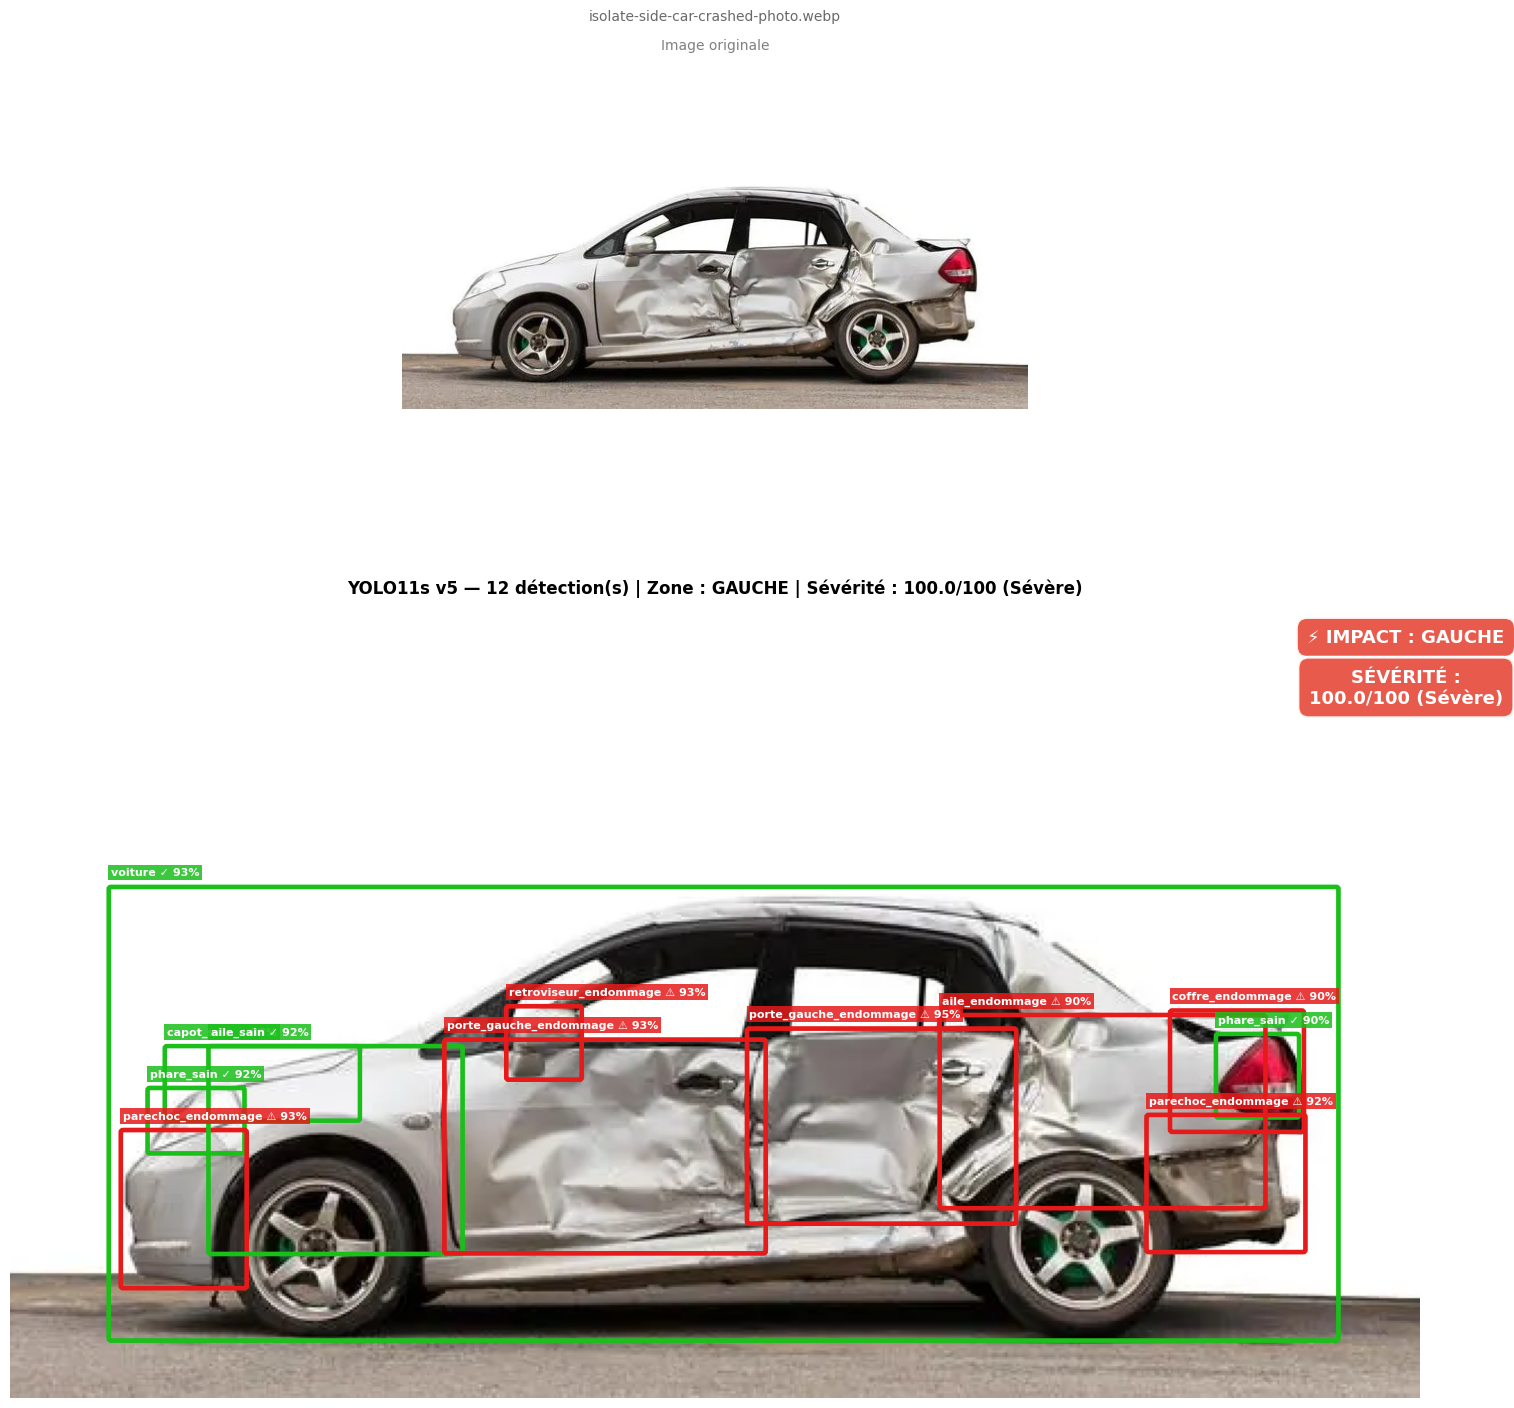

---
##Rapport de dégâts
**Fichier :** `isolate-side-car-crashed-photo.webp`

**Détections totales :** 12

**Modèle zone impact :** `YOLO vote pondéré`

**Modèle estimation dégâts :** `Modèle détection SEV (81%)`

**Filtre véhicule principal :** `1 seule voiture détectée`

| Indicateur | Valeur |
|:--|:--|
|⚡ Zone d'impact|**GAUCHE**|
|Sévérité|**100.0/100 (Sévère)**|
---
###⚠️ Pièces endommagées — 7 détectées

| Pièce | Confiance | &nbsp; |
|---|:---:|---|
| `porte_gauche_endommage` | **95%** | 🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜ |
| `porte_gauche_endommage` | **93%** | 🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜ |
| `retroviseur_endommage` | **93%** | 🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜ |
| `parechoc_endommage` | **93%** | 🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜ |
| `parechoc_endommage` | **92%** | 🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜ |
| `coffre_endommage` | **90%** | 🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜ |
| `aile_endommage` | **90%** | 🟥🟥🟥🟥🟥🟥🟥🟥⬜⬜ |

---
###✅ Pièces saines — 5 détectées

| Pièce | Confiance | &nbsp; |
|---|:---:|---|
| `voiture` | **93%** | 🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜ |
| `aile_sain` | **92%** | 🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜ |
| `phare_sain` | **92%** | 🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜ |
| `phare_sain` | **90%** | 🟩🟩🟩🟩🟩🟩🟩🟩⬜⬜ |
| `capot_sain` | **88%** | 🟩🟩🟩🟩🟩🟩🟩🟩⬜⬜ |

---
*Modèle détection : YOLO11s v5 — conf ≥ 35.3% — iou ≤ 50%*

*Modèle zone : YOLO11s-cls v3 — seuil activation ≥ 60%*

*Modèle sévérité : YOLO11s-sev — seuil priorité ≥ 70% — score composite affiché seulement en consensus ou fallback*

In [20]:
# ==============================================================
# CHARGEMENT DES TROIS MODÈLES
# Les trois modèles sont chargés une seule fois au début
# Chaque best.pt est autosuffisant : il contient l'architecture complète,
# les poids appris et les noms des classes, aucun fichier externe requis.
# ==============================================================

# Modèle 1 — YOLO11s v5 (détection de pièces)
# Rôle : détecter et localiser les 17 classes de pièces automobiles
# (saines + endommagées) avec des boîtes englobantes
chemin_modele = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_yolov11_v5/weights/best.pt"
model = YOLO(chemin_modele)
print(f"Modèle détection des pièces chargé : {chemin_modele}")

# Modèle 2 — YOLO11s-cls v3 (classificateur de zone)
# Rôle : prédire l'angle de vue du véhicule (avant/arrière/gauche/droite)
# directement depuis l'image brute, sans passer par les détections
# Activation : uniquement si le vote pondéré du modèle 1 est "indéterminé"
chemin_modele_cls = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_zone_classifier_v3/weights/best.pt"
model_cls = YOLO(chemin_modele_cls)
print(f"Classificateur de zone d'impact chargé : {chemin_modele_cls}")

# Modèle 3 — YOLO11s_sev v1 (sévérité globale)
# Rôle : prédire directement la sévérité (Sain / Léger / Modéré / Sévère)
# Ce modèle est PRIORITAIRE dans la décision finale
chemin_modele_sev = "/content/drive/MyDrive/INF1022_Yannick/Runs/INF1022_SEV_v1/weights/best.pt"
model_sev = YOLO(chemin_modele_sev)
print(f"Modèle détection de sévérité chargé : {chemin_modele_sev}")

# ==============================================================
# RÈGLES DU VOTE PONDÉRÉ POUR LA ZONE D'IMPACT
#
# Principe : chaque pièce endommagée détectée "vote" pour une ou
# plusieurs zones géographiques du véhicule. Le système de poids
# reflète la certitude de l'association entre la pièce et sa zone :
#
# Poids 3 = indicateurs PRIMAIRES (association univoque) :
#   capot : avant (visible uniquement depuis l'avant)
#   coffre : arrière (visible uniquement depuis l'arrière)
#   porte droite : droite (visible uniquement depuis le côté droit)
#   porte gauche : gauche (visible uniquement depuis le côté gauche)
#
# Poids 1 = indicateurs SECONDAIRES (association plus ambigue) :
#   parechoc : avant OU arrière (existe des deux côtés)
#   phare : avant OU arrière (avant ou arrière selon prise de vue)
#   aile : gauche OU droite (existe des deux côtés)
#   retroviseur : gauche OU droite (existe des deux côtés)
#
# Un indicateur primaire (poids 3) domine toujours trois secondaires (3×1)
# ce qui garantit qu'une porte ou un capot détecté tranche définitivement
# ==============================================================
REGLES_ZONE = {
    # --- Indicateurs primaires (poids 3) ---
    "capot_endommage" : [("avant", 3)],
    "coffre_endommage" : [("arriere", 3)],
    "porte_droite_endommage" : [("droite", 3)],
    "porte_gauche_endommage" : [("gauche", 3)],

    # --- Indicateurs secondaires (poids 1) ---
    # Chaque classe secondaire vote pour DEUX zones simultanément
    # car sa position sur le véhicule est ambiguë sans contexte supplémentaire
    "parechoc_endommage" : [("avant", 1), ("arriere", 1)],
    "phare_endommage" : [("avant", 1), ("arriere", 1)],
    "aile_endommage" : [("gauche", 1), ("droite", 1)],
    "retroviseur_endommage" : [("gauche", 1), ("droite", 1)],
}

# ==============================================================
# ZONES COMBINÉES
# Lorsque deux zones obtiennent un score équivalent ET que leur
# combinaison est géographiquement cohérente (un coin du véhicule),
# on produit une zone combinée plutôt que de déclarer l'ambiguité.
#
# Exemples valides :
#   avant + droite = coin avant-droit
#   arrière + gauche = coin arrière-gauche
#
# Exemples invalides (opposés irréductibles) :
#   avant + arrière = impossible géographiquement = fallback
#   gauche + droite = impossible géographiquement = fallback
#
# frozenset() est utilisé car l'ordre des deux zones n'a pas d'importance :
#   frozenset(["avant","droite"]) == frozenset(["droite","avant"])
# ==============================================================
ZONES_COMBINEES = {
    frozenset(["avant", "droite"]) : "avant-droit",
    frozenset(["avant", "gauche"]) : "avant-gauche",
    frozenset(["arriere", "droite"]) : "arriere-droit",
    frozenset(["arriere", "gauche"]) : "arriere-gauche",
}

# ==============================================================
# LABELS D'AFFICHAGE
# Dictionnaire de conversion des clés internes (minuscules, sans accents)
# vers les labels lisibles affichés à l'utilisateur
# ==============================================================
LABELS_ZONE = {
    "avant" : "AVANT",
    "arriere" : "ARRIÈRE",
    "gauche" : "GAUCHE",
    "droite" : "DROITE",
    "avant-droit" : "AVANT-DROIT",
    "avant-gauche" : "AVANT-GAUCHE",
    "arriere-droit" : "ARRIÈRE-DROIT",
    "arriere-gauche": "ARRIÈRE-GAUCHE",
    "indetermine" : "INDÉTERMINÉ",
    "saine" : "VOITURE SAINE",
}

# ==============================================================
# COULEURS DE LA BULLE QUI AFFICHE LA ZONE D'IMPACT SUR L'IMAGE
# Code couleur binaire intentionnel :
#   Rouge (#e74c3c) : toute zone avec dommage détecté (alerte)
#   Vert (#27ae60) : voiture saine (aucun dommage)
#
# Choix délibéré de n'utiliser que deux couleurs : avec les boites
# déjà colorées sur l'image annotée, ajouter des couleurs de zone
# différentes surchargerait inutilement la lisibilité visuelle
# ==============================================================
COULEURS_ZONE = {
    "avant" : "#e74c3c",
    "arriere" : "#e74c3c",
    "gauche" : "#e74c3c",
    "droite" : "#e74c3c",
    "avant-droit" : "#e74c3c",
    "avant-gauche" : "#e74c3c",
    "arriere-droit" : "#e74c3c",
    "arriere-gauche": "#e74c3c",
    "indetermine" : "#e74c3c",
    "saine" : "#27ae60",
}

def couleur_par_classe(nom_classe):
    """
    Retourne la couleur RGB normalisée [0-1] pour les boîtes englobantes.
    Code couleur binaire :
      Rouge (0.9, 0.1, 0.1) = pièce endommagée (signal d'alerte)
      Vert  (0.1, 0.75, 0.1) = pièce saine (signal de confirmation)
    Ce code couleur simplifie la lecture immédiate de l'image annotée.
    Avoir une couleur unique pour chaque classe surchargerait les informations
    (j'avais essayé)
    """

    if "endommage" in nom_classe:
        return (0.9, 0.1, 0.1) # Rouge
    else:
        return (0.1, 0.75, 0.1) # Vert

def _fallback_sain(classes_saines):
    """
    Mécanisme de repli basé sur les pièces SAINES visibles.

    Raisonnement sémantique : si le modèle détecte un capot_sain,
    la photo est nécessairement prise depuis l'avant du véhicule
    donc les dommages ambigus sont probablement à l'avant.
    Même logique pour coffre_sain = arrière.

    Ce fallback est activé quand le vote pondéré sur les pièces
    endommagées ne permet pas de trancher (égalité ou aucun vote).

    Cas possibles :
      capot_sain seul = avant (vue de face confirmée)
      coffre_sain seul = arrière (vue arrière confirmée)
      les deux ou aucun = indéterminé = le second modèle prendra le relais
    """

    a_capot_sain = "capot_sain"  in classes_saines
    a_coffre_sain = "coffre_sain" in classes_saines

    if a_capot_sain and not a_coffre_sain:
        return "avant" # Vue de face confirmée par la présence du capot
    elif a_coffre_sain and not a_capot_sain:
        return "arriere" # Vue arrière confirmée par la présence du coffre
    else:
        return "indetermine" # Ambiguïté réelle (photo de 3/4 ou aucun indice)

def classifier_zone_impact(classes_endommagees, classes_saines):
    """
    Classifie la zone d'impact principale via une cascade de décisions.

    La cascade respecte un ordre de priorité décroissante :
      Cas 1 : Aucune pièce endommagée = voiture saine (pas d'impact)
      Cas 2 : Vote pondéré sur les classes endommagées détectées
      Cas 3 : Un seul gagnant clair = zone simple retournée directement
      Cas 4 : Égalité entre deux zones géographiquement compatibles
              = zone combinée (ex: avant-droit)
      Cas 5 : Égalité irrésoluble (côtés opposées ou 3+ zones égales)
              = fallback sur les pièces saines visibles

    Paramètres :
      classes_endommagees : liste des noms de classes endommagées détectées
      classes_saines : liste des noms de classes saines détectées

    Retourne :
      (zone_impact, votes) : clé interne de la zone + dictionnaire des votes
    """

    # Cas 1 : aucune pièce endommagée = pas de dommage détecté
    if not classes_endommagees:
        return "saine", {}

    # Cas 2 : accumulation des votes pondérés pour les 4 zones de base
    votes = {"avant": 0, "arriere": 0, "gauche": 0, "droite": 0}
    for cls in classes_endommagees:
        if cls in REGLES_ZONE:
            for zone, poids in REGLES_ZONE[cls]:
                votes[zone] += poids  # Chaque pièce contribue selon son poids

    # Aucune pièce reconnue dans les règles = fallback immédiat sur pièces saines
    if max(votes.values()) == 0:
        return _fallback_sain(classes_saines), votes

    # Identification de la ou des zones ayant obtenu le score maximum
    vote_max = max(votes.values())
    zones_max = [z for z, v in votes.items() if v == vote_max]

    # Cas 3 : une seule zone gagne clairement = résultat sans ambiguité
    if len(zones_max) == 1:
        return zones_max[0], votes

    # Cas 4 : égalité entre exactement deux zones = vérifier compatibilité
    if len(zones_max) == 2:
        paire = frozenset(zones_max)
        if paire in ZONES_COMBINEES:
            # Combinaison géographiquement cohérente = zone combinée
            return ZONES_COMBINEES[paire], votes
        # Sinon combinaison opposée (avant+arrière ou gauche+droite) = Cas 5

    # Cas 5 : égalité irrésoluble (3+ zones ou zones opposées)
    # = déléguer au fallback basé sur les pièces saines
    return _fallback_sain(classes_saines), votes

def calculer_severite(pieces_endommagees, pieces_saines, zone_impact, res, img_rgb):
    """
    Calcule un score de sévérité des dommages d’un véhicule à partir des détections visuelles.

    La sévérité est estimée en combinant plusieurs composantes :
    - Poids des pièces endommagées (importance structurelle)
    - Surface totale endommagée (basée sur les bounding boxes)
    - Ratio de pièces endommagées vs pièces visibles
    - Combinaisons structurelles critiques (bonus/malus)
    - Multiplicateur selon la zone d’impact (avant, arrière, latéral, etc.)

    Paramètres :
    - pieces_endommagees : liste de tuples (nom_classe, count)
    - pieces_saines : liste de tuples (nom_classe, count)
    - zone_impact : str indiquant la zone principale d’impact
    - res : résultats de détection (bounding boxes)
    - img_rgb : image utilisée pour extraire dimensions

    Retourne :
    - score (float) : score final de sévérité (0 à 100)
    - cat (str) : catégorie associée ("Léger", "Modéré", "Sévère")
    """

    # ==============================================================
    # Composante 1 : Poids par type de pièce (35%)
    # But : pièces sont plus critiques que d'autres, on accorde donc un pointage
    # (capot > rétroviseur)
    # ==============================================================

    # Dictionnaire des poids par type de pièce endommagée
    POIDS = {
        "capot_endommage" : 3.0, # impact structurel avant (important)
        "coffre_endommage" : 3.0, # impact structurel arrière
        "porte_droite_endommage" : 3.0, # élément structural latéral droit
        "porte_gauche_endommage" : 3.0, # élément structural latéral gauche
        "parechoc_endommage" : 2.5, # absorbeur de choc (important mais moins critique)
        "aile_endommage" : 2.0, # structure secondaire
        "phare_endommage" : 1.5, # indicateur d’impact mais peu structurel
        "retroviseur_endommage" : 1.0, # mineur
    }

    # Calcul : somme pondérée (poids * nombre d’occurrences)
    score_pieces = sum(POIDS.get(n,1) * c for n,c in pieces_endommagees)

    # Normalisation sur 100 (avec plafond max de 100)
    score_pieces = min(score_pieces / 20.0 * 100, 100)

    # ==============================================================
    # Composante 2 : Surface endommagée relative (35%)
    # But : mesurer l’ampleur visuelle des dégâts
    # ==============================================================

    h, w = img_rgb.shape[:2]
    surface_image = h * w # surface totale de l'image

    surf_end = 0 # surface totale endommagée
    surface_voiture = None # surface du véhicule

    # --- Étape 1 : chercher bbox "voiture" avec la meilleur estimation
    for b in res.boxes:
        nom = model.names[int(b.cls[0])]

        if nom == "voiture":
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            surface_voiture = (x2 - x1) * (y2 - y1)
            break # on prend la première trouvée

    # --- Étape 2 : fallback si voiture non détectée, sinon passe direct étape 3
    # On approxime l'aire de la voiture avec la somme de toutes les boîtes pièces détectées
    if surface_voiture is None:
        surface_voiture = sum(
            (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
            for b in res.boxes
        )

    # --- Étape 3 : calcul surface des zones endommagées
    for b in res.boxes:
        nom = model.names[int(b.cls[0])]

        if "endommage" in nom:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            aire = (x2 - x1) * (y2 - y1)

            # Garde-fou : une seule pièce ne peut pas couvrir toute l’image
            # Max 35% de surface de la bbox voiture par pièce (limite l'impact des zoom extrêmes)
            aire = min(aire, 0.35 * surface_image)

            surf_end += aire

    # --- Étape 4 : ratio surface endommagée / surface voiture
    ratio_surface = surf_end / surface_voiture

    # Normalisation sur 100 avec plafond à 100
    score_surf = min(ratio_surface * 100, 100)

    # ==============================================================
    # Composante 3 : Ratio pièces endommagées (30%)
    # But : proportion de pièces touchées vs visibles
    # ==============================================================

    # On exclut "voiture" des pièces saines (sinon biaise le ratio)
    pieces_saines_effectives = [p for p in pieces_saines if p[0] != "voiture"]

    nb_saines = len(pieces_saines_effectives)
    nb_end = len(pieces_endommagees)

    # Nombre total de pièces visibles (hors voiture)
    nb_total = nb_end + nb_saines

    # Garde-fou : évite un ratio trop élevé si peu de pièces détectées (image zoomée)
    denom = max(nb_total, 6)

    # Calcul du ratio en %
    score_ratio = (nb_end / denom) * 100


    # ==============================================================
    # Composante 4 : Bonus ou malus de points
    # But : certaines combinaisons structurelles indiquent un dommage plus grave
    # ==============================================================

    classes = set(p[0] for p in pieces_endommagees)
    combos = []

    # --- impact AVANT ---
    if "capot_endommage" in classes and "parechoc_endommage" in classes and "aile_endommage" in classes:
        combos.append(5) # fort impact frontal avec 3 pièces endommagées. bonus 5 pts
    elif "capot_endommage" in classes and "parechoc_endommage" in classes and "phare_endommage" in classes:
        combos.append(5) # fort impact frontal avec 3 pièces endommagées. bonus 5 pts
    elif "capot_endommage" in classes and "parechoc_endommage" in classes:
        combos.append(-5) # impact limité avec seulement 2 pièces endommagées. malus 5 pts
    elif "capot_endommage" in classes and "phare_endommage" in classes:
        combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
    elif "capot_endommage" in classes and "aile_endommage" in classes:
        combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts

    # --- impact ARRIÈRE ---
    if "coffre_endommage" in classes and "parechoc_endommage" in classes and "aile_endommage" in classes:
        combos.append(5) # fort impact arrière avec 3 pièces endommagées. bonus 5 pts
    elif "coffre_endommage" in classes and "parechoc_endommage" in classes and "phare_endommage" in classes:
        combos.append(5) # fort impact arrière avec 3 pièces endommagées. bonus 5 pts
    elif "coffre_endommage" in classes and "parechoc_endommage" in classes:
        combos.append(-5) # impact limité avec 2 pièces endommagées. malus 5 pts
    elif "coffre_endommage" in classes and "phare_endommage" in classes:
        combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
    elif "coffre_endommage" in classes and "aile_endommage" in classes:
        combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts

    # --- impact LATÉRAL ---
    if ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
      and "aile_endommage" in classes \
      and ("coffre_endommage" in classes or "capot_endommage" in classes):
        combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
    elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
      and "aile_endommage" in classes \
      and ("parechoc_endommage" in classes):
        combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
    elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes):
        combos.append(5) # impact latéral avec les 2 portes endommagées. bonus 5 pts
    elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
      and "aile_endommage" in classes \
      and "retroviseur_endommage" in classes:
        combos.append(5) # fort impact latéral avec 3 pièces endommagées. bonus 5 pts
    elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
      and "aile_endommage" in classes:
        combos.append(-10) # impact limité avec seulement 2 pièces endommagées, dont 1 moins importante. malus 10 pts
    elif ("porte_gauche_endommage" in classes or "porte_droite_endommage" in classes) \
      and "retroviseur_endommage" in classes:
        combos.append(-15) # impact limité avec seulement 2 pièces endommagées, dont 1 très peu importante. malus 15 pts

    # --- Multi-impact (nombre de pièces touchées total) ---
    if len(pieces_endommagees) >= 6:
        combos.append(50) # Si 6 pièces et + sont endommagées, le véhicule est probablement très sévèrement accidenté. bonus 50 pts
    elif len(pieces_endommagees) >= 5:
        combos.append(20) # Si 5 pièces et + sont endommagées, le véhicule est probablement assez sévèrement accidenté. bonus 20 pts
    elif len(pieces_endommagees) >= 4:
        combos.append(10) # Si 4 pièces et + sont endommagées, le véhicule est probablement au moins modérément accidenté. bonus 10 pts

    # On garde uniquement la combinaison la plus sévère
    bonus = max((combos if combos else [0]))

    # ==============================================================
    # Composante 5 : Multiplicateur selon la zone d’impact
    # ==============================================================

    MULT = {
        "avant":1.35, "arriere":1.2, "gauche":1.1, "droite":1.1,
        "avant-droit":1.6, "avant-gauche":1.6,
        "arriere-droit":1.4, "arriere-gauche":1.4,
        "indetermine":1.15, "saine":0.0
    }

    # ==============================================================
    # Score final
    # ==============================================================

    # Combinaison pondérée des 3 premières composantes
    score_composite = (score_pieces*0.35 + score_surf*0.35 + score_ratio*0.30)

    # Ajout du bonus structurel (composante 4)
    score_composite += bonus

    # Application du multiplicateur de zone (composante 5)
    score_composite = min(score_composite * MULT.get(zone_impact, 1.0), 100)


    # ==============================================================
    # Catégorisation finale selon dommages léger, modéré ou sévère
    # ==============================================================

    if score_composite < 35:
        cat_composite = "Léger"
    elif score_composite < 70:
        cat_composite = "Modéré"
    else:
        cat_composite = "Sévère"

    return round(float(score_composite), 1), cat_composite


def filtrer_detections_vehicule_principal(res, model, img_rgb, seuil_conf_voiture=0.50):
    """
  Filtre les détections YOLO pour ne conserver que les pièces
  appartenant au véhicule principal de l'image.
    - Isoler automatiquement le véhicule principal dans une image
      pouvant contenir plusieurs voitures.
    - Éliminer les détections de pièces appartenant à des véhicules
      secondaires ou à l’arrière-plan.
    - Améliorer la cohérence du pipeline en aval :
        - vote de zone d’impact
        - score de sévérité (composite)
    - Garantir un comportement robuste dans tous les cas grâce à
      une stratégie en cascade avec fallback.

  Paramètres :
    res : Résultat brut du modèle YOLO contenant les détections
        (res.boxes avec coordonnées, classes et confiances)
    model : Modèle YOLO utilisé (permet d’accéder aux noms de classes)
    img_rgb : Image source utilisée pour obtenir les dimensions nécessaires aux calculs spatiaux
    seuil_conf_voiture : Seuil minimal de confiance pour considérer une détection de la classe "voiture" comme valide.

  Retours :
    boxes_filtrees : Liste des boîtes YOLO conservées après filtrage
    methode_filtre : Chaîne descriptive indiquant la stratégie utilisée
    """

    # Dimensions de l'image (utilisées pour normaliser certaines distances)
    h, w = img_rgb.shape[:2]

    # ==============================================================
    # ÉTAPE 0 — Séparation des détections
    # ==============================================================

    # Liste des boîtes "voiture" (serviront d’ancrage spatial)
    boites_voiture = []

    # Liste des boîtes "pièces" (candidates au filtrage)
    boites_pieces = []

    for b in res.boxes:
        # Nom de la classe
        nom = model.names[int(b.cls[0])]

        # Score de confiance associé à la détection
        conf = float(b.conf[0])

        # Si c’est une voiture suffisamment fiable = candidate principale
        if nom == "voiture" and conf >= seuil_conf_voiture:
            boites_voiture.append(b)

        # Sinon = considéré comme une pièce (même faible confiance)
        elif nom != "voiture":
            boites_pieces.append(b)

    # ==============================================================
    # ÉTAPE 1 — Identification du véhicule principal
    # ==============================================================

    # bbox finale du véhicule principal (None si non déterminé)
    bbox_principale = None

    # Nombre de voitures détectées
    nb_voitures = len(boites_voiture)

    # --------------------------------------------------------------
    # Cas 1 — Une seule voiture
    # --------------------------------------------------------------
    if nb_voitures == 1:
        # Cas trivial donc aucune ambiguïté
        bbox_principale = boites_voiture[0].xyxy[0].tolist()

        # Traçabilité
        methode_selection = "1 seule voiture détectée"

    # --------------------------------------------------------------
    # Cas 2 — Plusieurs voitures
    # --------------------------------------------------------------
    elif nb_voitures >= 2:

        # Si on a assez de pièces le clustering est fiable
        if len(boites_pieces) >= 2:

            # Calcul du centroïde global des pièces
            # Devient centre de gravité des dommages
            centres_pieces = []

            for b in boites_pieces:
                x1, y1, x2, y2 = b.xyxy[0].tolist()

                # Centre géométrique de chaque pièce
                centres_pieces.append(((x1 + x2) / 2, (y1 + y2) / 2))

            # Moyenne des centres = centroïde global
            centroide_x = sum(c[0] for c in centres_pieces) / len(centres_pieces)
            centroide_y = sum(c[1] for c in centres_pieces) / len(centres_pieces)

            # Recherche de la voiture la plus proche de ce centroïde
            dist_min = float("inf")
            voiture_gagnante = None

            for b in boites_voiture:
                x1, y1, x2, y2 = b.xyxy[0].tolist()

                # Centre de la voiture
                cx_v = (x1 + x2) / 2
                cy_v = (y1 + y2) / 2

                # Distance euclidienne au centroïde des pièces
                dist = ((cx_v - centroide_x)**2 + (cy_v - centroide_y)**2) ** 0.5

                # On garde la voiture la plus proche
                if dist < dist_min:
                    dist_min = dist
                    voiture_gagnante = b

            # bbox finale sélectionnée
            bbox_principale = voiture_gagnante.xyxy[0].tolist()

            methode_selection = f"{nb_voitures} voitures : la méthode de clustering sélectionne la principale"

        else:
            # Pas assez de pièces = clustering non fiable
            # Heuristique : prendre la plus grande voiture
            # (car par logique souvent la plus proche de la caméra)
            voiture_gagnante = max(
                boites_voiture,
                key=lambda b: (b.xyxy[0][2] - b.xyxy[0][0]) *
                              (b.xyxy[0][3] - b.xyxy[0][1])
            )

            bbox_principale = voiture_gagnante.xyxy[0].tolist()

            methode_selection = f"{nb_voitures} voitures : celle avec la plus grande surface retenue"

    # --------------------------------------------------------------
    # Cas 3 — Aucune voiture détectée
    # --------------------------------------------------------------
    else:
        # On ne peut pas utiliser l’ancrage spatial
        bbox_principale = None
        methode_selection = "aucune voiture détectée"

    # ==============================================================
    # ÉTAPE 2 — Filtrage spatial (Option 1)
    # ==============================================================

    if bbox_principale is not None:

        # Coordonnées de la bbox voiture
        vx1, vy1, vx2, vy2 = bbox_principale

        # Marge quasi nulle (volontairement bbox identique)
        # Bon compromis entre inclusion/exclusion
        marge_x = w * -0.00001
        marge_y = h * -0.00001

        boxes_filtrees = []

        for b in res.boxes:
            x1, y1, x2, y2 = b.xyxy[0].tolist()

            # Centre de la boîte
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            # Test d'appartenance : le centre doit être dans la bbox voiture
            if (vx1 - marge_x) <= cx <= (vx2 + marge_x) and \
               (vy1 - marge_y) <= cy <= (vy2 + marge_y):

                boxes_filtrees.append(b)

        # Retour avec traçabilité
        return boxes_filtrees, f"{methode_selection}"

    # ==============================================================
    # ÉTAPE 3 — Fallback clustering (Option 2 seule)
    # ==============================================================

    if len(boites_pieces) >= 3:

        # Calcul du centroïde des pièces
        centres = []

        for b in boites_pieces:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            centres.append(((x1 + x2) / 2, (y1 + y2) / 2))

        centroide_x = sum(c[0] for c in centres) / len(centres)
        centroide_y = sum(c[1] for c in centres) / len(centres)

        # Seuil basé sur la diagonale de l’image
        diagonale = (w**2 + h**2) ** 0.5
        seuil_dist = diagonale * 0.45

        boxes_filtrees = []

        for b in boites_pieces:
            x1, y1, x2, y2 = b.xyxy[0].tolist()

            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            # Distance au centroïde
            dist = ((cx - centroide_x)**2 + (cy - centroide_y)**2) ** 0.5

            # Garder seulement les pièces proches
            if dist <= seuil_dist:
                boxes_filtrees.append(b)

        return boxes_filtrees, f"{methode_selection}"

    # ==============================================================
    # ÉTAPE 4 — Aucun filtrage possible
    # ==============================================================

    # Fallback ultime : ne rien filtrer
    # Cela garantit que le pipeline ne casse jamais
    return list(res.boxes), "Aucun filtre (détections insuffisantes)"

# ==============================================================
# UPLOAD DE L'IMAGE
# files.upload() ouvre l'explorateur de fichiers Colab
# Le dictionnaire retourné a le nom du fichier comme clé
# ==============================================================
print("Sélectionnez une image à analyser...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"Image reçue : {img_path}")

# Lecture par OpenCV (format BGR natif) puis conversion en RGB
# Matplotlib et YOLO attendent du RGB ce qui est indispensable pour l'affichage correct
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ==============================================================
# INFÉRENCE DU MODÈLE 1 : YOLO11s v5
#
# Paramètres justifiés par les analyses des courbes d'évaluation :
#
# conf = 0.353 :
# seuil optimal identifié sur la courbe F1-Confidence
# (all classes 0.75 at 0.353) : maximise le F1 global
# Je veux favoriser le rappel tout en maintenant une bonne précision
#
# iou = 0.50 :
# seuil NMS (Non-Maximum Suppression) : contrôle la
# suppression des boîtes dupliquées sur une même pièce
# 0.50 = suppression modérée (équilibre détection/doublons)
#
# imgsz = 640 :
# DOIT correspondre exactement à la résolution d'entraînement
# Une valeur différente dégraderait les performances car
# mon modèle a appris à détecter à cette échelle précise
#
# max_det = 15 :
# limite supérieure raisonnable pour un véhicule
# (17 classes annotées au maximum par image)
# ==============================================================
resultats = model.predict(
    source = img_path,
    conf = 0.353,
    iou = 0.50,
    imgsz = 640,
    max_det = 20,
    verbose = False
)

# APRÈS — filtrage du véhicule principal
res_brut = resultats[0]

# Application du filtre combiné Option 1 + Option 2
boxes_filtrees, methode_filtre = filtrer_detections_vehicule_principal(
    res_brut, model, img_rgb
)

# Substitution transparente — le reste du pipeline est inchangé
# res.boxes est remplacé par boxes_filtrees dans toutes les boucles suivantes
res        = res_brut
res.boxes  = boxes_filtrees   # ← seul changement visible dans le pipeline

# ==============================================================
# PARTITIONNEMENT DES DÉTECTIONS
# Les boîtes sont séparées en deux listes selon l'état de la pièce.
# Cette séparation alimente :
#   1. Le système de vote pondéré (classifier_zone_impact)
#   2. Le rapport Markdown (tableaux endommagées / saines)
# ==============================================================
pieces_endommagees = [] # Liste de tuples (nom_classe, confiance)
pieces_saines = [] # Liste de tuples (nom_classe, confiance)

for box in res.boxes:
    nom = model.names[int(box.cls[0])] # Conversion index vers nom de classe
    conf = float(box.conf[0]) # Score de confiance [0.0 - 1.0]

    if "endommage" in nom:
        pieces_endommagees.append((nom, conf))
    elif "sain" in nom or "voiture" in nom:
        pieces_saines.append((nom, conf))

# Extraction des noms seuls pour le système de vote
# (le vote n'utilise pas les scores de confiance, seulement les noms)
noms_endommagees = [p[0] for p in pieces_endommagees]
noms_saines = [p[0] for p in pieces_saines]

# ==============================================================
# CLASSIFICATION DE LA ZONE D'IMPACT EN CASCADE AVEC LES 2 MODÈLES
#
# Architecture en cascade : les deux modèles sont complémentaires
# et fondamentalement orthogonaux dans leur approche :
#
#   Modèle 1 (vote pondéré) : raisonne sur les PIÈCES DÉTECTÉES
#     - précis et interprétable quand les pièces primaires sont visibles
#     - échoue si YOLO rate toutes les pièces primaires
#
#   Modèle 2 (classificateur visuel) : raisonne sur l'IMAGE ENTIÈRE
#     - robuste aux détections manquantes
#     - apprend l'orientation du véhicule, pas ses dommages
#     - intervient SEULEMENT si le modèle 1 est indéterminé
#
# Seuil d'activation confiance supérieure à 0.60 pour le modèle 2 :
#   Cela évite les substitutions avec une confiance trop faible
#   Si conf inférieure à 0.60 : maintient "indéterminé" plutôt que de deviner
# ==============================================================

# Étape 1 = Vote pondéré via les règles expertes (modèle 1)
zone_impact, votes_zone = classifier_zone_impact(noms_endommagees, noms_saines)
source_zone = "YOLO vote pondéré" # Traçabilité : indique quelle méthode a tranché

# Étape 2 = Classificateur visuel (modèle 2) si le vote est indéterminé
# N'est appelé que si strictement nécessaire
if zone_impact == "indetermine":
    res_cls = model_cls.predict(source=img_path, imgsz=640, verbose=False)[0]
    zone_cls = res_cls.names[res_cls.probs.top1] # Classe avec la plus haute probabilité
    conf_cls = float(res_cls.probs.top1conf) # Score de confiance associé [0-1]

    if conf_cls >= 0.60:
        # Si le classificateur est suffisamment confiant il va prendre sa décision
        zone_impact = zone_cls
        source_zone = f"Classificateur visuel ({conf_cls:.0%})"
    # Si les deux modèles ont échoué = honnêteté plutôt que fausse précision

# ==============================================================
# CALCUL DE LA SÉVÉRITÉ COMPOSITE
# ==============================================================

score_composite, cat_composite = calculer_severite(
    pieces_endommagees,
    pieces_saines,
    zone_impact,
    res,
    img_rgb
)

# ==============================================================
# PRÉDICTION SEV (MODÈLE DE DÉTECTION)
# ==============================================================

# Inférence du modèle SEV (YOLO détection)
resultats_sev = model_sev.predict(
    source=img_path,
    iou=0.50, # NMS standard pour éviter doublons
    imgsz=640, # Doit correspondre à la résolution d'entraînement
    max_det=1, # car une seule classe globale de sévérité est attendue par image
    verbose=False
)

# Une seule image = un seul résultat
res_sev = resultats_sev[0]

# On vérifie qu'il y a au moins une boîte détectée
if res_sev.boxes is not None and len(res_sev.boxes) > 0:

    # Index de la classe prédite (0=Léger, 1=Modéré, etc.)
    sev_id = int(res_sev.boxes.cls[0].item())

    # Score de confiance associé à la prédiction
    conf_sev = float(res_sev.boxes.conf[0].item())

    # Conversion index = nom de classe
    cat_sev = res_sev.names[sev_id]

else:
    # Cas où aucune détection n'est produite (rare mais possible) = fallback neutre
    sev_id = None
    conf_sev = 0.0
    cat_sev = "Indéterminé"


# ==============================================================
# Dictionnaire de remapping des catégories
# ==============================================================

# Harmonisation des labels entre les 2 modèles
remap_cat = {
    "Leger": "Léger",
    "Modere": "Modéré",
    "Severe": "Sévère"
}

# Application du remapping pour assurer la cohérence des comparaisons
# Important car évite les faux désaccords ("Modere" != "Modéré")
if cat_sev in remap_cat:
    cat_sev = remap_cat[cat_sev]

if cat_composite in remap_cat:
    cat_composite = remap_cat[cat_composite]


# ==============================================================
# FUSION DES DÉCISIONS ET SCORE FINAL
# ==============================================================

# Variables de traçabilité pour indiquer la source de la décision
score_source_sev = ""
score_source_composite = ""

# --- CAS 1 : SEV suffisamment confiant = décideur prioritaire ---
if conf_sev >= 0.70:

    # La catégorie finale vient du modèle SEV
    cat_finale = cat_sev

    # Vérification du consensus avec le scoring composite
    if cat_sev == cat_composite:

        # Cas A : Accord SEV + composite
        # On affiche le score numérique (interprétable)
        score_final = score_composite

        # Source principale = SEV (avec info de confiance)
        score_source_sev = f"Modèle détection SEV ({conf_sev:.0%})"

    else:
        # Cas B : Désaccord SEV avec composite
        # On garde SEV (prioritaire), mais sans afficher de score
        # car le score composite serait contradictoire
        score_final = None

        score_source_sev = f"Modèle détection SEV ({conf_sev:.0%})"

# --- CAS 2 : SEV pas assez confiant = fallback composite ---
else:

    # Le composite devient la source principale
    cat_finale = cat_composite

    # Le score est affiché (seule source disponible fiable ici)
    score_final = score_composite

    score_source_composite = f"Score par composite"

# ==============================================================
# DÉTERMINATION DE LA SOURCE FINALE (AFFICHAGE)
# ==============================================================

# Priorité à SEV si utilisé
if score_source_sev:
    score_source = score_source_sev

# Sinon fallback composite
elif score_source_composite:
    score_source = score_source_composite

# Cas théorique (ne devrait pas arriver)
else:
    score_source = "Indéterminé"

# ==============================================================
# AFFICHAGE VISUEL
#
# Layout personnalisé via fig.add_axes([left, bottom, width, height])
# en coordonnées normalisées [0-1] ce qui permet un contrôle précis et
# indépendant de la taille de la figure
#
# Choix du layout :
# Image originale : petite zone en haut (22% de hauteur) pour référence visuelle
# Image annotée : grande zone en bas (68% de hauteur) pour lisibilité maximale
# ==============================================================
fig = plt.figure(figsize=(15, 16))

# --- Encart image originale (haut, centré) ---
# [left=0.28, bottom=0.74, width=0.44, height=0.22]
ax_orig = fig.add_axes([0.28, 0.74, 0.44, 0.22])
ax_orig.imshow(img_rgb)
ax_orig.set_title("Image originale", fontsize=10, color="gray")
ax_orig.axis("off") # Masquer les axes car inutiles pour une image

# --- Grande zone annotée (bas) ---
ax_annot = fig.add_axes([0.03, 0.03, 0.94, 0.68])
ax_annot.imshow(img_rgb)

# Texte pour le titre
titre_severite = (
    f"{score_final}/100 ({cat_finale})" if score_final is not None else f"{cat_finale}"
)

ax_annot.set_title(
    f"YOLO11s v5 — {len(res.boxes)} détection(s) | "
    f"Zone : {LABELS_ZONE[zone_impact]} | Sévérité : {titre_severite}",
    fontsize=12, fontweight="bold", pad=8
)
ax_annot.axis("off")

if len(res.boxes) == 0:
    # Aucune détection = message d'information centré sur l'image
    ax_annot.text(
        0.5, 0.5, "Aucun objet détecté",
        transform=ax_annot.transAxes, ha="center", va="center",
        fontsize=13, color="red",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )
else:
    # Tri des boîtes par aire croissante avant le dessin
    # Les grandes boîtes sont dessinées en premier (fond) et les petites
    # par-dessus (premier plan) donc les étiquettes des petites pièces
    # restent visibles et ne sont pas masquées par les grandes boîtes
    boites_triees = sorted(
        res.boxes,
        key=lambda b: (b.xyxy[0][2]-b.xyxy[0][0]) * (b.xyxy[0][3]-b.xyxy[0][1])
    )

    for box in boites_triees:
        x1, y1, x2, y2 = box.xyxy[0].tolist() # Coordonnées en pixels absolus
        class_id = int(box.cls[0])
        confiance = float(box.conf[0])
        nom = model.names[class_id]
        couleur = couleur_par_classe(nom)

        # Épaisseur de la boîte proportionnelle à la confiance
        # Boîte très confiante (conf d'environs 1.0) = épaisseur de 3.5px (très visible)
        # Boîte peu confiante (conf d'environs 0.35) = épaisseur de 2.2px (plus fine)
        epaisseur = 1.5 + confiance * 2.0

        # Symboles visuels pour renforcer le code couleur :
        # ⚠ = endommagé (alerte) et ✓ = sain (confirmé)
        suffixe = " ⚠" if "endommage" in nom else " ✓"

        # Boîte englobante arrondie (avec FancyBboxPatch)
        # facecolor = "none" fait qu'elle est transparente, n'occulte pas l'image sous-jacente
        rect = patches.FancyBboxPatch(
            (x1, y1), x2-x1, y2-y1,
            linewidth=epaisseur,
            edgecolor=couleur,
            facecolor="none",
            boxstyle="round,pad=1"
        )
        ax_annot.add_patch(rect)

        # Étiquette avec fond coloré opaque
        # Placée légèrement au-dessus de la boîte (y1 - 6 pixels)
        # pour ne pas chevaucher le bord supérieur de la boîte
        ax_annot.text(
            x1, y1 - 6,
            f"{nom}{suffixe} {confiance:.0%}",
            color="white", fontsize=8, fontweight="bold",
            bbox=dict(facecolor=couleur, alpha=0.85, pad=2, edgecolor="none")
        )

# ==============================================================
# BULLES D'INFORMATION (ZONE + SÉVÉRITÉ)
# Deux bulles distinctes, alignées verticalement (coin supérieur droit)
# ==============================================================

# --- Style texte uniquement ---
style_text = dict(
    ha="center",
    va="top",
    fontsize=13,
    fontweight="bold",
    color="white"
)

# --- Style bbox commun ---
style_bbox = dict(
    alpha=0.92,
    pad=7,
    edgecolor="white",
    linewidth=2,
    boxstyle="round,pad=0.6"
)

# --- Bulle 1 : Zone d'impact ---
ax_annot.text(
    0.99, 0.97,
    f"⚡ IMPACT : {LABELS_ZONE[zone_impact]}",
    transform=ax_annot.transAxes,
    **style_text,
    bbox=dict(**style_bbox, facecolor=COULEURS_ZONE[zone_impact])
)

# --- Bulle 2 : Sévérité ---
y_offset = 0.050 # Alignement avec la bulle 1 zone impact

# Couleur dynamique selon la catégorie finale
if cat_finale == "Sain":
    couleur_sev = "#27ae60" # vert
elif cat_finale == "Léger":
    couleur_sev = "#27ae60" # vert
elif cat_finale == "Modéré":
    couleur_sev = "#f39c12" # jaune-orange
else:
    couleur_sev = "#e74c3c" # rouge

# Texte de la bulle : score affiché seulement s'il existe
texte_sev = f"SÉVÉRITÉ : {cat_finale}"
if score_final is not None:
    texte_sev = f"SÉVÉRITÉ :\n{score_final}/100 ({cat_finale})"

ax_annot.text(
    0.99, 0.97 - y_offset,
    texte_sev,
    transform=ax_annot.transAxes,
    **style_text,
    bbox=dict(**style_bbox, facecolor=couleur_sev)
)

# Titre global = nom du fichier tronqué à 60 caractères
nom_court = os.path.basename(img_path)[:60] + ("..." if len(os.path.basename(img_path)) > 60 else "")
plt.suptitle(nom_court, fontsize=10, color="dimgray", y=0.99)

# Sauvegarde automatique + affichage
plt.savefig("/content/detection_resultat.png", dpi=150, bbox_inches="tight")
plt.show()

# ==============================================================
# RAPPORT MARKDOWN
# ==============================================================

nom_fichier = os.path.basename(img_path)
zone_label = LABELS_ZONE[zone_impact]
icone_zone = "✅" if zone_impact == "saine" else "⚡"
nb_end = len(pieces_endommagees)
nb_sain = len(pieces_saines)

md = []

# --- Entête du rapport ---
md.append("---")
md.append("##Rapport de dégâts")
md.append(f"**Fichier :** `{nom_fichier}`")
md.append("")
md.append(f"**Détections totales :** {len(res.boxes)}")
md.append("")
md.append(f"**Modèle zone impact :** `{source_zone}`")
md.append("")
md.append(f"**Modèle estimation dégâts :** `{score_source}`")
md.append("")
md.append(f"**Filtre véhicule principal :** `{methode_filtre}`")
md.append("")

# Tableau principal
md.append("| Indicateur | Valeur |")
md.append("|:--|:--|")
md.append(f"|{icone_zone} Zone d'impact|**{zone_label}**|")

if score_final is not None:
    md.append(f"|Sévérité|**{score_final}/100 ({cat_finale})**|")
else:
    md.append(f"|Sévérité|**{cat_finale}**|")

# --- Section pièces endommagées ---
md.append("---")
s_end = "s" if nb_end > 1 else ""
md.append(f"###⚠️ Pièces endommagées — {nb_end} détectée{s_end}")
md.append("")

if pieces_endommagees:
    md.append("| Pièce | Confiance | &nbsp; |")
    md.append("|---|:---:|---|")
    for nom, conf in sorted(pieces_endommagees, key=lambda x: -x[1]):
        nb_barres = int(conf * 10)
        barre = "🟥" * nb_barres + "⬜" * (10 - nb_barres)
        md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
else:
    md.append(">Aucune pièce endommagée détectée")

md.append("")

# --- Section pièces saines ---
md.append("---")
s_sain = "s" if nb_sain > 1 else ""
md.append(f"###✅ Pièces saines — {nb_sain} détectée{s_sain}")
md.append("")

if pieces_saines:
    md.append("| Pièce | Confiance | &nbsp; |")
    md.append("|---|:---:|---|")
    for nom, conf in sorted(pieces_saines, key=lambda x: -x[1]):
        nb_barres = int(conf * 10)
        barre = "🟩" * nb_barres + "⬜" * (10 - nb_barres)
        md.append(f"| `{nom}` | **{conf:.0%}** | {barre} |")
else:
    md.append(">Aucune pièce saine détectée")

# --- Pied de rapport ---
md.append("")
md.append("---")
md.append("*Modèle détection : YOLO11s v5 — conf ≥ 35.3% — iou ≤ 50%*")
md.append("")
md.append("*Modèle zone : YOLO11s-cls v3 — seuil activation ≥ 60%*")
md.append("")
md.append("*Modèle sévérité : YOLO11s-sev — seuil priorité ≥ 70% — score composite affiché seulement en consensus ou fallback*")

display(Markdown("\n".join(md)))